<a href="https://colab.research.google.com/github/Ham41za/Pearls-AQI-Predictor/blob/main/AQI_Predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
!pip install -q requests pandas numpy matplotlib

In [127]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timezone
import time
import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [128]:
# ==========================================
# PROJECT CONFIGURATION
# ==========================================

CITY = "Lahore"

LATITUDE = 31.5204
LONGITUDE = 74.3587

# Enter your OpenWeather API key here
API_KEY = "2d9bd5e25e23f93ea7629f1fcc924434"

# Folder for collected data
DATA_DIR = "data"

os.makedirs(DATA_DIR, exist_ok=True)

print(f"City: {CITY}")
print(f"Latitude: {LATITUDE}")
print(f"Longitude: {LONGITUDE}")

City: Lahore
Latitude: 31.5204
Longitude: 74.3587


In [129]:
# ==========================================
# TEST OPENWEATHER API
# ==========================================

url = (
    "https://api.openweathermap.org/data/2.5/air_pollution"
    f"?lat={LATITUDE}"
    f"&lon={LONGITUDE}"
    f"&appid={API_KEY}"
)

response = requests.get(url, timeout=30)

print("HTTP Status Code:", response.status_code)

if response.status_code == 200:
    print("API connection successful!")
else:
    print("API request failed.")
    print("Response:")
    print(response.text)

HTTP Status Code: 200
API connection successful!


In [130]:
# ==========================================
# FETCH AIR POLLUTION DATA
# ==========================================

def fetch_air_pollution(lat, lon, api_key):

    url = (
        "https://api.openweathermap.org/data/2.5/air_pollution"
        f"?lat={lat}"
        f"&lon={lon}"
        f"&appid={api_key}"
    )

    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        raise Exception(
            f"Air pollution API error: "
            f"{response.status_code} - {response.text}"
        )

    return response.json()


pollution_data = fetch_air_pollution(
    LATITUDE,
    LONGITUDE,
    API_KEY
)

print("Air pollution data received!")
print(pollution_data)

Air pollution data received!
{'coord': {'lon': 74.3587, 'lat': 31.5204}, 'list': [{'main': {'aqi': 4}, 'components': {'co': 326.07, 'no': 0, 'no2': 6.31, 'o3': 77.21, 'so2': 3.73, 'pm2_5': 56, 'pm10': 110.82, 'nh3': 2.8}, 'dt': 1788704393}]}


In [131]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timezone
import time
import os

print("Libraries imported successfully!")

# ==========================================
# EXTRACT POLLUTION DATA
# ==========================================

def parse_air_pollution(data, city):

    record = data["list"][0]

    # Round timestamp to the nearest minute for consistent merging
    timestamp_raw = datetime.fromtimestamp(
        record["dt"],
        tz=timezone.utc
    )
    timestamp = timestamp_raw.replace(second=0, microsecond=0)

    components = record["components"]

    row = {
        "city": city,
        "timestamp": timestamp,

        # OpenWeather AQI scale: 1-5
        "api_aqi": record["main"]["aqi"],

        "CO": components.get("co"),
        "NO": components.get("no"),
        "NO2": components.get("no2"),
        "O3": components.get("o3"),
        "SO2": components.get("so2"),
        "PM2_5": components.get("pm2_5"),
        "PM10": components.get("pm10"),
        "NH3": components.get("nh3")
    }

    return pd.DataFrame([row])


pollution_df = parse_air_pollution(
    pollution_data,
    CITY
)

pollution_df

Libraries imported successfully!


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8


In [132]:
# ==========================================
# FETCH WEATHER DATA
# ==========================================

def fetch_weather(lat, lon, api_key):

    url = (
        "https://api.openweathermap.org/data/2.5/weather"
        f"?lat={lat}"
        f"&lon={lon}"
        f"&appid={api_key}"
        "&units=metric"
    )

    response = requests.get(url, timeout=30)

    if response.status_code != 200:
        raise Exception(
            f"Weather API error: "
            f"{response.status_code} - {response.text}"
        )

    return response.json()


weather_data = fetch_weather(
    LATITUDE,
    LONGITUDE,
    API_KEY
)

print("Weather data received!")

Weather data received!


In [133]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datetime import datetime, timezone
import time
import os

print("Libraries imported successfully!")

# ==========================================
# EXTRACT WEATHER DATA
# ==========================================

def parse_weather(data, city):

    # Round timestamp to the nearest minute for consistent merging
    timestamp_raw = datetime.fromtimestamp(
        data["dt"],
        tz=timezone.utc
    )
    timestamp = timestamp_raw.replace(second=0, microsecond=0)

    main = data["main"]
    wind = data.get("wind", {})

    row = {
        "city": city,
        "timestamp": timestamp,

        "temperature": main.get("temp"),
        "feels_like": main.get("feels_like"),
        "humidity": main.get("humidity"),
        "pressure": main.get("pressure"),

        "wind_speed": wind.get("speed"),
        "wind_direction": wind.get("deg"),

        "clouds": data.get("clouds", {}).get("all"),
        "visibility": data.get("visibility")
    }

    return pd.DataFrame([row])


weather_df = parse_weather(
    weather_data,
    CITY
)

weather_df

Libraries imported successfully!


,city,timestamp,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility
0,Lahore,2026-09-06 14:19:00+00:00,29.99,32.42,58,1006,2.06,280,5,10000


In [134]:
# ==========================================
# COMBINE POLLUTION + WEATHER
# ==========================================

df = pd.merge(
    pollution_df,
    weather_df,
    on=["city", "timestamp"],
    how="inner"
)

print("Combined dataset:")
display(df)

Combined dataset:


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8,29.99,32.42,58,1006,2.06,280,5,10000


In [135]:
# ==========================================
# COMBINE POLLUTION + WEATHER
# ==========================================

df = pd.merge(
    pollution_df,
    weather_df,
    on=["city", "timestamp"],
    how="inner"
)

print("Combined dataset:")
display(df)

Combined dataset:


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8,29.99,32.42,58,1006,2.06,280,5,10000


In [136]:
# ==========================================
# ADD COLLECTION TIMESTAMP
# ==========================================

df["collected_at"] = datetime.now(timezone.utc)

display(df)

,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility,collected_at
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8,29.99,32.42,58,1006,2.06,280,5,10000,2026-09-06 14:21:12.773554+00:00


In [137]:
# ==========================================
# CHECK DATA TYPES
# ==========================================

print(df.dtypes)

city                           object
timestamp         datetime64[ns, UTC]
api_aqi                         int64
CO                            float64
NO                              int64
NO2                           float64
O3                            float64
SO2                           float64
PM2_5                           int64
PM10                          float64
NH3                           float64
temperature                   float64
feels_like                    float64
humidity                        int64
pressure                        int64
wind_speed                    float64
wind_direction                  int64
clouds                          int64
visibility                      int64
collected_at      datetime64[us, UTC]
dtype: object


In [138]:
# ==========================================
# CHECK MISSING VALUES
# ==========================================

missing = df.isnull().sum()

print("Missing values:")
print(missing)

Missing values:
city              0
timestamp         0
api_aqi           0
CO                0
NO                0
NO2               0
O3                0
SO2               0
PM2_5             0
PM10              0
NH3               0
temperature       0
feels_like        0
humidity          0
pressure          0
wind_speed        0
wind_direction    0
clouds            0
visibility        0
collected_at      0
dtype: int64


In [139]:
# ==========================================
# DATA VALIDATION
# ==========================================

def validate_data(df):

    required_columns = [
        "city",
        "timestamp",
        "api_aqi",
        "CO",
        "NO",
        "NO2",
        "O3",
        "SO2",
        "PM2_5",
        "PM10",
        "NH3",
        "temperature",
        "humidity",
        "pressure",
        "wind_speed"
    ]

    missing_columns = [
        col for col in required_columns
        if col not in df.columns
    ]

    if missing_columns:
        print("Missing columns:")
        print(missing_columns)
        return False

    if df.empty:
        print("Dataset is empty!")
        return False

    print("Data validation successful!")
    return True


validation_result = validate_data(df)

Data validation successful!


In [140]:
# ==========================================
# SAVE RAW DATA
# ==========================================

raw_file = os.path.join(
    DATA_DIR,
    "aqi_raw_data.csv"
)

df.to_csv(
    raw_file,
    index=False
)

print(f"Raw data saved to: {raw_file}")

Raw data saved to: data/aqi_raw_data.csv


In [141]:
# ==========================================
# TEST SAVED DATA
# ==========================================

loaded_df = pd.read_csv(
    raw_file
)

print("Dataset loaded successfully!")

display(loaded_df)

Dataset loaded successfully!


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility,collected_at
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8,29.99,32.42,58,1006,2.06,280,5,10000,2026-09-06 14:21:12.773554+00:00


In [142]:
# ==========================================
# DATASET INFORMATION
# ==========================================

print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumns:")
for column in df.columns:
    print("-", column)

Rows: 1
Columns: 20

Columns:
- city
- timestamp
- api_aqi
- CO
- NO
- NO2
- O3
- SO2
- PM2_5
- PM10
- NH3
- temperature
- feels_like
- humidity
- pressure
- wind_speed
- wind_direction
- clouds
- visibility
- collected_at


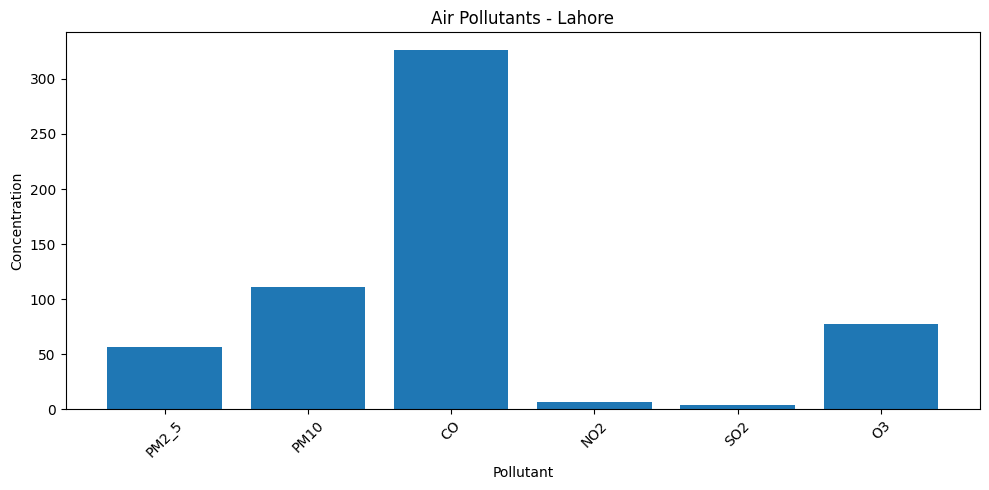

In [143]:
# ==========================================
# POLLUTANT VISUALIZATION
# ==========================================

pollutants = [
    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3"
]

values = df[pollutants].iloc[0]

plt.figure(figsize=(10, 5))

plt.bar(
    pollutants,
    values
)

plt.title(f"Air Pollutants - {CITY}")
plt.xlabel("Pollutant")
plt.ylabel("Concentration")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [144]:
# ==========================================
# COMPLETE DATA COLLECTION FUNCTION
# ==========================================

def collect_current_data(
    city,
    lat,
    lon,
    api_key
):

    # -----------------------------
    # 1. Fetch pollution
    # -----------------------------

    pollution_json = fetch_air_pollution(
        lat,
        lon,
        api_key
    )

    pollution = parse_air_pollution(
        pollution_json,
        city
    )


    # -----------------------------
    # 2. Fetch weather
    # -----------------------------

    weather_json = fetch_weather(
        lat,
        lon,
        api_key
    )

    weather = parse_weather(
        weather_json,
        city
    )


    # -----------------------------
    # 3. Merge
    # -----------------------------

    result = pd.merge(
        pollution,
        weather,
        on=["city", "timestamp"],
        how="inner"
    )


    # -----------------------------
    # 4. Collection time
    # -----------------------------

    result["collected_at"] = datetime.now(
        timezone.utc
    )

    return result

In [145]:
# ==========================================
# TEST COMPLETE COLLECTION PIPELINE
# ==========================================

new_data = collect_current_data(
    CITY,
    LATITUDE,
    LONGITUDE,
    API_KEY
)

display(new_data)

,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility,collected_at


In [146]:
# ==========================================
# APPEND NEW DATA TO DATASET - FIXED
# ==========================================

def append_data(new_data, filename):

    # Make a copy so we don't modify the original DataFrame
    new_data = new_data.copy()

    # --------------------------------------
    # Convert new timestamp to datetime
    # --------------------------------------
    new_data["timestamp"] = pd.to_datetime(
        new_data["timestamp"],
        utc=True,
        errors="coerce"
    )

    # --------------------------------------
    # If file already exists
    # --------------------------------------
    if os.path.exists(filename):

        existing_data = pd.read_csv(filename)

        # Convert existing timestamp to datetime
        existing_data["timestamp"] = pd.to_datetime(
            existing_data["timestamp"],
            utc=True,
            errors="coerce"
        )

        # Combine old + new data
        combined = pd.concat(
            [
                existing_data,
                new_data
            ],
            ignore_index=True
        )

    else:

        combined = new_data.copy()

    # --------------------------------------
    # Remove invalid timestamps
    # --------------------------------------
    combined = combined.dropna(
        subset=["timestamp"]
    )

    # --------------------------------------
    # Remove duplicate records
    # --------------------------------------
    combined = combined.drop_duplicates(
        subset=["city", "timestamp"],
        keep="last"
    )

    # --------------------------------------
    # Sort by timestamp
    # --------------------------------------
    combined = combined.sort_values(
        by="timestamp"
    ).reset_index(drop=True)

    # --------------------------------------
    # Save to CSV
    # --------------------------------------
    combined.to_csv(
        filename,
        index=False
    )

    return combined

In [147]:
# ==========================================
# SAVE CURRENT COLLECTION
# ==========================================

df = append_data(
    new_data,
    raw_file
)

print("Data successfully appended!")
print("Total rows:", len(df))

display(df.tail())

Data successfully appended!
Total rows: 1


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,temperature,feels_like,humidity,pressure,wind_speed,wind_direction,clouds,visibility,collected_at
0,Lahore,2026-09-06 14:19:00+00:00,4,326.07,0,6.31,77.21,3.73,56,110.82,2.8,29.99,32.42,58,1006,2.06,280,5,10000,2026-09-06 14:21:12.773554+00:00


In [148]:
# ==========================================
# FINAL CHECK
# ==========================================

print("=" * 50)
print("AQI DATA COLLECTION PIPELINE")
print("=" * 50)

print(f"City: {CITY}")
print(f"Rows: {len(df)}")
print(f"Columns: {len(df.columns)}")

print("\nDataset columns:")

for column in df.columns:
    print(f"  ✓ {column}")

print("\nMissing values:")

print(df.isnull().sum())

print("\nData collection pipeline completed successfully!")

AQI DATA COLLECTION PIPELINE
City: Lahore
Rows: 1
Columns: 20

Dataset columns:
  ✓ city
  ✓ timestamp
  ✓ api_aqi
  ✓ CO
  ✓ NO
  ✓ NO2
  ✓ O3
  ✓ SO2
  ✓ PM2_5
  ✓ PM10
  ✓ NH3
  ✓ temperature
  ✓ feels_like
  ✓ humidity
  ✓ pressure
  ✓ wind_speed
  ✓ wind_direction
  ✓ clouds
  ✓ visibility
  ✓ collected_at

Missing values:
city              0
timestamp         0
api_aqi           0
CO                0
NO                0
NO2               0
O3                0
SO2               0
PM2_5             0
PM10              0
NH3               0
temperature       0
feels_like        0
humidity          0
pressure          0
wind_speed        0
wind_direction    0
clouds            0
visibility        0
collected_at      0
dtype: int64

Data collection pipeline completed successfully!


In [149]:
# ==========================================
# MODULE 2
# HISTORICAL DATA + FEATURE ENGINEERING
# ==========================================

import requests
import pandas as pd
import numpy as np
import os
import time

from datetime import datetime, timezone, timedelta

print("Module 2 initialized successfully!")

Module 2 initialized successfully!


In [150]:
# ==========================================
# PROJECT CONFIGURATION
# ==========================================

CITY = "Lahore"

LATITUDE = 31.5204
LONGITUDE = 74.3587

# Put your actual OpenWeather API key here
API_KEY = "2d9bd5e25e23f93ea7629f1fcc924434"

# Data folder
DATA_DIR = "data"

import os
os.makedirs(DATA_DIR, exist_ok=True)

print("Configuration loaded successfully!")
print("City:", CITY)
print("Latitude:", LATITUDE)
print("Longitude:", LONGITUDE)

Configuration loaded successfully!
City: Lahore
Latitude: 31.5204
Longitude: 74.3587


In [151]:
# ==========================================
# CHECK CONFIGURATION
# ==========================================

print("City:", CITY)
print("Latitude:", LATITUDE)
print("Longitude:", LONGITUDE)

if API_KEY == "YOUR_API_KEY":
    print("\nWARNING: Please enter your OpenWeather API key.")
else:
    print("\nAPI key is configured.")

City: Lahore
Latitude: 31.5204
Longitude: 74.3587

API key is configured.


In [152]:
# ==========================================
# HISTORICAL AIR POLLUTION API
# ==========================================

def fetch_historical_pollution(
    lat,
    lon,
    start_timestamp,
    end_timestamp,
    api_key
):

    url = (
        "https://api.openweathermap.org/data/2.5/"
        "air_pollution/history"
    )

    params = {
        "lat": lat,
        "lon": lon,
        "start": start_timestamp,
        "end": end_timestamp,
        "appid": api_key
    }

    response = requests.get(
        url,
        params=params,
        timeout=30
    )

    if response.status_code != 200:
        raise Exception(
            f"API Error {response.status_code}: "
            f"{response.text}"
        )

    return response.json()

In [153]:
# ==========================================
# TEST HISTORICAL API
# ==========================================

end_time = datetime.now(timezone.utc)

start_time = end_time - timedelta(hours=24)

start_timestamp = int(start_time.timestamp())
end_timestamp = int(end_time.timestamp())

print("Start:", start_time)
print("End:", end_time)

print("\nTesting historical API...")

try:

    historical_test = fetch_historical_pollution(
        LATITUDE,
        LONGITUDE,
        start_timestamp,
        end_timestamp,
        API_KEY
    )

    print("\nHistorical API request successful!")
    print("Records returned:",
          len(historical_test.get("list", [])))

except Exception as e:

    print("\nHistorical API request failed:")
    print(e)

Start: 2026-09-05 14:21:13.623755+00:00
End: 2026-09-06 14:21:13.623755+00:00

Testing historical API...

Historical API request successful!
Records returned: 24


In [154]:
# ==========================================
# PARSE HISTORICAL POLLUTION
# ==========================================

def parse_historical_pollution(
    data,
    city
):

    records = []

    for item in data.get("list", []):

        timestamp = datetime.fromtimestamp(
            item["dt"],
            tz=timezone.utc
        )

        components = item.get(
            "components",
            {}
        )

        record = {
            "city": city,
            "timestamp": timestamp,

            "api_aqi": item["main"]["aqi"],

            "CO": components.get("co"),
            "NO": components.get("no"),
            "NO2": components.get("no2"),
            "O3": components.get("o3"),
            "SO2": components.get("so2"),
            "PM2_5": components.get("pm2_5"),
            "PM10": components.get("pm10"),
            "NH3": components.get("nh3")
        }

        records.append(record)

    return pd.DataFrame(records)

In [155]:
# ==========================================
# CREATE 24-HOUR DATASET
# ==========================================

historical_df = parse_historical_pollution(
    historical_test,
    CITY
)

print("Rows:", len(historical_df))
print("Columns:", len(historical_df.columns))

display(historical_df.head())

Rows: 24
Columns: 11


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,Lahore,2026-09-05 15:00:00+00:00,4,358.86,0.0,5.57,74.98,2.59,55.57,87.35,2.99
1,Lahore,2026-09-05 16:00:00+00:00,4,373.93,0.0,5.81,70.13,2.51,55.39,84.96,3.24
2,Lahore,2026-09-05 17:00:00+00:00,4,386.45,0.0,5.92,66.40,2.45,54.90,82.98,3.40
3,Lahore,2026-09-05 18:00:00+00:00,4,391.88,0.0,5.92,62.97,2.33,54.04,81.05,3.43
4,Lahore,2026-09-05 19:00:00+00:00,4,379.94,0.0,5.47,60.49,2.19,52.32,78.79,3.10


In [156]:
# ==========================================
# SORT DATA
# ==========================================

historical_df = historical_df.sort_values(
    "timestamp"
).reset_index(drop=True)

display(historical_df.head())

,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,Lahore,2026-09-05 15:00:00+00:00,4,358.86,0.0,5.57,74.98,2.59,55.57,87.35,2.99
1,Lahore,2026-09-05 16:00:00+00:00,4,373.93,0.0,5.81,70.13,2.51,55.39,84.96,3.24
2,Lahore,2026-09-05 17:00:00+00:00,4,386.45,0.0,5.92,66.40,2.45,54.90,82.98,3.40
3,Lahore,2026-09-05 18:00:00+00:00,4,391.88,0.0,5.92,62.97,2.33,54.04,81.05,3.43
4,Lahore,2026-09-05 19:00:00+00:00,4,379.94,0.0,5.47,60.49,2.19,52.32,78.79,3.10


In [157]:
# ==========================================
# CHECK MISSING VALUES
# ==========================================

print("Missing values:")
display(
    historical_df.isnull().sum()
)

Missing values:


,0
city,0
timestamp,0
api_aqi,0
CO,0
NO,0
NO2,0
O3,0
SO2,0
PM2_5,0
PM10,0


In [158]:
# ==========================================
# REMOVE DUPLICATES
# ==========================================

before = len(historical_df)

historical_df = historical_df.drop_duplicates(
    subset=["city", "timestamp"],
    keep="last"
)

after = len(historical_df)

print("Rows before:", before)
print("Rows after:", after)
print("Duplicates removed:", before - after)

Rows before: 24
Rows after: 24
Duplicates removed: 0


In [159]:
# ==========================================
# TIME FEATURES
# ==========================================

historical_df["timestamp"] = pd.to_datetime(
    historical_df["timestamp"],
    utc=True
)

historical_df["hour"] = (
    historical_df["timestamp"].dt.hour
)

historical_df["day"] = (
    historical_df["timestamp"].dt.day
)

historical_df["month"] = (
    historical_df["timestamp"].dt.month
)

historical_df["weekday"] = (
    historical_df["timestamp"].dt.weekday
)

historical_df["is_weekend"] = (
    historical_df["weekday"] >= 5
).astype(int)

display(historical_df.head())

,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3,hour,day,month,weekday,is_weekend
0,Lahore,2026-09-05 15:00:00+00:00,4,358.86,0.0,5.57,74.98,2.59,55.57,87.35,2.99,15,5,9,5,1
1,Lahore,2026-09-05 16:00:00+00:00,4,373.93,0.0,5.81,70.13,2.51,55.39,84.96,3.24,16,5,9,5,1
2,Lahore,2026-09-05 17:00:00+00:00,4,386.45,0.0,5.92,66.40,2.45,54.90,82.98,3.40,17,5,9,5,1
3,Lahore,2026-09-05 18:00:00+00:00,4,391.88,0.0,5.92,62.97,2.33,54.04,81.05,3.43,18,5,9,5,1
4,Lahore,2026-09-05 19:00:00+00:00,4,379.94,0.0,5.47,60.49,2.19,52.32,78.79,3.10,19,5,9,5,1


In [160]:
# ==========================================
# LAG FEATURES
# ==========================================

historical_df["AQI_lag_1"] = (
    historical_df["api_aqi"].shift(1)
)

historical_df["AQI_lag_3"] = (
    historical_df["api_aqi"].shift(3)
)

historical_df["AQI_lag_6"] = (
    historical_df["api_aqi"].shift(6)
)

historical_df["AQI_lag_12"] = (
    historical_df["api_aqi"].shift(12)
)

historical_df["AQI_lag_24"] = (
    historical_df["api_aqi"].shift(24)
)

display(
    historical_df[
        [
            "timestamp",
            "api_aqi",
            "AQI_lag_1",
            "AQI_lag_3",
            "AQI_lag_6",
            "AQI_lag_12",
            "AQI_lag_24"
        ]
    ].tail()
)

,timestamp,api_aqi,AQI_lag_1,AQI_lag_3,AQI_lag_6,AQI_lag_12,AQI_lag_24
19,2026-09-06 10:00:00+00:00,4,4.0,4.0,4.0,3.0,NaN
20,2026-09-06 11:00:00+00:00,4,4.0,4.0,4.0,3.0,NaN
21,2026-09-06 12:00:00+00:00,4,4.0,4.0,4.0,3.0,NaN
22,2026-09-06 13:00:00+00:00,4,4.0,4.0,4.0,3.0,NaN
23,2026-09-06 14:00:00+00:00,4,4.0,4.0,4.0,3.0,NaN


In [161]:
# ==========================================
# AQI CHANGE RATE
# ==========================================

historical_df["AQI_change"] = (
    historical_df["api_aqi"]
    .diff()
)

historical_df["AQI_change_rate"] = (
    historical_df["api_aqi"]
    .pct_change()
)

display(
    historical_df[
        [
            "timestamp",
            "api_aqi",
            "AQI_change",
            "AQI_change_rate"
        ]
    ].tail(10)
)

,timestamp,api_aqi,AQI_change,AQI_change_rate
14,2026-09-06 05:00:00+00:00,4,0.0,0.0
15,2026-09-06 06:00:00+00:00,4,0.0,0.0
16,2026-09-06 07:00:00+00:00,4,0.0,0.0
17,2026-09-06 08:00:00+00:00,4,0.0,0.0
18,2026-09-06 09:00:00+00:00,4,0.0,0.0
19,2026-09-06 10:00:00+00:00,4,0.0,0.0
20,2026-09-06 11:00:00+00:00,4,0.0,0.0
21,2026-09-06 12:00:00+00:00,4,0.0,0.0
22,2026-09-06 13:00:00+00:00,4,0.0,0.0
23,2026-09-06 14:00:00+00:00,4,0.0,0.0


In [162]:
# ==========================================
# ROLLING FEATURES
# ==========================================

historical_df["AQI_rolling_mean_3"] = (
    historical_df["api_aqi"]
    .rolling(window=3)
    .mean()
)

historical_df["AQI_rolling_mean_6"] = (
    historical_df["api_aqi"]
    .rolling(window=6)
    .mean()
)

historical_df["AQI_rolling_std_6"] = (
    historical_df["api_aqi"]
    .rolling(window=6)
    .std()
)

display(
    historical_df[
        [
            "timestamp",
            "api_aqi",
            "AQI_rolling_mean_3",
            "AQI_rolling_mean_6",
            "AQI_rolling_std_6"
        ]
    ].tail()
)

,timestamp,api_aqi,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6
19,2026-09-06 10:00:00+00:00,4,4.0,4.0,0.0
20,2026-09-06 11:00:00+00:00,4,4.0,4.0,0.0
21,2026-09-06 12:00:00+00:00,4,4.0,4.0,0.0
22,2026-09-06 13:00:00+00:00,4,4.0,4.0,0.0
23,2026-09-06 14:00:00+00:00,4,4.0,4.0,0.0


In [163]:
# ==========================================
# FUTURE TARGET
# ==========================================

historical_df["target_AQI_1h"] = (
    historical_df["api_aqi"].shift(-1)
)

display(
    historical_df[
        [
            "timestamp",
            "api_aqi",
            "target_AQI_1h"
        ]
    ].head(10)
)

,timestamp,api_aqi,target_AQI_1h
0,2026-09-05 15:00:00+00:00,4,4.0
1,2026-09-05 16:00:00+00:00,4,4.0
2,2026-09-05 17:00:00+00:00,4,4.0
3,2026-09-05 18:00:00+00:00,4,4.0
4,2026-09-05 19:00:00+00:00,4,4.0
5,2026-09-05 20:00:00+00:00,4,4.0
6,2026-09-05 21:00:00+00:00,4,3.0
7,2026-09-05 22:00:00+00:00,3,3.0
8,2026-09-05 23:00:00+00:00,3,3.0
9,2026-09-06 00:00:00+00:00,3,3.0


In [164]:
# ==========================================
# 3-DAY FORECAST TARGETS
# ==========================================

historical_df["target_AQI_24h"] = (
    historical_df["api_aqi"].shift(-24)
)

historical_df["target_AQI_48h"] = (
    historical_df["api_aqi"].shift(-48)
)

historical_df["target_AQI_72h"] = (
    historical_df["api_aqi"].shift(-72)
)

display(
    historical_df[
        [
            "timestamp",
            "api_aqi",
            "target_AQI_24h",
            "target_AQI_48h",
            "target_AQI_72h"
        ]
    ].head()
)

,timestamp,api_aqi,target_AQI_24h,target_AQI_48h,target_AQI_72h
0,2026-09-05 15:00:00+00:00,4,NaN,NaN,NaN
1,2026-09-05 16:00:00+00:00,4,NaN,NaN,NaN
2,2026-09-05 17:00:00+00:00,4,NaN,NaN,NaN
3,2026-09-05 18:00:00+00:00,4,NaN,NaN,NaN
4,2026-09-05 19:00:00+00:00,4,NaN,NaN,NaN


In [165]:
# ==========================================
# HISTORICAL DATA COLLECTION
# ==========================================

def collect_historical_pollution(
    city,
    lat,
    lon,
    api_key,
    days=30
):

    end_time = datetime.now(
        timezone.utc
    )

    start_time = (
        end_time -
        timedelta(days=days)
    )

    start_timestamp = int(
        start_time.timestamp()
    )

    end_timestamp = int(
        end_time.timestamp()
    )

    print("Collecting historical data...")
    print("Start:", start_time)
    print("End:", end_time)

    data = fetch_historical_pollution(
        lat,
        lon,
        start_timestamp,
        end_timestamp,
        api_key
    )

    result = parse_historical_pollution(
        data,
        city
    )

    return result

In [166]:
# ==========================================
# TEST 30-DAY BACKFILL
# ==========================================

try:

    historical_30d = collect_historical_pollution(
        CITY,
        LATITUDE,
        LONGITUDE,
        API_KEY,
        days=30
    )

    print("\nCollection completed!")
    print("Rows:", len(historical_30d))

    display(
        historical_30d.head()
    )

except Exception as e:

    print("\nBackfill failed:")
    print(e)

Start: 2026-08-07 14:21:14.401779+00:00
End: 2026-09-06 14:21:14.401779+00:00

Collection completed!
Rows: 672


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,Lahore,2026-08-07 15:00:00+00:00,5,950.93,0.0,17.84,71.65,3.34,114.97,128.19,8.55
1,Lahore,2026-08-07 16:00:00+00:00,5,1047.60,0.0,19.91,57.74,3.10,123.89,137.78,8.98
2,Lahore,2026-08-07 17:00:00+00:00,5,1108.49,0.0,20.25,49.16,2.75,130.93,144.44,7.98
3,Lahore,2026-08-07 18:00:00+00:00,5,1113.76,0.0,18.84,47.26,2.49,132.21,144.22,6.59
4,Lahore,2026-08-07 19:00:00+00:00,5,999.77,0.0,13.54,61.36,2.56,122.09,130.94,4.72


In [167]:
# ==========================================
# SAVE HISTORICAL DATA
# ==========================================

historical_file = os.path.join(
    DATA_DIR,
    "historical_pollution.csv"
)

historical_30d.to_csv(
    historical_file,
    index=False
)

print(
    f"Historical data saved to: "
    f"{historical_file}"
)

Historical data saved to: data/historical_pollution.csv


In [168]:
# ==========================================
# FEATURE ENGINEERING FUNCTION
# ==========================================

def create_features(df):

    df = df.copy()

    # -----------------------------
    # Timestamp
    # -----------------------------

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        utc=True
    )

    df = df.sort_values(
        "timestamp"
    ).reset_index(drop=True)


    # -----------------------------
    # Time features
    # -----------------------------

    df["hour"] = (
        df["timestamp"].dt.hour
    )

    df["day"] = (
        df["timestamp"].dt.day
    )

    df["month"] = (
        df["timestamp"].dt.month
    )

    df["weekday"] = (
        df["timestamp"].dt.weekday
    )

    df["is_weekend"] = (
        df["weekday"] >= 5
    ).astype(int)


    # -----------------------------
    # Lag features
    # -----------------------------

    df["AQI_lag_1"] = (
        df["api_aqi"].shift(1)
    )

    df["AQI_lag_3"] = (
        df["api_aqi"].shift(3)
    )

    df["AQI_lag_6"] = (
        df["api_aqi"].shift(6)
    )

    df["AQI_lag_12"] = (
        df["api_aqi"].shift(12)
    )

    df["AQI_lag_24"] = (
        df["api_aqi"].shift(24)
    )


    # -----------------------------
    # AQI change
    # -----------------------------

    df["AQI_change"] = (
        df["api_aqi"].diff()
    )

    df["AQI_change_rate"] = (
        df["api_aqi"].pct_change()
    )


    # -----------------------------
    # Rolling features
    # -----------------------------

    df["AQI_rolling_mean_3"] = (
        df["api_aqi"]
        .rolling(3)
        .mean()
    )

    df["AQI_rolling_mean_6"] = (
        df["api_aqi"]
        .rolling(6)
        .mean()
    )

    df["AQI_rolling_std_6"] = (
        df["api_aqi"]
        .rolling(6)
        .std()
    )


    # -----------------------------
    # Future targets
    # -----------------------------

    df["target_AQI_24h"] = (
        df["api_aqi"].shift(-24)
    )

    df["target_AQI_48h"] = (
        df["api_aqi"].shift(-48)
    )

    df["target_AQI_72h"] = (
        df["api_aqi"].shift(-72)
    )

    return df

In [169]:
# ==========================================
# CREATE FINAL FEATURES
# ==========================================

features_df = create_features(
    historical_30d
)

print(
    "Feature engineering completed!"
)

print(
    "Rows:",
    len(features_df)
)

print(
    "Columns:",
    len(features_df.columns)
)

display(
    features_df.head()
)

Feature engineering completed!
Rows: 672
Columns: 29


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,...,AQI_lag_12,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,target_AQI_24h,target_AQI_48h,target_AQI_72h
0,Lahore,2026-08-07 15:00:00+00:00,5,950.93,0.0,17.84,71.65,3.34,114.97,128.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,3.0,4.0
1,Lahore,2026-08-07 16:00:00+00:00,5,1047.60,0.0,19.91,57.74,3.10,123.89,137.78,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,2.0,3.0,4.0
2,Lahore,2026-08-07 17:00:00+00:00,5,1108.49,0.0,20.25,49.16,2.75,130.93,144.44,...,NaN,NaN,0.0,0.0,5.0,NaN,NaN,2.0,3.0,4.0
3,Lahore,2026-08-07 18:00:00+00:00,5,1113.76,0.0,18.84,47.26,2.49,132.21,144.22,...,NaN,NaN,0.0,0.0,5.0,NaN,NaN,3.0,4.0,4.0
4,Lahore,2026-08-07 19:00:00+00:00,5,999.77,0.0,13.54,61.36,2.56,122.09,130.94,...,NaN,NaN,0.0,0.0,5.0,NaN,NaN,3.0,4.0,4.0


In [170]:
# ==========================================
# CLEAN TRAINING DATA
# ==========================================

training_df = features_df.dropna(
    subset=[
        "target_AQI_24h",
        "target_AQI_48h",
        "target_AQI_72h"
    ]
).copy()

print(
    "Training rows:",
    len(training_df)
)

display(
    training_df.tail()
)

Training rows: 600


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,...,AQI_lag_12,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,target_AQI_24h,target_AQI_48h,target_AQI_72h
595,Lahore,2026-09-03 10:00:00+00:00,4,157.48,0.22,1.40,84.41,1.55,33.99,105.33,...,3.0,4.0,0.0,0.0,4.0,4.0,0.0,4.0,4.0,4.0
596,Lahore,2026-09-03 11:00:00+00:00,4,193.76,0.39,2.64,77.86,1.58,35.65,105.82,...,3.0,4.0,0.0,0.0,4.0,4.0,0.0,4.0,4.0,4.0
597,Lahore,2026-09-03 12:00:00+00:00,4,231.22,0.44,4.45,72.72,1.68,36.76,106.36,...,3.0,4.0,0.0,0.0,4.0,4.0,0.0,3.0,4.0,4.0
598,Lahore,2026-09-03 13:00:00+00:00,4,289.02,0.19,8.11,61.22,1.91,37.81,106.67,...,3.0,4.0,0.0,0.0,4.0,4.0,0.0,3.0,4.0,4.0
599,Lahore,2026-09-03 14:00:00+00:00,4,346.69,0.00,10.59,47.97,2.11,39.03,106.69,...,3.0,4.0,0.0,0.0,4.0,4.0,0.0,3.0,4.0,4.0


In [171]:
# ==========================================
# SAVE TRAINING DATASET
# ==========================================

training_file = os.path.join(
    DATA_DIR,
    "aqi_training_dataset.csv"
)

training_df.to_csv(
    training_file,
    index=False
)

print(
    f"Training dataset saved to: "
    f"{training_file}"
)

Training dataset saved to: data/aqi_training_dataset.csv


In [172]:
# ==========================================
# FINAL DATASET OVERVIEW
# ==========================================

print("=" * 60)
print("AQI TRAINING DATASET")
print("=" * 60)

print("City:", CITY)

print(
    "Rows:",
    len(training_df)
)

print(
    "Columns:",
    len(training_df.columns)
)

print("\nColumns:")

for column in training_df.columns:
    print("✓", column)

print("\nMissing values:")

display(
    training_df.isnull().sum()
)

AQI TRAINING DATASET
City: Lahore
Rows: 600
Columns: 29

Columns:
✓ city
✓ timestamp
✓ api_aqi
✓ CO
✓ NO
✓ NO2
✓ O3
✓ SO2
✓ PM2_5
✓ PM10
✓ NH3
✓ hour
✓ day
✓ month
✓ weekday
✓ is_weekend
✓ AQI_lag_1
✓ AQI_lag_3
✓ AQI_lag_6
✓ AQI_lag_12
✓ AQI_lag_24
✓ AQI_change
✓ AQI_change_rate
✓ AQI_rolling_mean_3
✓ AQI_rolling_mean_6
✓ AQI_rolling_std_6
✓ target_AQI_24h
✓ target_AQI_48h
✓ target_AQI_72h

Missing values:


,0
city,0
timestamp,0
api_aqi,0
CO,0
NO,0
NO2,0
O3,0
SO2,0
PM2_5,0
PM10,0


In [173]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [174]:
# ==========================================
# IMPORT MATPLOTLIB
# ==========================================

import matplotlib.pyplot as plt

print("Matplotlib loaded successfully!")

Matplotlib loaded successfully!


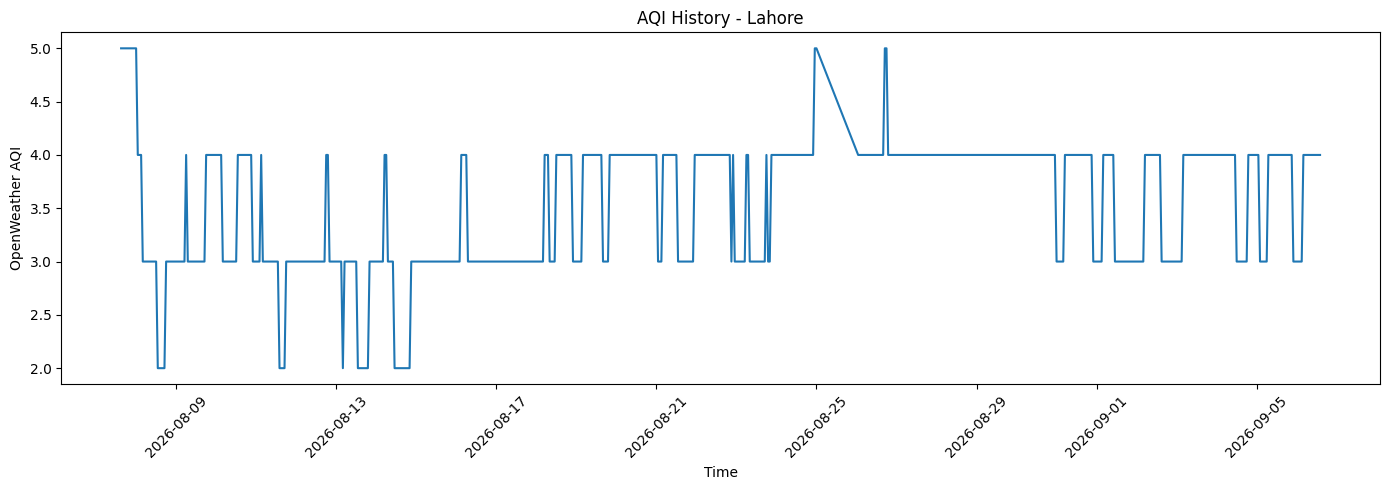

In [175]:
# ==========================================
# AQI HISTORY
# ==========================================

plt.figure(figsize=(14, 5))

plt.plot(
    historical_30d["timestamp"],
    historical_30d["api_aqi"]
)

plt.title(
    f"AQI History - {CITY}"
)

plt.xlabel("Time")
plt.ylabel("OpenWeather AQI")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

**Module 3 — EDA + Data Quality**

In [176]:
# ==========================================
# MODULE 3
# EDA + DATA QUALITY
# ==========================================

!pip install -q pandas numpy matplotlib seaborn

In [177]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import os

print("Libraries imported successfully!")

Libraries imported successfully!


In [178]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print("✓", filename)

Saving aqi_raw_data.csv to aqi_raw_data.csv
Saving aqi_training_dataset.csv to aqi_training_dataset.csv
Saving historical_pollution.csv to historical_pollution.csv

Uploaded files:
✓ aqi_raw_data.csv
✓ aqi_training_dataset.csv
✓ historical_pollution.csv


In [179]:
# ==========================================
# LOAD DATASETS
# ==========================================

historical_file = "historical_pollution.csv"
training_file = "aqi_training_dataset.csv"
raw_file = "aqi_raw_data.csv"

historical_df = pd.read_csv(historical_file)
training_df = pd.read_csv(training_file)
raw_df = pd.read_csv(raw_file)

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [180]:
# ==========================================
# DATASET SIZES
# ==========================================

print("=" * 60)
print("DATASET SIZES")
print("=" * 60)

print(
    f"Historical pollution: "
    f"{historical_df.shape[0]} rows × "
    f"{historical_df.shape[1]} columns"
)

print(
    f"Training dataset: "
    f"{training_df.shape[0]} rows × "
    f"{training_df.shape[1]} columns"
)

print(
    f"Raw dataset: "
    f"{raw_df.shape[0]} rows × "
    f"{raw_df.shape[1]} columns"
)

DATASET SIZES
Historical pollution: 672 rows × 11 columns
Training dataset: 600 rows × 29 columns
Raw dataset: 0 rows × 20 columns


In [181]:
# ==========================================
# HISTORICAL DATASET
# ==========================================

print("Historical Pollution Dataset")
print("=" * 60)

display(historical_df.head())

Historical Pollution Dataset


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,NH3
0,Lahore,2026-08-06 11:00:00+00:00,4,244.13,0.69,3.79,77.09,1.29,36.15,105.64,3.29
1,Lahore,2026-08-06 12:00:00+00:00,4,297.86,0.90,6.27,74.18,1.59,39.53,107.88,4.89
2,Lahore,2026-08-06 13:00:00+00:00,4,354.21,0.62,9.64,67.87,1.84,41.84,109.10,6.32
3,Lahore,2026-08-06 14:00:00+00:00,4,391.03,0.06,11.01,57.29,1.83,42.79,106.52,5.88
4,Lahore,2026-08-06 15:00:00+00:00,3,386.67,0.00,10.04,56.65,2.02,41.96,99.02,4.97


In [182]:
# ==========================================
# TRAINING DATASET
# ==========================================

print("Training Dataset")
print("=" * 60)

display(training_df.head())

Training Dataset


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,...,AQI_lag_12,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,target_AQI_24h,target_AQI_48h,target_AQI_72h
0,Lahore,2026-08-06 11:00:00+00:00,4,244.13,0.69,3.79,77.09,1.29,36.15,105.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.0,3.0,3.0
1,Lahore,2026-08-06 12:00:00+00:00,4,297.86,0.90,6.27,74.18,1.59,39.53,107.88,...,NaN,NaN,0.0,0.00,NaN,NaN,NaN,5.0,3.0,3.0
2,Lahore,2026-08-06 13:00:00+00:00,4,354.21,0.62,9.64,67.87,1.84,41.84,109.10,...,NaN,NaN,0.0,0.00,4.000000,NaN,NaN,5.0,2.0,3.0
3,Lahore,2026-08-06 14:00:00+00:00,4,391.03,0.06,11.01,57.29,1.83,42.79,106.52,...,NaN,NaN,0.0,0.00,4.000000,NaN,NaN,5.0,2.0,3.0
4,Lahore,2026-08-06 15:00:00+00:00,3,386.67,0.00,10.04,56.65,2.02,41.96,99.02,...,NaN,NaN,-1.0,-0.25,3.666667,NaN,NaN,5.0,2.0,3.0


In [183]:
# ==========================================
# TRAINING COLUMNS
# ==========================================

print("Training dataset columns:")
print()

for i, column in enumerate(training_df.columns, start=1):
    print(f"{i:02d}. {column}")

Training dataset columns:

01. city
02. timestamp
03. api_aqi
04. CO
05. NO
06. NO2
07. O3
08. SO2
09. PM2_5
10. PM10
11. NH3
12. hour
13. day
14. month
15. weekday
16. is_weekend
17. AQI_lag_1
18. AQI_lag_3
19. AQI_lag_6
20. AQI_lag_12
21. AQI_lag_24
22. AQI_change
23. AQI_change_rate
24. AQI_rolling_mean_3
25. AQI_rolling_mean_6
26. AQI_rolling_std_6
27. target_AQI_24h
28. target_AQI_48h
29. target_AQI_72h


In [184]:
# ==========================================
# DATA TYPES
# ==========================================

print("Data Types")
print("=" * 60)

display(
    training_df.dtypes.to_frame(
        name="Data Type"
    )
)

Data Types


,Data Type
city,object
timestamp,object
api_aqi,int64
CO,float64
NO,float64
NO2,float64
O3,float64
SO2,float64
PM2_5,float64
PM10,float64


In [185]:
# ==========================================
# CONVERT TIMESTAMP
# ==========================================

historical_df["timestamp"] = pd.to_datetime(
    historical_df["timestamp"],
    utc=True,
    errors="coerce"
)

training_df["timestamp"] = pd.to_datetime(
    training_df["timestamp"],
    utc=True,
    errors="coerce"
)

print("Timestamp conversion completed.")

print(
    "Historical timestamp type:",
    historical_df["timestamp"].dtype
)

print(
    "Training timestamp type:",
    training_df["timestamp"].dtype
)

Timestamp conversion completed.
Historical timestamp type: datetime64[ns, UTC]
Training timestamp type: datetime64[ns, UTC]


In [186]:
# ==========================================
# DATE RANGE
# ==========================================

start_date = historical_df["timestamp"].min()
end_date = historical_df["timestamp"].max()

print("=" * 60)
print("HISTORICAL DATA RANGE")
print("=" * 60)

print("Start:", start_date)
print("End:  ", end_date)

duration = end_date - start_date

print("Duration:", duration)
print(
    "Duration in days:",
    duration.total_seconds() / 86400
)

HISTORICAL DATA RANGE
Start: 2026-08-06 11:00:00+00:00
End:   2026-09-05 10:00:00+00:00
Duration: 29 days 23:00:00
Duration in days: 29.958333333333332


In [187]:
# ==========================================
# CITY CHECK
# ==========================================

print("Cities in historical dataset:")

print(
    historical_df["city"].unique()
)

print("\nNumber of cities:")

print(
    historical_df["city"].nunique()
)

Cities in historical dataset:
['Lahore']

Number of cities:
1


In [188]:
# ==========================================
# MISSING VALUES
# ==========================================

missing = training_df.isnull().sum()

missing_percentage = (
    training_df.isnull().mean() * 100
)

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table = missing_table.sort_values(
    "Missing Values",
    ascending=False
)

display(missing_table)

,Missing Values,Percentage
AQI_lag_24,24,4.000000
AQI_lag_12,12,2.000000
AQI_lag_6,6,1.000000
AQI_rolling_mean_6,5,0.833333
AQI_rolling_std_6,5,0.833333
AQI_lag_3,3,0.500000
AQI_rolling_mean_3,2,0.333333
AQI_lag_1,1,0.166667
AQI_change,1,0.166667
AQI_change_rate,1,0.166667


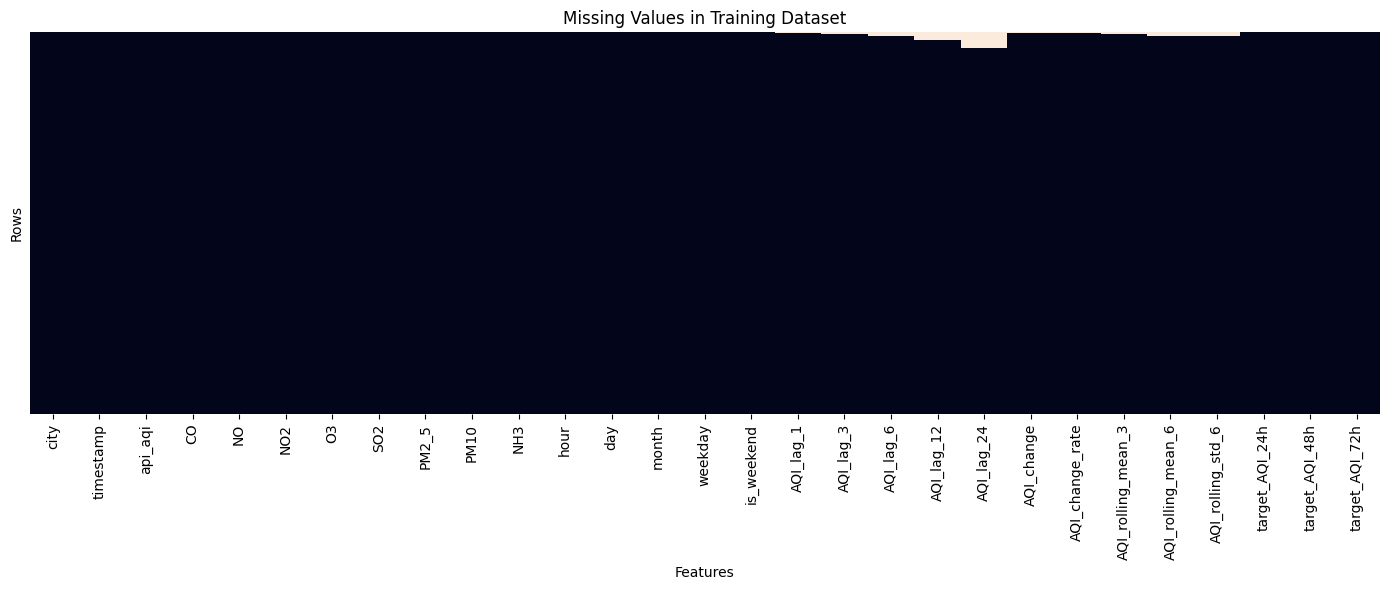

In [189]:
# ==========================================
# MISSING VALUE VISUALIZATION
# ==========================================

plt.figure(figsize=(14, 6))

sns.heatmap(
    training_df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Values in Training Dataset")
plt.xlabel("Features")
plt.ylabel("Rows")

plt.tight_layout()
plt.show()

In [190]:
# ==========================================
# DUPLICATES
# ==========================================

duplicates = training_df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [191]:
duplicate_timestamps = training_df.duplicated(
    subset=["city", "timestamp"]
).sum()

print(
    "Duplicate city/timestamp records:",
    duplicate_timestamps
)

Duplicate city/timestamp records: 0


In [192]:
# ==========================================
# TIMESTAMP CONTINUITY
# ==========================================

check_df = historical_df.sort_values(
    "timestamp"
).copy()

time_difference = (
    check_df["timestamp"].diff()
)

print("Most common time intervals:")

display(
    time_difference.value_counts().head(10)
)

Most common time intervals:


,count
timestamp,
0 days 01:00:00,669
1 days 01:00:00,2


In [193]:
# ==========================================
# FIND MISSING HOURS
# ==========================================

check_df = historical_df.sort_values(
    "timestamp"
).copy()

check_df["time_diff"] = (
    check_df["timestamp"].diff()
)

missing_intervals = check_df[
    check_df["time_diff"] > pd.Timedelta(hours=1)
]

print(
    "Number of gaps:",
    len(missing_intervals)
)

if len(missing_intervals) > 0:
    display(
        missing_intervals[
            [
                "timestamp",
                "time_diff"
            ]
        ].head(20)
    )
else:
    print("No gaps greater than 1 hour found.")

Number of gaps: 2


,timestamp,time_diff
446,2026-08-26 01:00:00+00:00,1 days 01:00:00
494,2026-08-29 01:00:00+00:00,1 days 01:00:00


In [194]:
# ==========================================
# STATISTICAL SUMMARY
# ==========================================

numeric_columns = training_df.select_dtypes(
    include=np.number
).columns

statistics = training_df[
    numeric_columns
].describe().T

display(statistics)

,count,mean,std,min,25%,50%,75%,max
api_aqi,600.0,3.501667,0.638234,2.000000,3.0000,4.000000,4.000000,5.000000
CO,600.0,415.394367,230.592351,118.030000,230.8425,375.615000,556.337500,1159.920000
NO,600.0,0.265900,0.582444,0.000000,0.0000,0.085000,0.230000,6.810000
NO2,600.0,8.326467,5.737811,0.690000,3.1350,8.215000,12.015000,27.790000
O3,600.0,59.153533,29.276354,0.420000,34.7450,53.880000,83.602500,143.380000
SO2,600.0,2.486367,1.058679,0.740000,1.7275,2.310000,2.985000,7.060000
PM2_5,600.0,40.792317,16.521512,18.470000,30.2350,36.150000,48.892500,132.210000
PM10,600.0,90.669367,38.817374,22.240000,62.4175,96.035000,111.405000,186.240000
NH3,600.0,3.595267,2.696242,0.430000,1.6575,3.045000,4.972500,20.670000
hour,600.0,11.500000,6.927962,0.000000,5.7500,11.500000,17.250000,23.000000


In [195]:
# ==========================================
# AQI STATISTICS
# ==========================================

print("=" * 60)
print("AQI STATISTICS")
print("=" * 60)

print(
    training_df["api_aqi"].describe()
)

AQI STATISTICS
count    600.000000
mean       3.501667
std        0.638234
min        2.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: api_aqi, dtype: float64


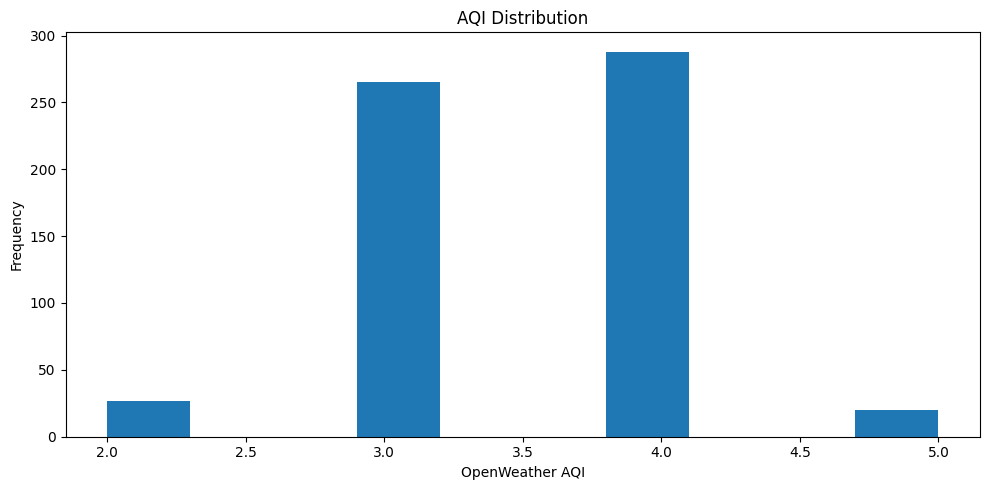

In [196]:
# ==========================================
# AQI DISTRIBUTION
# ==========================================

plt.figure(figsize=(10, 5))

plt.hist(
    training_df["api_aqi"].dropna(),
    bins=10
)

plt.title(
    "AQI Distribution"
)

plt.xlabel(
    "OpenWeather AQI"
)

plt.ylabel(
    "Frequency"
)

plt.tight_layout()
plt.show()

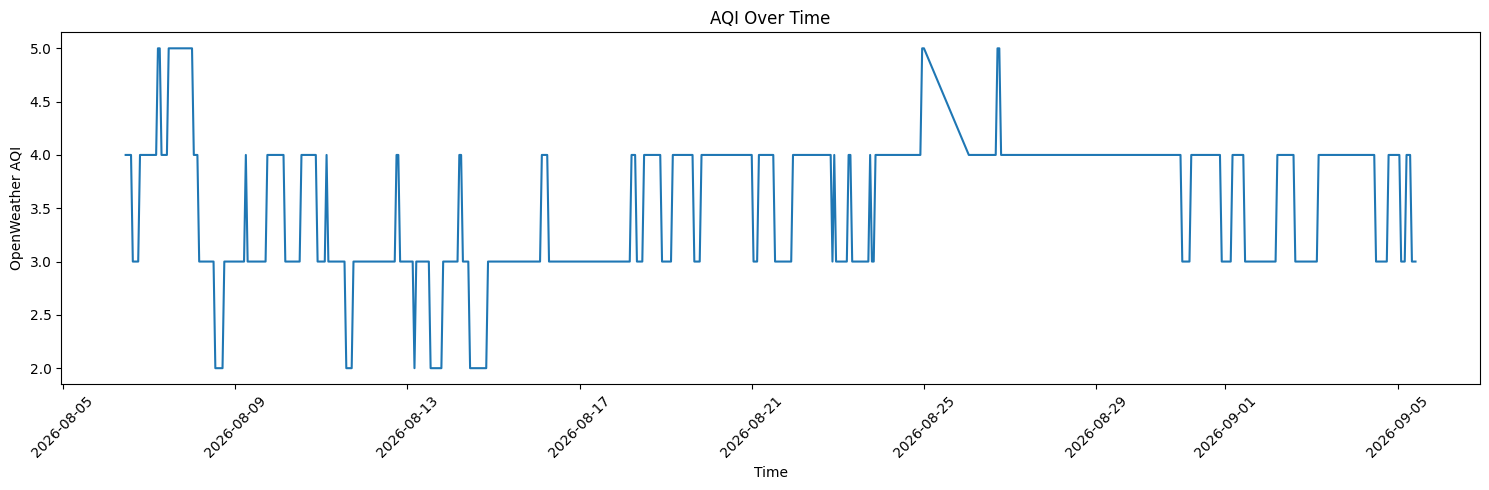

In [197]:
# ==========================================
# AQI TIME SERIES
# ==========================================

plot_df = historical_df.sort_values(
    "timestamp"
)

plt.figure(figsize=(15, 5))

plt.plot(
    plot_df["timestamp"],
    plot_df["api_aqi"]
)

plt.title(
    "AQI Over Time"
)

plt.xlabel("Time")
plt.ylabel("OpenWeather AQI")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

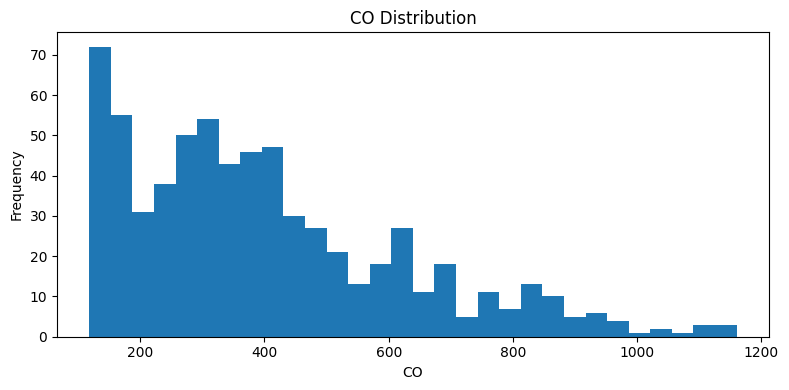

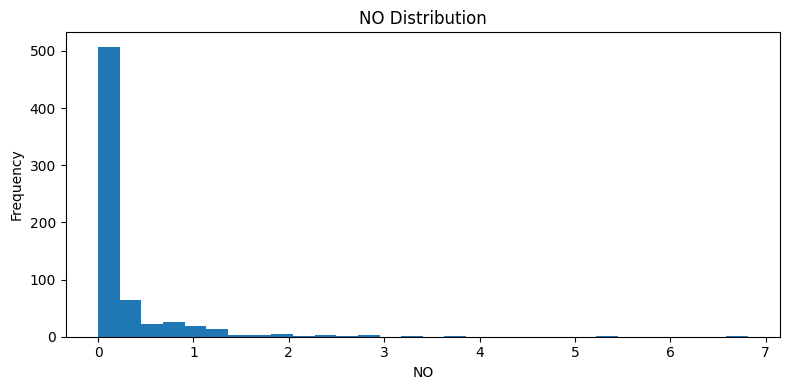

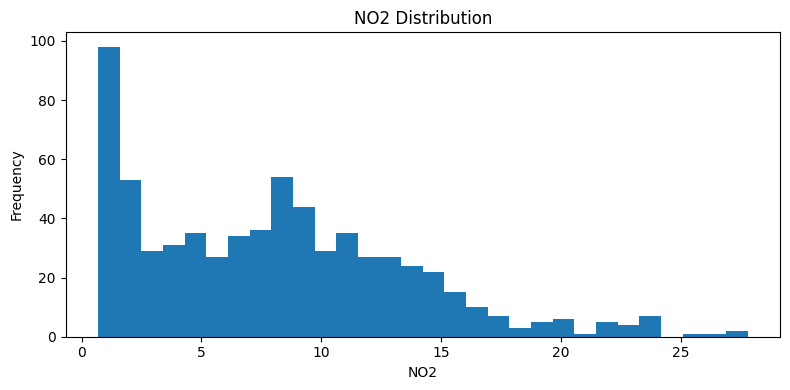

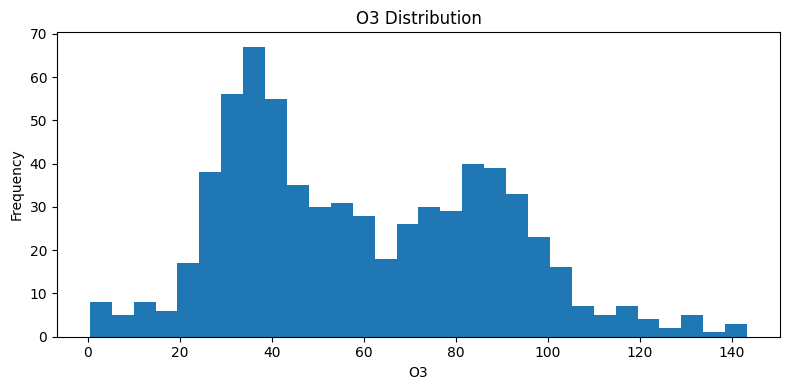

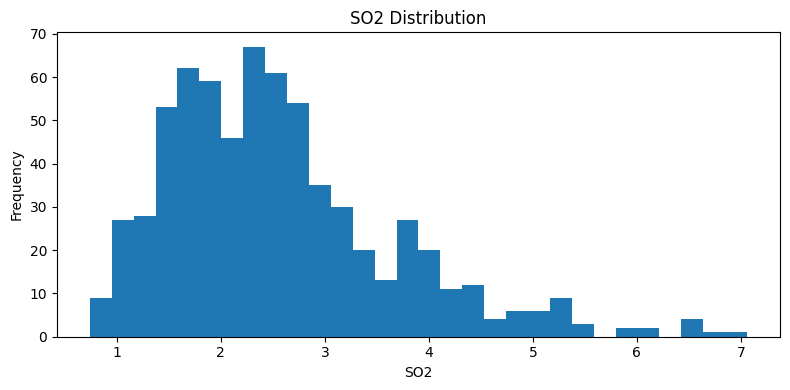

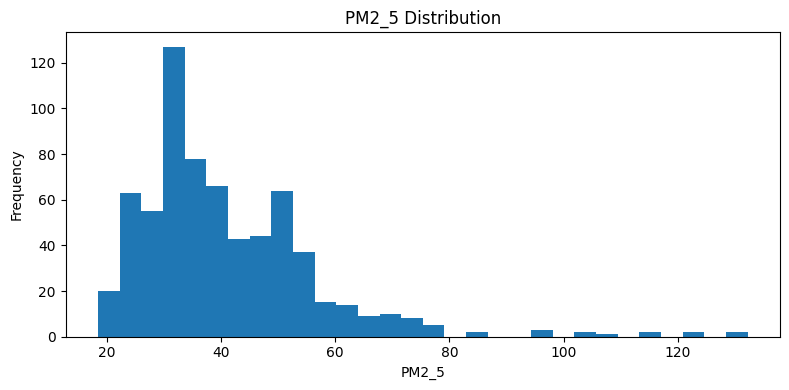

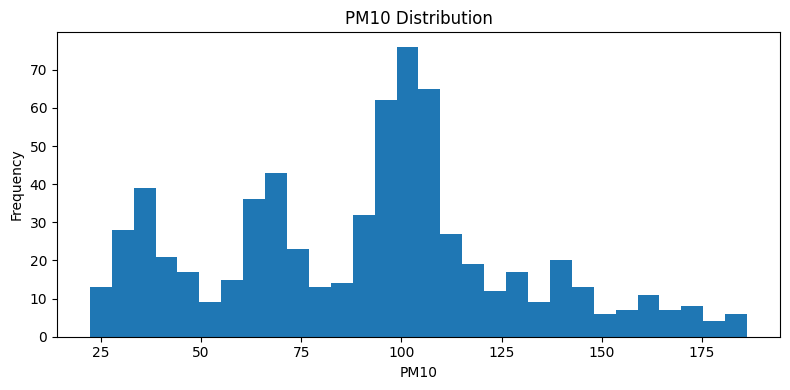

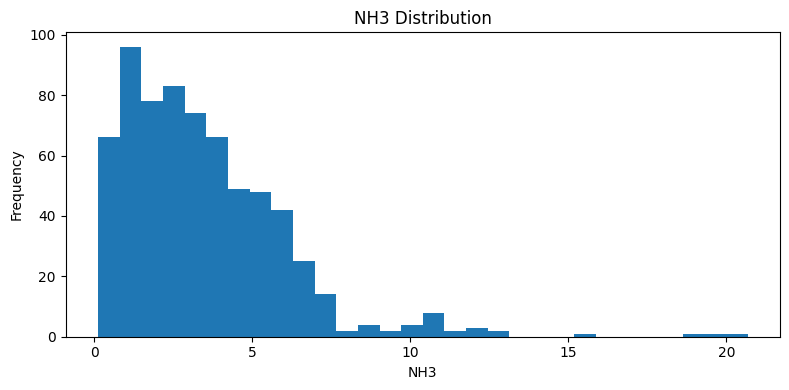

In [198]:
# ==========================================
# POLLUTANT DISTRIBUTIONS
# ==========================================

pollutants = [
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3"
]

for pollutant in pollutants:

    if pollutant in historical_df.columns:

        plt.figure(figsize=(8, 4))

        plt.hist(
            historical_df[pollutant].dropna(),
            bins=30
        )

        plt.title(
            f"{pollutant} Distribution"
        )

        plt.xlabel(pollutant)
        plt.ylabel("Frequency")

        plt.tight_layout()
        plt.show()

In [199]:
# ==========================================
# POLLUTANT STATISTICS
# ==========================================

pollutants = [
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3"
]

pollutant_stats = historical_df[
    pollutants
].describe().T

display(pollutant_stats)

,count,mean,std,min,25%,50%,75%,max
CO,672.0,402.194137,222.526049,118.03,232.1025,353.875,518.2850,1159.92
NO,672.0,0.256994,0.559536,0.00,0.0000,0.080,0.2200,6.81
NO2,672.0,7.996964,5.596838,0.69,3.0200,7.770,11.4725,27.79
O3,672.0,59.492783,28.726104,0.42,35.4075,54.475,83.5825,143.38
SO2,672.0,2.564717,1.095181,0.74,1.7600,2.370,3.0825,7.06
PM2_5,672.0,41.048452,15.829741,18.47,30.7825,37.065,49.1725,132.21
PM10,672.0,91.101354,37.027956,22.24,64.5625,96.170,109.6300,186.24
NH3,672.0,3.482619,2.607941,0.13,1.5675,2.990,4.8725,20.67


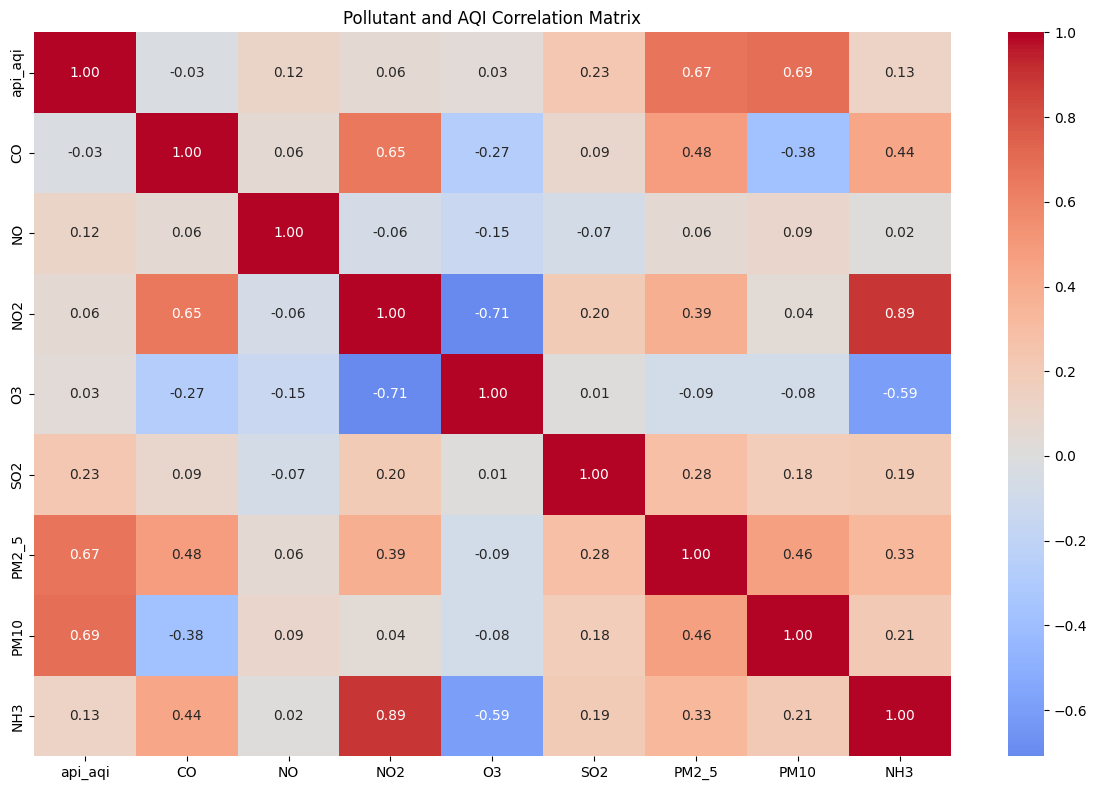

In [200]:
# ==========================================
# CORRELATION MATRIX
# ==========================================

correlation_columns = [
    "api_aqi",
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3"
]

correlation_columns = [
    col for col in correlation_columns
    if col in historical_df.columns
]

correlation = historical_df[
    correlation_columns
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Pollutant and AQI Correlation Matrix"
)

plt.tight_layout()
plt.show()

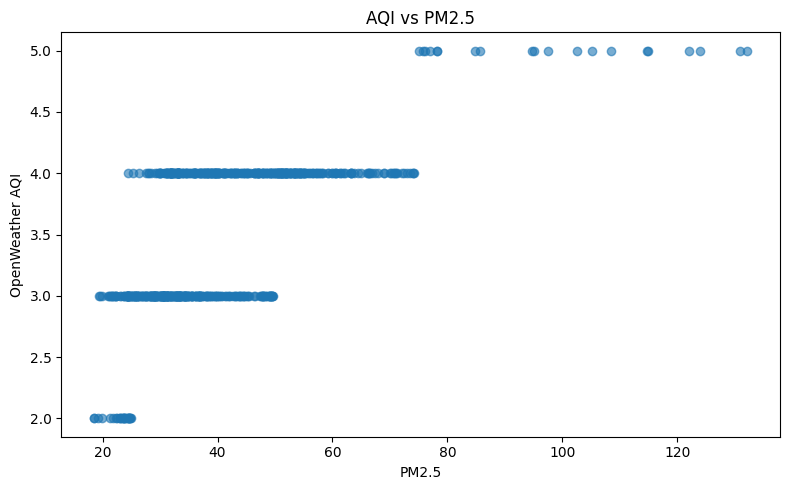

In [201]:
# ==========================================
# AQI VS PM2.5
# ==========================================

plt.figure(figsize=(8, 5))

plt.scatter(
    historical_df["PM2_5"],
    historical_df["api_aqi"],
    alpha=0.6
)

plt.title(
    "AQI vs PM2.5"
)

plt.xlabel("PM2.5")
plt.ylabel("OpenWeather AQI")

plt.tight_layout()
plt.show()

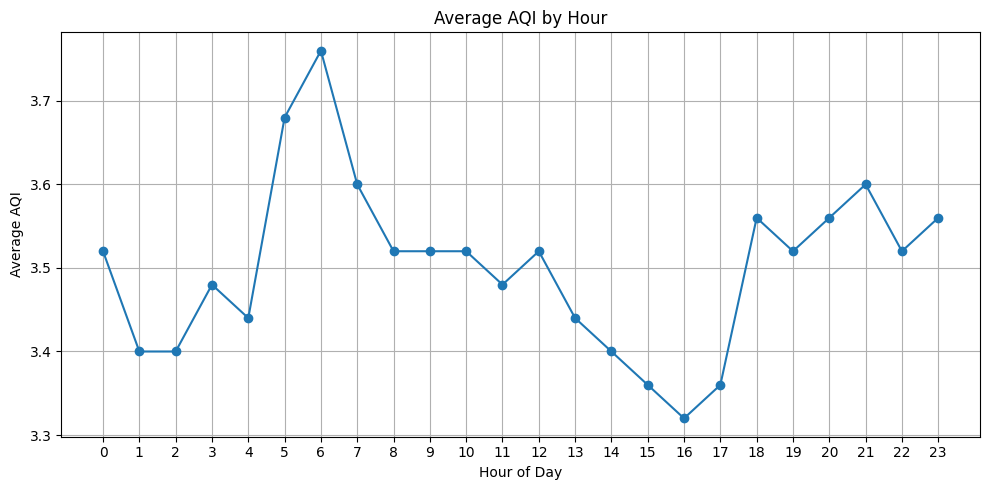

In [202]:
# ==========================================
# AQI BY HOUR
# ==========================================

hourly_aqi = training_df.groupby(
    "hour"
)["api_aqi"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_aqi.index,
    hourly_aqi.values,
    marker="o"
)

plt.title(
    "Average AQI by Hour"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average AQI")

plt.xticks(range(24))

plt.grid(True)

plt.tight_layout()
plt.show()

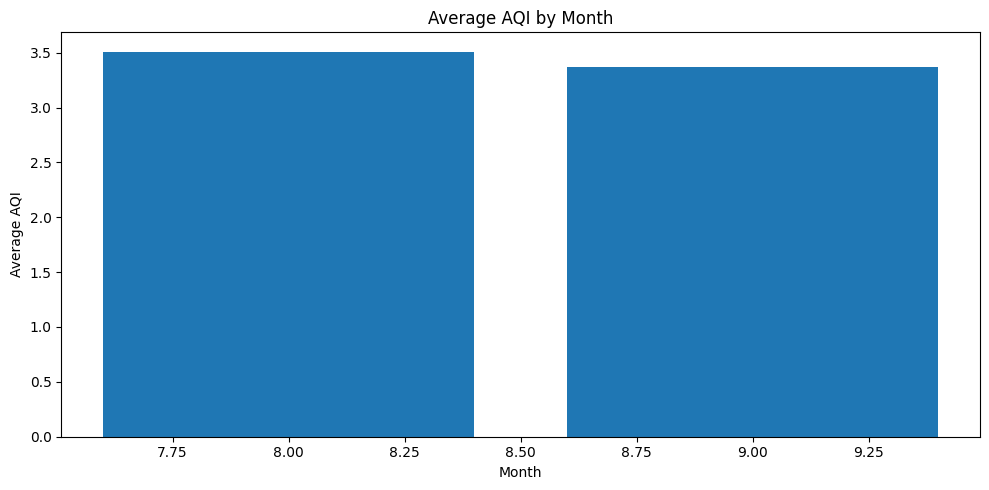

In [203]:
# ==========================================
# AQI BY MONTH
# ==========================================

monthly_aqi = training_df.groupby(
    "month"
)["api_aqi"].mean()

plt.figure(figsize=(10, 5))

plt.bar(
    monthly_aqi.index,
    monthly_aqi.values
)

plt.title(
    "Average AQI by Month"
)

plt.xlabel("Month")
plt.ylabel("Average AQI")

plt.tight_layout()
plt.show()

In [204]:
# ==========================================
# TARGET ANALYSIS
# ==========================================

targets = [
    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]

for target in targets:

    print("\n", "=" * 50)
    print(target)
    print("=" * 50)

    print(
        training_df[target].describe()
    )

    print(
        "Missing:",
        training_df[target].isnull().sum()
    )


target_AQI_24h
count    600.000000
mean       3.483333
std        0.632763
min        2.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: target_AQI_24h, dtype: float64
Missing: 0

target_AQI_48h
count    600.000000
mean       3.471667
std        0.594238
min        2.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: target_AQI_48h, dtype: float64
Missing: 0

target_AQI_72h
count    600.000000
mean       3.496667
std        0.580704
min        2.000000
25%        3.000000
50%        4.000000
75%        4.000000
max        5.000000
Name: target_AQI_72h, dtype: float64
Missing: 0


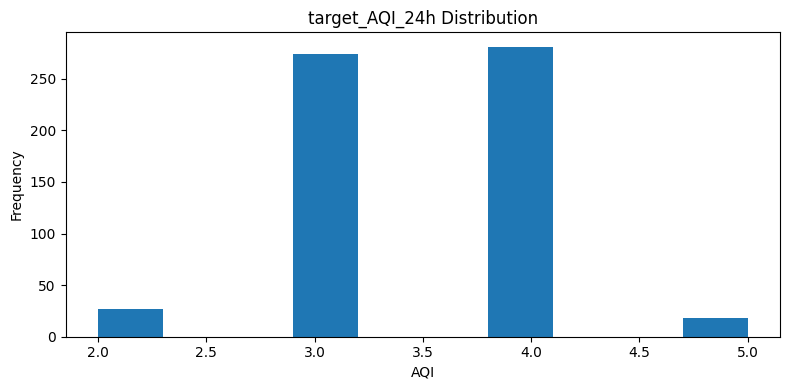

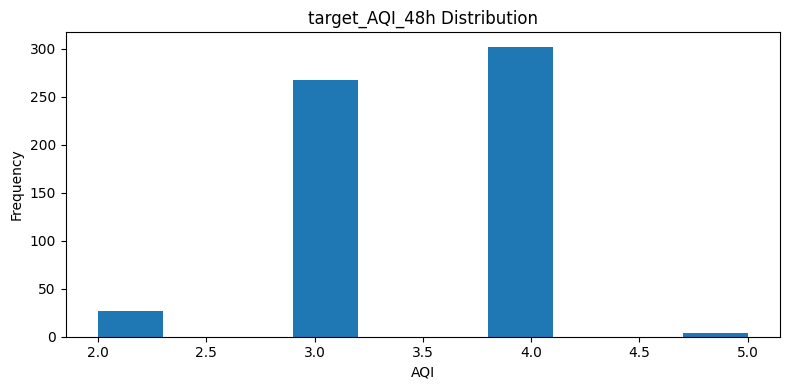

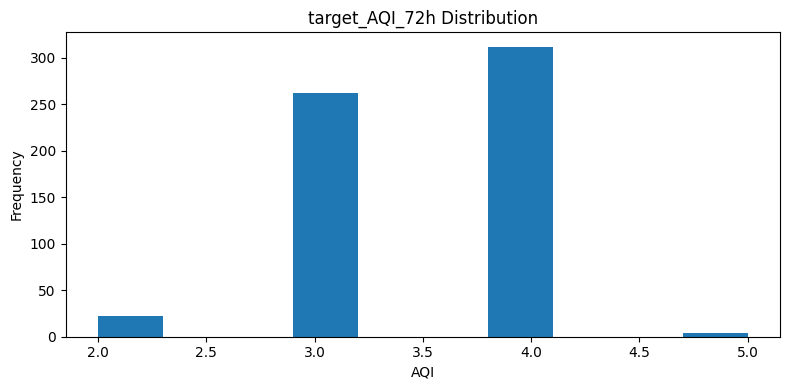

In [205]:
# ==========================================
# TARGET DISTRIBUTIONS
# ==========================================

targets = [
    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]

for target in targets:

    plt.figure(figsize=(8, 4))

    plt.hist(
        training_df[target].dropna(),
        bins=10
    )

    plt.title(
        f"{target} Distribution"
    )

    plt.xlabel("AQI")
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [206]:
# ==========================================
# LAG FEATURE CHECK
# ==========================================

lag_columns = [
    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24"
]

for column in lag_columns:

    print(
        column,
        "missing:",
        training_df[column].isnull().sum()
    )

AQI_lag_1 missing: 1
AQI_lag_3 missing: 3
AQI_lag_6 missing: 6
AQI_lag_12 missing: 12
AQI_lag_24 missing: 24


In [207]:
# ==========================================
# FEATURE RANGE CHECK
# ==========================================

features_to_check = [
    "api_aqi",
    "CO",
    "NO",
    "NO2",
    "O3",
    "SO2",
    "PM2_5",
    "PM10",
    "NH3",
    "hour",
    "day",
    "month",
    "humidity",
    "pressure",
    "wind_speed"
]

features_to_check = [
    col for col in features_to_check
    if col in training_df.columns
]

range_table = pd.DataFrame({
    "Minimum": training_df[features_to_check].min(),
    "Maximum": training_df[features_to_check].max(),
    "Mean": training_df[features_to_check].mean()
})

display(range_table)

,Minimum,Maximum,Mean
api_aqi,2.00,5.00,3.501667
CO,118.03,1159.92,415.394367
NO,0.00,6.81,0.265900
NO2,0.69,27.79,8.326467
O3,0.42,143.38,59.153533
SO2,0.74,7.06,2.486367
PM2_5,18.47,132.21,40.792317
PM10,22.24,186.24,90.669367
NH3,0.43,20.67,3.595267
hour,0.00,23.00,11.500000


In [208]:
# ==========================================
# OUTLIER DETECTION
# ==========================================

def detect_outliers_iqr(df, columns):

    results = []

    for column in columns:

        if column not in df.columns:
            continue

        data = df[column].dropna()

        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = data[
            (data < lower) |
            (data > upper)
        ]

        results.append({
            "Feature": column,
            "Q1": Q1,
            "Q3": Q3,
            "Lower Bound": lower,
            "Upper Bound": upper,
            "Outliers": len(outliers)
        })

    return pd.DataFrame(results)


outlier_table = detect_outliers_iqr(
    training_df,
    pollutants
)

display(outlier_table)

,Feature,Q1,Q3,Lower Bound,Upper Bound,Outliers
0,CO,230.8425,556.3375,-257.40000,1044.58000,8
1,NO,0.0000,0.2300,-0.34500,0.57500,83
2,NO2,3.1350,12.0150,-10.18500,25.33500,4
3,O3,34.7450,83.6025,-38.54125,156.88875,0
4,SO2,1.7275,2.9850,-0.15875,4.87125,23
5,PM2_5,30.2350,48.8925,2.24875,76.87875,17
6,PM10,62.4175,111.4050,-11.06375,184.88625,3
7,NH3,1.6575,4.9725,-3.31500,9.94500,22


In [209]:
# ==========================================
# FEATURE VS TARGET CORRELATION
# ==========================================

target = "target_AQI_24h"

numeric_df = training_df.select_dtypes(
    include=np.number
)

target_correlation = (
    numeric_df.corr()[target]
    .sort_values(ascending=False)
)

display(
    target_correlation.to_frame(
        name="Correlation"
    )
)

,Correlation
target_AQI_24h,1.000000
PM10,0.477779
AQI_lag_24,0.368783
target_AQI_72h,0.363317
day,0.308049
target_AQI_48h,0.289554
api_aqi,0.283236
AQI_rolling_mean_3,0.278107
AQI_rolling_mean_6,0.269329
AQI_lag_1,0.264981


In [210]:
# ==========================================
# CREATE CLEAN ML DATASET
# ==========================================

ml_df = training_df.copy()

required_features = [
    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",
    "AQI_change",
    "AQI_change_rate",
    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]

required_targets = [
    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]

required_columns = (
    required_features +
    required_targets
)

required_columns = [
    col for col in required_columns
    if col in ml_df.columns
]

before = len(ml_df)

ml_df = ml_df.dropna(
    subset=required_columns
)

after = len(ml_df)

print("Rows before cleaning:", before)
print("Rows after cleaning:", after)
print("Rows removed:", before - after)

Rows before cleaning: 600
Rows after cleaning: 576
Rows removed: 24


In [211]:
# ==========================================
# SAVE CLEAN DATASET
# ==========================================

clean_file = "aqi_ml_ready.csv"

ml_df.to_csv(
    clean_file,
    index=False
)

print(
    f"ML-ready dataset saved as: {clean_file}"
)

ML-ready dataset saved as: aqi_ml_ready.csv


In [212]:
# ==========================================
# FINAL QUALITY REPORT
# ==========================================

print("=" * 70)
print("AQI PREDICTOR - MODULE 3 FINAL REPORT")
print("=" * 70)

print("\nHistorical dataset:")
print("Rows:", len(historical_df))

print(
    "Date range:",
    historical_df["timestamp"].min(),
    "→",
    historical_df["timestamp"].max()
)

print("\nTraining dataset:")
print("Original rows:", len(training_df))

print("\nML-ready dataset:")
print("Rows:", len(ml_df))
print("Columns:", len(ml_df.columns))

print("\nMissing values:")
print(
    ml_df.isnull().sum().sum()
)

print("\nDuplicate rows:")
print(
    ml_df.duplicated().sum()
)

print("\nTarget columns:")

for target in required_targets:
    if target in ml_df.columns:
        print(
            f"✓ {target}"
        )

print("\nModule 3 completed successfully!")

AQI PREDICTOR - MODULE 3 FINAL REPORT

Historical dataset:
Rows: 672
Date range: 2026-08-06 11:00:00+00:00 → 2026-09-05 10:00:00+00:00

Training dataset:
Original rows: 600

ML-ready dataset:
Rows: 576
Columns: 29

Missing values:
0

Duplicate rows:
0

Target columns:
✓ target_AQI_24h
✓ target_AQI_48h
✓ target_AQI_72h

Module 3 completed successfully!


In [213]:
# ==========================================
# DOWNLOAD ML DATASET
# ==========================================

from google.colab import files

files.download(
    "aqi_ml_ready.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Module 4 — ML Model Training

In [214]:
# ==========================================
# MODULE 4
# MACHINE LEARNING MODEL TRAINING
# ==========================================

!pip install -q scikit-learn tensorflow joblib

In [215]:
# ==========================================
# MODULE 4
# MACHINE LEARNING MODEL TRAINING
# ==========================================

!pip install -q scikit-learn tensorflow joblib

In [216]:
# ==========================================
# LOAD ML DATASET
# ==========================================

ML_FILE = "aqi_ml_ready.csv"

if not os.path.exists(ML_FILE):
    raise FileNotFoundError(
        "aqi_ml_ready.csv not found. "
        "Please upload the file from Module 3."
    )

df = pd.read_csv(ML_FILE)

print("Dataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

display(df.head())

Dataset loaded successfully!
Rows: 576
Columns: 29


,city,timestamp,api_aqi,CO,NO,NO2,O3,SO2,PM2_5,PM10,...,AQI_lag_12,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,target_AQI_24h,target_AQI_48h,target_AQI_72h
0,Lahore,2026-08-07 11:00:00+00:00,5,508.32,0.22,2.85,143.29,2.88,78.16,90.02,...,4.0,4.0,1.0,0.25,4.333333,4.333333,0.516398,3.0,3.0,3.0
1,Lahore,2026-08-07 12:00:00+00:00,5,567.67,0.22,4.36,143.38,3.18,85.71,96.58,...,4.0,4.0,0.0,0.00,4.666667,4.333333,0.516398,3.0,3.0,3.0
2,Lahore,2026-08-07 13:00:00+00:00,5,679.05,0.17,9.06,123.40,3.35,94.79,105.59,...,4.0,4.0,0.0,0.00,5.000000,4.500000,0.547723,2.0,3.0,4.0
3,Lahore,2026-08-07 14:00:00+00:00,5,823.37,0.02,14.56,92.58,3.35,105.19,117.01,...,4.0,4.0,0.0,0.00,5.000000,4.666667,0.516398,2.0,3.0,4.0
4,Lahore,2026-08-07 15:00:00+00:00,5,950.93,0.00,17.84,71.65,3.34,114.97,128.19,...,4.0,3.0,0.0,0.00,5.000000,4.833333,0.408248,2.0,3.0,4.0


In [217]:
# ==========================================
# PREPARE TIMESTAMP
# ==========================================

df["timestamp"] = pd.to_datetime(
    df["timestamp"],
    utc=True,
    errors="coerce"
)

df = df.sort_values(
    "timestamp"
).reset_index(drop=True)

print("Timestamp prepared.")

print(
    "Start:",
    df["timestamp"].min()
)

print(
    "End:",
    df["timestamp"].max()
)

Timestamp prepared.
Start: 2026-08-07 11:00:00+00:00
End: 2026-09-02 10:00:00+00:00


In [218]:
# ==========================================
# FEATURE SELECTION
# ==========================================

FEATURES = [
    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",
    "AQI_change",
    "AQI_change_rate",
    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]

TARGETS = [
    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]

# Check that columns exist
missing_features = [
    col for col in FEATURES
    if col not in df.columns
]

missing_targets = [
    col for col in TARGETS
    if col not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing features: {missing_features}"
    )

if missing_targets:
    raise ValueError(
        f"Missing targets: {missing_targets}"
    )

print("All features and targets found.")

print("\nNumber of features:", len(FEATURES))

print("\nFeatures:")
for feature in FEATURES:
    print("✓", feature)

All features and targets found.

Number of features: 22

Features:
✓ PM2_5
✓ PM10
✓ CO
✓ NO2
✓ SO2
✓ O3
✓ NH3
✓ hour
✓ day
✓ month
✓ weekday
✓ is_weekend
✓ AQI_lag_1
✓ AQI_lag_3
✓ AQI_lag_6
✓ AQI_lag_12
✓ AQI_lag_24
✓ AQI_change
✓ AQI_change_rate
✓ AQI_rolling_mean_3
✓ AQI_rolling_mean_6
✓ AQI_rolling_std_6


In [219]:
# ==========================================
# 24-HOUR FORECAST DATA
# ==========================================

target = "target_AQI_24h"

model_df = df[
    FEATURES + [target]
].copy()

# Remove missing values
model_df = model_df.dropna()

print("=" * 60)
print("24-HOUR FORECAST DATA")
print("=" * 60)

print("Rows:", len(model_df))
print("Features:", len(FEATURES))
print("Target:", target)

display(model_df.head())

24-HOUR FORECAST DATA
Rows: 576
Features: 22
Target: target_AQI_24h


,PM2_5,PM10,CO,NO2,SO2,O3,NH3,hour,day,month,...,AQI_lag_3,AQI_lag_6,AQI_lag_12,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,target_AQI_24h
0,78.16,90.02,508.32,2.85,2.88,143.29,1.56,11,7,8,...,4.0,5.0,4.0,4.0,1.0,0.25,4.333333,4.333333,0.516398,3.0
1,85.71,96.58,567.67,4.36,3.18,143.38,2.26,12,7,8,...,4.0,5.0,4.0,4.0,0.0,0.00,4.666667,4.333333,0.516398,3.0
2,94.79,105.59,679.05,9.06,3.35,123.40,4.13,13,7,8,...,4.0,4.0,4.0,4.0,0.0,0.00,5.000000,4.500000,0.547723,2.0
3,105.19,117.01,823.37,14.56,3.35,92.58,6.59,14,7,8,...,5.0,4.0,4.0,4.0,0.0,0.00,5.000000,4.666667,0.516398,2.0
4,114.97,128.19,950.93,17.84,3.34,71.65,8.55,15,7,8,...,5.0,4.0,4.0,3.0,0.0,0.00,5.000000,4.833333,0.408248,2.0


In [220]:
# ==========================================
# TARGET CHECK
# ==========================================

print(
    model_df[target].describe()
)

print(
    "\nUnique target values:"
)

print(
    sorted(
        model_df[target].unique()
    )
)

count    576.000000
mean       3.449653
std        0.596424
min        2.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        5.000000
Name: target_AQI_24h, dtype: float64

Unique target values:
[np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]


In [221]:
# ==========================================
# TIME-SERIES SPLIT
# ==========================================

X = model_df[FEATURES]

y = model_df[target]

split_index = int(
    len(model_df) * 0.80
)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining period:")
print(
    model_df.iloc[0]["timestamp"]
    if "timestamp" in model_df.columns
    else "timestamp not included"
)

print("\nTest samples created successfully.")

Training samples: 460
Testing samples: 116

Training period:
timestamp not included

Test samples created successfully.


In [222]:
# ==========================================
# IMPORT STANDARD SCALER
# ==========================================

from sklearn.preprocessing import StandardScaler

print("StandardScaler imported successfully!")

StandardScaler imported successfully!


In [223]:
# ==========================================
# FEATURE SCALING
# ==========================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Feature scaling completed.")

print(
    "Training shape:",
    X_train_scaled.shape
)

print(
    "Testing shape:",
    X_test_scaled.shape
)

Feature scaling completed.
Training shape: (460, 22)
Testing shape: (116, 22)


In [224]:
# ==========================================
# EVALUATION FUNCTION
# ==========================================

def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [225]:
# ==========================================
# EVALUATION FUNCTION
# ==========================================

def evaluate_model(
    model_name,
    y_true,
    y_pred
):

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_true,
            y_pred
        )
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("=" * 60)
    print(model_name)
    print("=" * 60)

    print(
        f"MAE  : {mae:.4f}"
    )

    print(
        f"RMSE : {rmse:.4f}"
    )

    print(
        f"R²   : {r2:.4f}"
    )

    return {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

In [226]:
# ==========================================
# IMPORT RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestRegressor

print("RandomForestRegressor imported successfully!")

RandomForestRegressor imported successfully!


In [227]:
# ==========================================
# MODULE 4 - ALL IMPORTS
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("========================================")
print("ALL MODULE 4 IMPORTS LOADED")
print("========================================")

ALL MODULE 4 IMPORTS LOADED


In [228]:
# ==========================================
# RANDOM FOREST
# ==========================================

rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_predictions = rf_model.predict(
    X_test
)

rf_result = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

Random Forest
MAE  : 0.3727
RMSE : 0.5965
R²   : -0.5403


In [229]:
ridge_model = Ridge(
    alpha=1.0, # Regularization strength
    random_state=42
)

ridge_model.fit(
    X_train_scaled,
    y_train
)

ridge_predictions = ridge_model.predict(
    X_test_scaled
)

ridge_result = evaluate_model(
    "Ridge Regression",
    y_test,
    ridge_predictions
)

# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame([
    ridge_result,
    rf_result
])

display(
    results.sort_values(
        "RMSE"
    )
)

Ridge Regression
MAE  : 0.6332
RMSE : 0.7859
R²   : -1.6744


,Model,MAE,RMSE,R2
1,Random Forest,0.372651,0.596471,-0.540329
0,Ridge Regression,0.633242,0.785946,-1.674365


In [230]:
# ==========================================
# MODEL COMPARISON
# ==========================================

results = pd.DataFrame([
    ridge_result,
    rf_result
])

display(
    results.sort_values(
        "RMSE"
    )
)

,Model,MAE,RMSE,R2
1,Random Forest,0.372651,0.596471,-0.540329
0,Ridge Regression,0.633242,0.785946,-1.674365


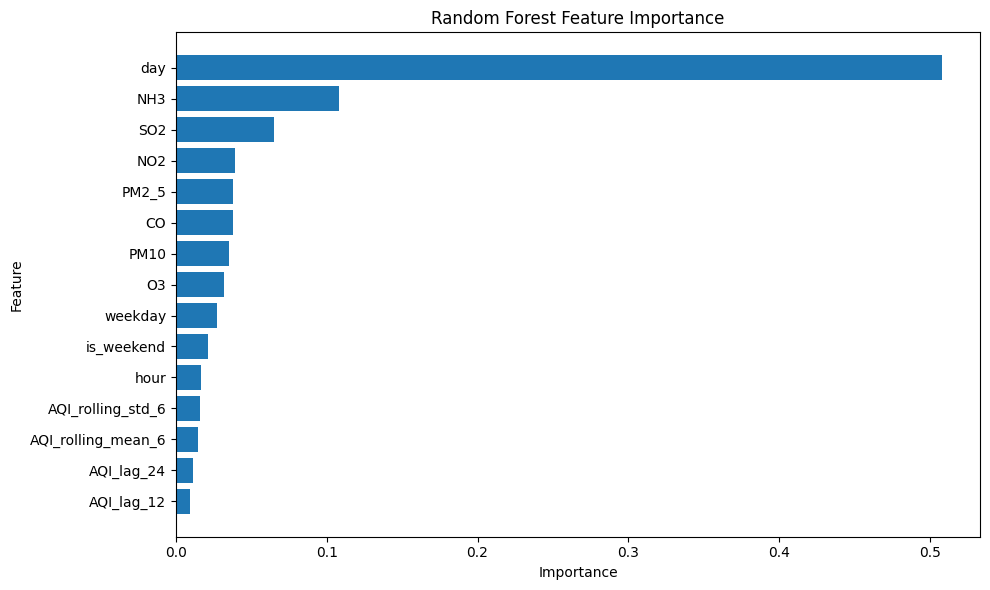

In [231]:
# ==========================================
# FEATURE IMPORTANCE PLOT
# ==========================================

# Get feature importances from the Random Forest model
importance_df = pd.DataFrame({
    "Feature": FEATURES,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

top_features = importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title(
    "Random Forest Feature Importance"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.show()

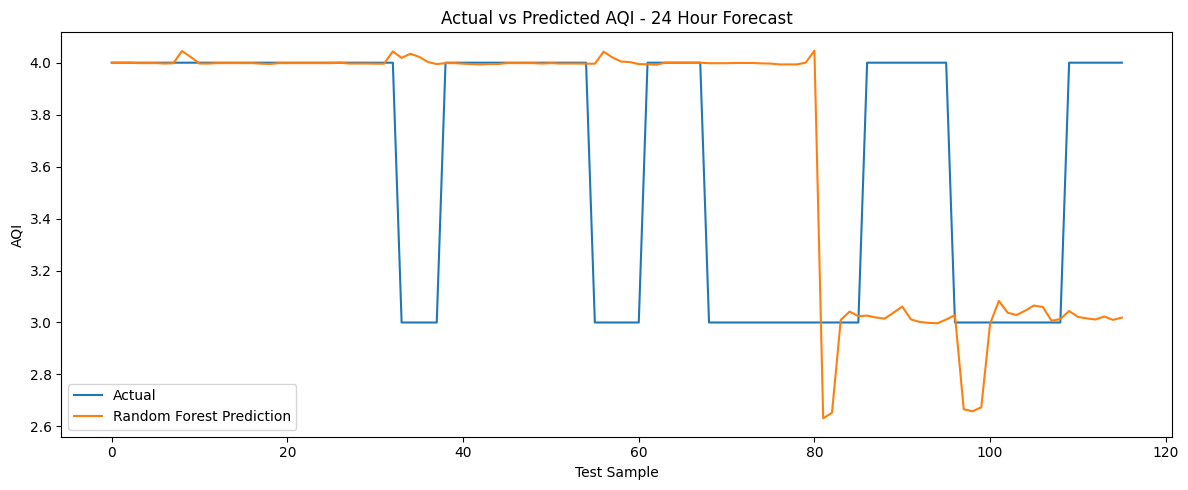

In [232]:
# ==========================================
# ACTUAL VS PREDICTED
# ==========================================

plt.figure(figsize=(12, 5))

plt.plot(
    y_test.values,
    label="Actual"
)

plt.plot(
    rf_predictions,
    label="Random Forest Prediction"
)

plt.title(
    "Actual vs Predicted AQI - 24 Hour Forecast"
)

plt.xlabel("Test Sample")
plt.ylabel("AQI")

plt.legend()

plt.tight_layout()

plt.show()

In [233]:
# ==========================================
# TENSORFLOW NEURAL NETWORK
# ==========================================

tf.random.set_seed(42)
np.random.seed(42)

nn_model = keras.Sequential([

    layers.Input(
        shape=(X_train_scaled.shape[1],)
    ),

    layers.Dense(
        64,
        activation="relu"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        32,
        activation="relu"
    ),

    layers.Dropout(0.2),

    layers.Dense(
        16,
        activation="relu"
    ),

    layers.Dense(
        1
    )
])

nn_model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="mse",
    metrics=["mae"]
)

nn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [234]:
# ==========================================
# TRAIN NEURAL NETWORK
# ==========================================

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=15,
    restore_best_weights=True
)

history = nn_model.fit(
    X_train_scaled,
    y_train,

    validation_split=0.15,

    epochs=100,
    batch_size=32,

    callbacks=[
        early_stopping
    ],

    verbose=1
)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 99ms/step - loss: 8.0458 - mae: 2.7297 - val_loss: 9.0931 - val_mae: 2.9913
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3.8961 - mae: 1.7976 - val_loss: 2.7634 - val_mae: 1.5445
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 1.9092 - mae: 1.1461 - val_loss: 0.7235 - val_mae: 0.6590
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 1.7143 - mae: 1.0120 - val_loss: 0.9254 - val_mae: 0.7852
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 1.1901 - mae: 0.8494 - val_loss: 0.9085 - val_mae: 0.7693
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1.1086 - mae: 0.8530 - val_loss: 1.3642 - val_mae: 0.9891
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.9681 - mae: 0.7881 - val_loss: 1.0241 - val_mae: 0.8539
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1.0020 - mae: 0.7792 - val_loss: 0.8446 - val_mae: 0.7599
Epoch 9/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - lo

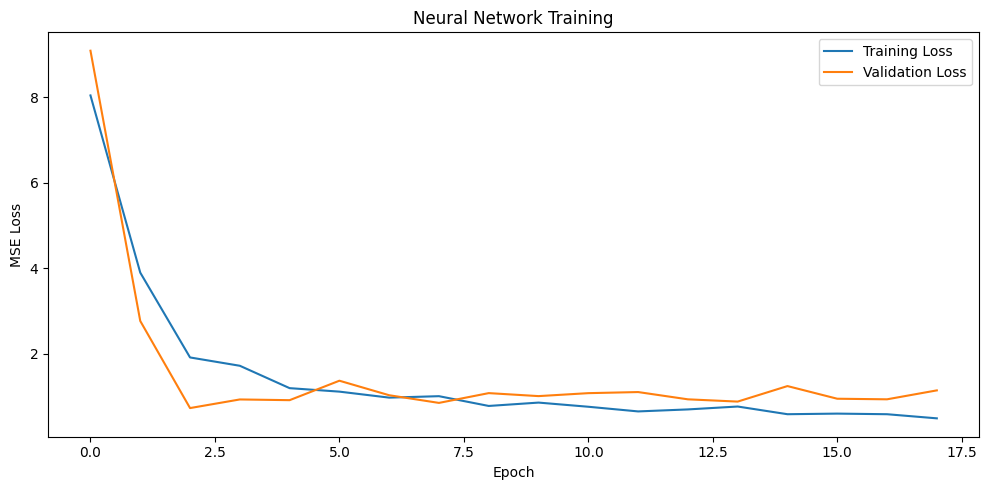

In [235]:
# ==========================================
# TRAINING HISTORY
# ==========================================

plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "Neural Network Training"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")

plt.legend()

plt.tight_layout()

plt.show()

In [236]:
# ==========================================
# NEURAL NETWORK PREDICTIONS
# ==========================================

nn_predictions = nn_model.predict(
    X_test_scaled,
    verbose=0
).flatten()

nn_result = evaluate_model(
    "TensorFlow Neural Network",
    y_test,
    nn_predictions
)

TensorFlow Neural Network
MAE  : 0.7539
RMSE : 0.9303
R²   : -2.7469


In [237]:
# ==========================================
# FINAL MODEL COMPARISON
# ==========================================

results = pd.DataFrame([
    ridge_result,
    rf_result,
    nn_result
])

results = results.sort_values(
    "RMSE"
).reset_index(drop=True)

print("=" * 70)
print("MODEL COMPARISON - 24 HOUR AQI FORECAST")
print("=" * 70)

display(results)

MODEL COMPARISON - 24 HOUR AQI FORECAST


,Model,MAE,RMSE,R2
0,Random Forest,0.372651,0.596471,-0.540329
1,Ridge Regression,0.633242,0.785946,-1.674365
2,TensorFlow Neural Network,0.753944,0.930294,-2.746926


In [238]:
# ==========================================
# SELECT BEST MODEL
# ==========================================

best_model_name = results.iloc[0]["Model"]

print(
    "Best model based on RMSE:",
    best_model_name
)

Best model based on RMSE: Random Forest


In [239]:
# ==========================================
# SAVE MODELS
# ==========================================

MODEL_DIR = "models"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

# Save Ridge
joblib.dump(
    ridge_model,
    f"{MODEL_DIR}/ridge_24h.pkl"
)

# Save Random Forest
joblib.dump(
    rf_model,
    f"{MODEL_DIR}/random_forest_24h.pkl"
)

# Save scaler
joblib.dump(
    scaler,
    f"{MODEL_DIR}/scaler_24h.pkl"
)

# Save TensorFlow model
nn_model.save(
    f"{MODEL_DIR}/neural_network_24h.keras"
)

# Save results
results.to_csv(
    f"{MODEL_DIR}/model_comparison_24h.csv",
    index=False
)

print("Models saved successfully!")

print("\nSaved files:")

for file in os.listdir(MODEL_DIR):
    print("✓", file)

Models saved successfully!

Saved files:
✓ model_comparison_24h.csv
✓ neural_network_24h.keras
✓ scaler_24h.pkl
✓ ridge_24h.pkl
✓ random_forest_24h.pkl


In [240]:
# ==========================================
# TEST SAVED RANDOM FOREST
# ==========================================

loaded_rf = joblib.load(
    f"{MODEL_DIR}/random_forest_24h.pkl"
)

loaded_predictions = loaded_rf.predict(
    X_test
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

print(
    "Loaded model RMSE:",
    round(loaded_rmse, 4)
)

Loaded model RMSE: 0.5965


In [241]:
# ==========================================
# TRAIN 24H / 48H / 72H MODELS
# ==========================================

all_results = []

trained_models = {}

for target in TARGETS:

    print("\n")
    print("=" * 70)
    print("TRAINING:", target)
    print("=" * 70)

    temp_df = df[
        FEATURES + [target]
    ].dropna().copy()

    X = temp_df[FEATURES]
    y = temp_df[target]

    split_index = int(
        len(temp_df) * 0.80
    )

    X_train = X.iloc[:split_index]
    X_test = X.iloc[split_index:]

    y_train = y.iloc[:split_index]
    y_test = y.iloc[split_index:]

    # Scaling
    scaler_temp = StandardScaler()

    X_train_scaled = scaler_temp.fit_transform(
        X_train
    )

    X_test_scaled = scaler_temp.transform(
        X_test
    )

    # --------------------------------------
    # Ridge
    # --------------------------------------

    ridge = Ridge(alpha=1.0)

    ridge.fit(
        X_train_scaled,
        y_train
    )

    pred = ridge.predict(
        X_test_scaled
    )

    ridge_metrics = evaluate_model(
        f"Ridge - {target}",
        y_test,
        pred
    )

    ridge_metrics["Target"] = target

    all_results.append(
        ridge_metrics
    )

    # --------------------------------------
    # Random Forest
    # --------------------------------------

    rf = RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_split=4,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf.fit(
        X_train,
        y_train
    )

    pred = rf.predict(
        X_test
    )

    rf_metrics = evaluate_model(
        f"Random Forest - {target}",
        y_test,
        pred
    )

    rf_metrics["Target"] = target

    all_results.append(
        rf_metrics
    )

    # --------------------------------------
    # Store best candidates
    # --------------------------------------

    trained_models[target] = {
        "ridge": ridge,
        "random_forest": rf,
        "scaler": scaler_temp
    }

print("\nAll forecasting horizons trained.")



TRAINING: target_AQI_24h
Ridge - target_AQI_24h
MAE  : 0.6332
RMSE : 0.7859
R²   : -1.6744
Random Forest - target_AQI_24h
MAE  : 0.3727
RMSE : 0.5965
R²   : -0.5403


TRAINING: target_AQI_48h
Ridge - target_AQI_48h
MAE  : 0.8009
RMSE : 0.9265
R²   : -2.7167
Random Forest - target_AQI_48h
MAE  : 0.4884
RMSE : 0.6606
R²   : -0.8893


TRAINING: target_AQI_72h
Ridge - target_AQI_72h
MAE  : 0.7672
RMSE : 0.9367
R²   : -2.5774
Random Forest - target_AQI_72h
MAE  : 0.4780
RMSE : 0.5995
R²   : -0.4655

All forecasting horizons trained.


In [242]:
# ==========================================
# ALL MODEL RESULTS
# ==========================================

all_results_df = pd.DataFrame(
    all_results
)

all_results_df = all_results_df[
    [
        "Target",
        "Model",
        "MAE",
        "RMSE",
        "R2"
    ]
]

display(
    all_results_df.sort_values(
        ["Target", "RMSE"]
    )
)

,Target,Model,MAE,RMSE,R2
1,target_AQI_24h,Random Forest - target_AQI_24h,0.372651,0.596471,-0.540329
0,target_AQI_24h,Ridge - target_AQI_24h,0.633242,0.785946,-1.674365
3,target_AQI_48h,Random Forest - target_AQI_48h,0.488431,0.660589,-0.889284
2,target_AQI_48h,Ridge - target_AQI_48h,0.800873,0.926537,-2.716723
5,target_AQI_72h,Random Forest - target_AQI_72h,0.477965,0.599502,-0.465493
4,target_AQI_72h,Ridge - target_AQI_72h,0.767216,0.936666,-2.577433


In [243]:
# ==========================================
# BEST MODEL PER FORECAST HORIZON
# ==========================================

best_models = (
    all_results_df
    .sort_values("RMSE")
    .groupby("Target")
    .first()
    .reset_index()
)

print(
    "Best model for each forecast horizon:"
)

display(best_models)

Best model for each forecast horizon:


,Target,Model,MAE,RMSE,R2
0,target_AQI_24h,Random Forest - target_AQI_24h,0.372651,0.596471,-0.540329
1,target_AQI_48h,Random Forest - target_AQI_48h,0.488431,0.660589,-0.889284
2,target_AQI_72h,Random Forest - target_AQI_72h,0.477965,0.599502,-0.465493


In [244]:
# ==========================================
# SAVE ALL RESULTS
# ==========================================

all_results_df.to_csv(
    "model_results_all_horizons.csv",
    index=False
)

best_models.to_csv(
    "best_models_by_horizon.csv",
    index=False
)

print("Results saved successfully!")

Results saved successfully!


In [245]:
# ==========================================
# SAVE 24H / 48H / 72H MODELS
# ==========================================

for target in TARGETS:

    models = trained_models[target]

    horizon = target.replace(
        "target_AQI_",
        ""
    )

    joblib.dump(
        models["ridge"],
        f"{MODEL_DIR}/ridge_{horizon}.pkl"
    )

    joblib.dump(
        models["random_forest"],
        f"{MODEL_DIR}/random_forest_{horizon}.pkl"
    )

    joblib.dump(
        models["scaler"],
        f"{MODEL_DIR}/scaler_{horizon}.pkl"
    )

print("All models saved!")

All models saved!


In [246]:
# ==========================================
# MODEL DIRECTORY
# ==========================================

print("=" * 60)
print("SAVED MODELS")
print("=" * 60)

for root, dirs, files_list in os.walk(MODEL_DIR):

    for file in files_list:
        print(
            "✓",
            os.path.join(root, file)
        )

SAVED MODELS
✓ models/model_comparison_24h.csv
✓ models/neural_network_24h.keras
✓ models/random_forest_72h.pkl
✓ models/scaler_24h.pkl
✓ models/scaler_72h.pkl
✓ models/scaler_48h.pkl
✓ models/ridge_24h.pkl
✓ models/ridge_72h.pkl
✓ models/random_forest_48h.pkl
✓ models/random_forest_24h.pkl
✓ models/ridge_48h.pkl


**Module 5: SHAP Model Explainability**

PEARLS AQI PREDICTOR — MODULE 5
SHAP MODEL EXPLAINABILITY

SHAP version: 0.52.0

Dataset loaded successfully!
Rows: 576
Columns: 29

All required features are available.

Available Random Forest models:
✓ 24-hour model: models/random_forest_24h.pkl
✓ 48-hour model: models/random_forest_48h.pkl
✓ 72-hour model: models/random_forest_72h.pkl

SHAP output directory: shap_results


SHAP ANALYSIS — 24-HOUR FORECAST

Model loaded successfully.
Model type: RandomForestRegressor

Rows used for SHAP: 300
Number of features: 22

Creating SHAP TreeExplainer...
Calculating SHAP values...
SHAP values calculated.
SHAP matrix shape: (300, 22)


TOP FEATURES — 24H
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.514192
1,NH3,0.056920
2,SO2,0.026206
3,PM2_5,0.024322
4,CO,0.024312
5,AQI_rolling_std_6,0.018345
6,weekday,0.014019
7,O3,0.012595
8,is_weekend,0.012447
9,AQI_rolling_mean_6,0.011206


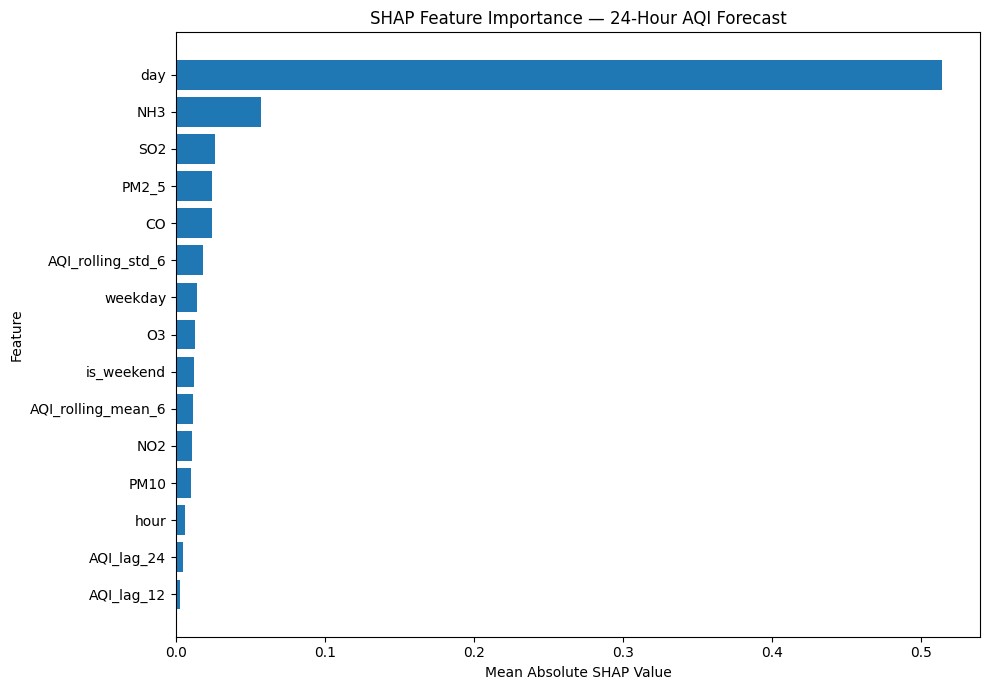


Generating SHAP summary plot...


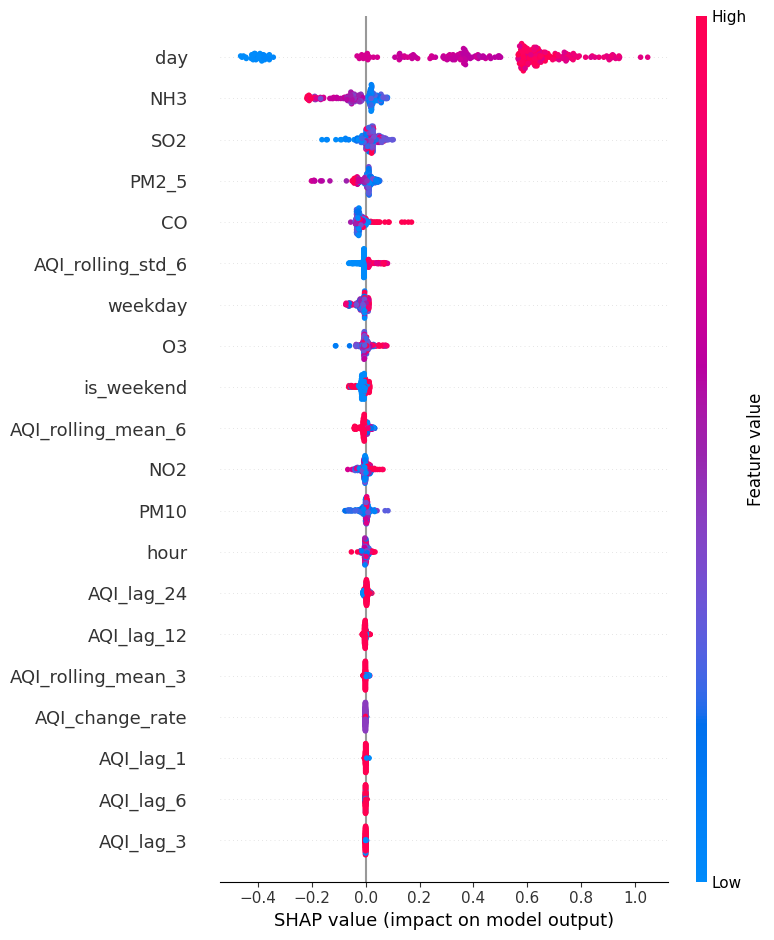



INDIVIDUAL PREDICTION — 24H

Actual AQI: 4.0
Predicted AQI: 3.0189
Prediction error: 0.9811

Top factors influencing this prediction:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,day,2.00,-0.371036,0.371036
1,NH3,1.08,0.056940,0.056940
2,SO2,1.52,-0.021817,0.021817
3,PM2_5,31.88,0.021258,0.021258
4,weekday,2.00,-0.019086,0.019086
5,NO2,0.87,-0.017506,0.017506
6,CO,138.73,-0.014651,0.014651
7,is_weekend,0.00,-0.013365,0.013365
8,AQI_lag_24,4.00,0.007983,0.007983
9,AQI_rolling_mean_6,4.00,-0.005441,0.005441


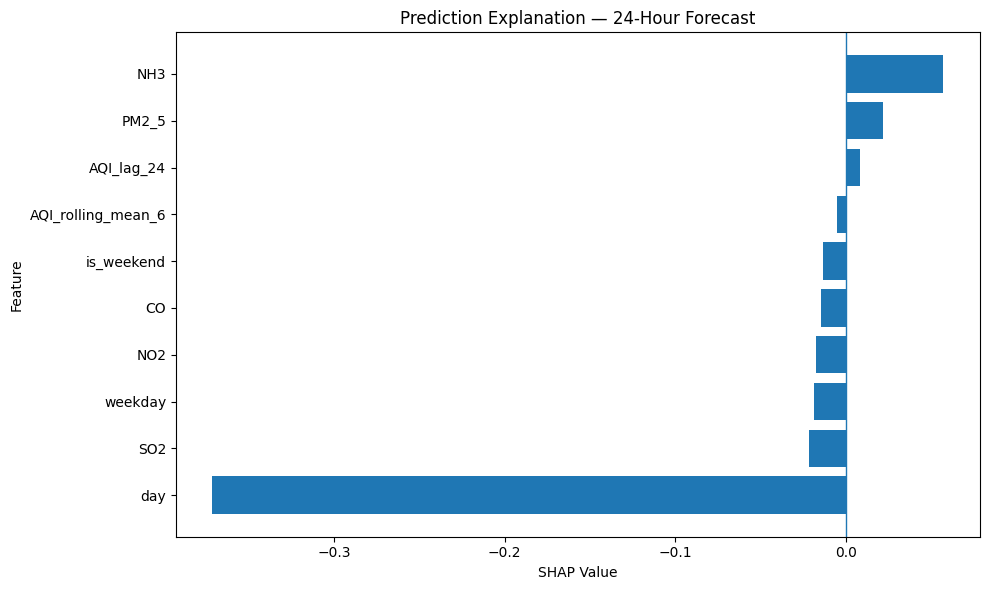



SHAP ANALYSIS — 48-HOUR FORECAST

Model loaded successfully.
Model type: RandomForestRegressor

Rows used for SHAP: 300
Number of features: 22

Creating SHAP TreeExplainer...
Calculating SHAP values...
SHAP values calculated.
SHAP matrix shape: (300, 22)


TOP FEATURES — 48H
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.336138
1,PM10,0.145031
2,NH3,0.033324
3,SO2,0.029631
4,O3,0.025501
5,NO2,0.013839
6,AQI_lag_24,0.011426
7,hour,0.011363
8,CO,0.009361
9,AQI_rolling_mean_3,0.009288


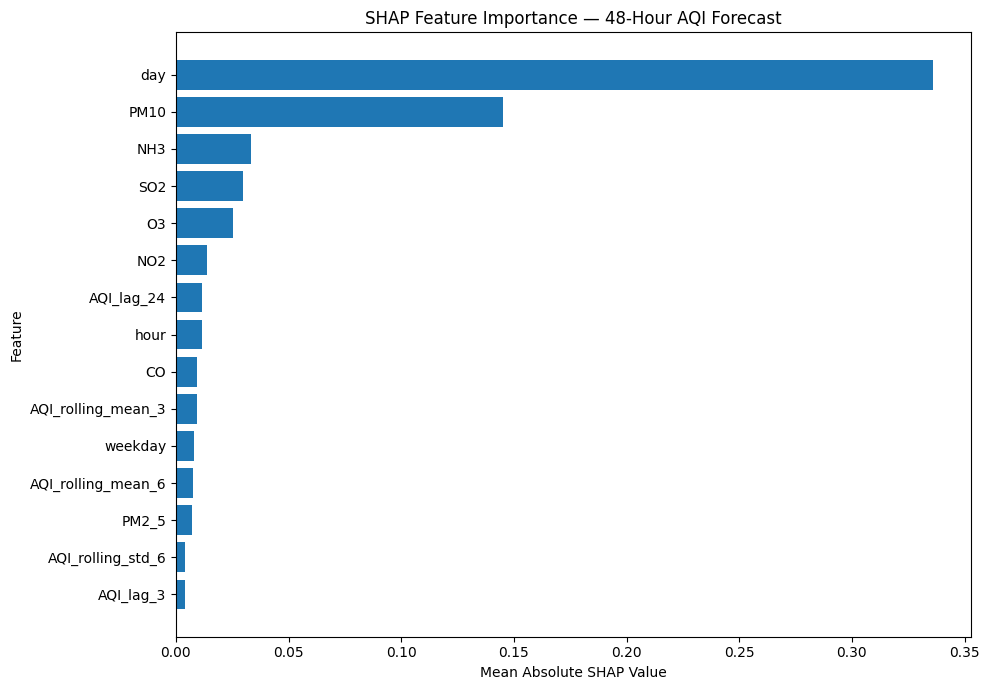


Generating SHAP summary plot...


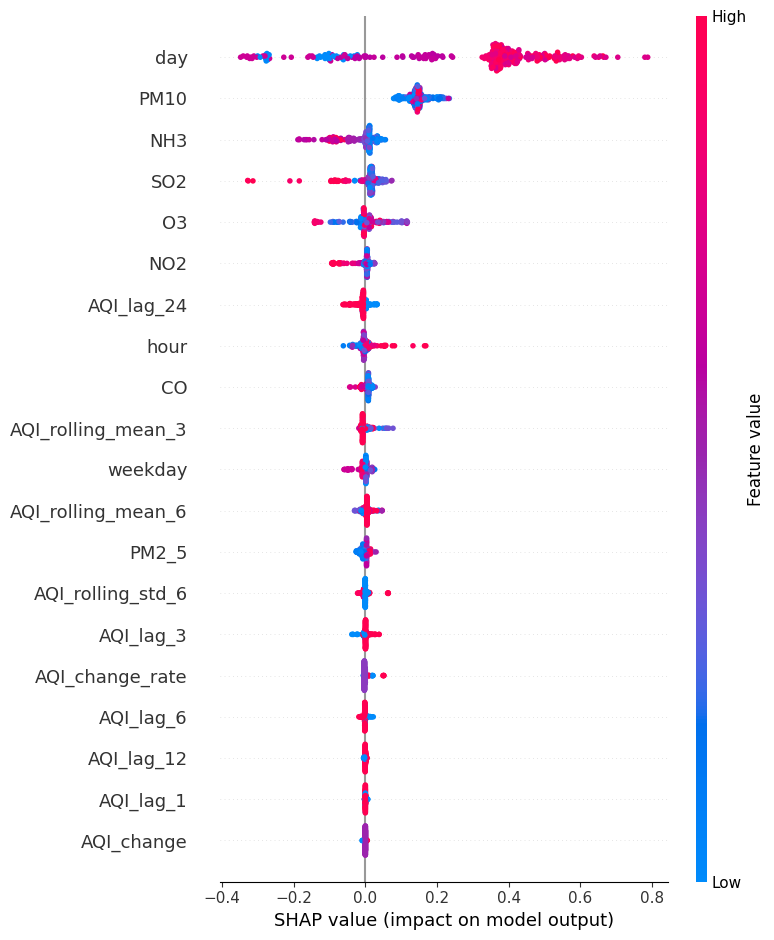



INDIVIDUAL PREDICTION — 48H

Actual AQI: 4.0
Predicted AQI: 3.2906
Prediction error: 0.7094

Top factors influencing this prediction:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,day,2.00,-0.275726,0.275726
1,PM10,106.07,0.204659,0.204659
2,O3,87.12,-0.141604,0.141604
3,NH3,1.08,0.031077,0.031077
4,SO2,1.52,0.026019,0.026019
5,PM2_5,31.88,-0.017638,0.017638
6,CO,138.73,0.017030,0.017030
7,hour,10.00,-0.007453,0.007453
8,AQI_lag_24,4.00,-0.007376,0.007376
9,NO2,0.87,-0.003030,0.003030


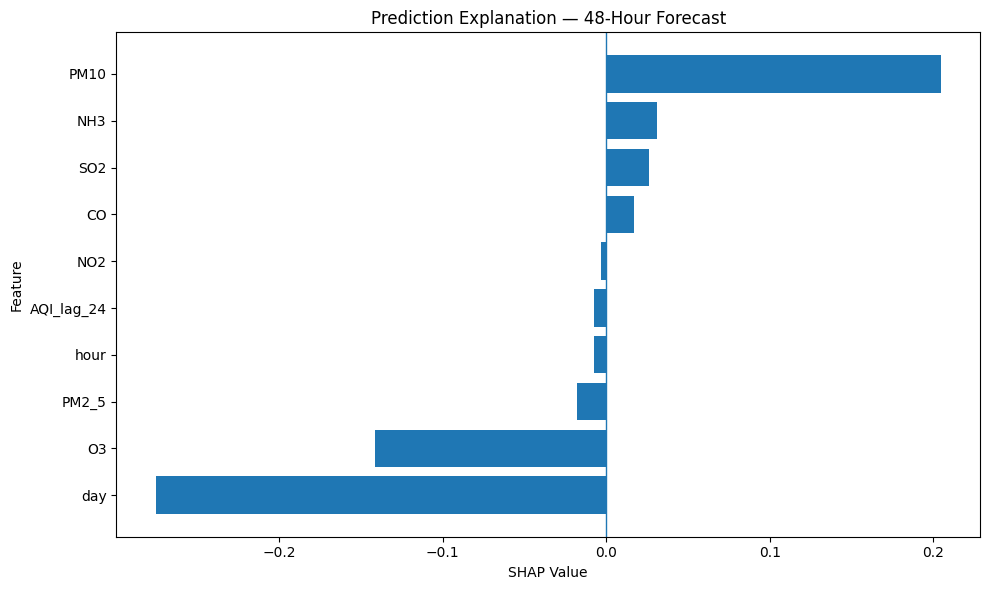



SHAP ANALYSIS — 72-HOUR FORECAST

Model loaded successfully.
Model type: RandomForestRegressor

Rows used for SHAP: 300
Number of features: 22

Creating SHAP TreeExplainer...
Calculating SHAP values...
SHAP values calculated.
SHAP matrix shape: (300, 22)


TOP FEATURES — 72H
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.366998
1,SO2,0.036855
2,O3,0.033805
3,hour,0.028226
4,PM10,0.026365
5,CO,0.020857
6,NH3,0.019699
7,weekday,0.013508
8,NO2,0.010931
9,PM2_5,0.008292


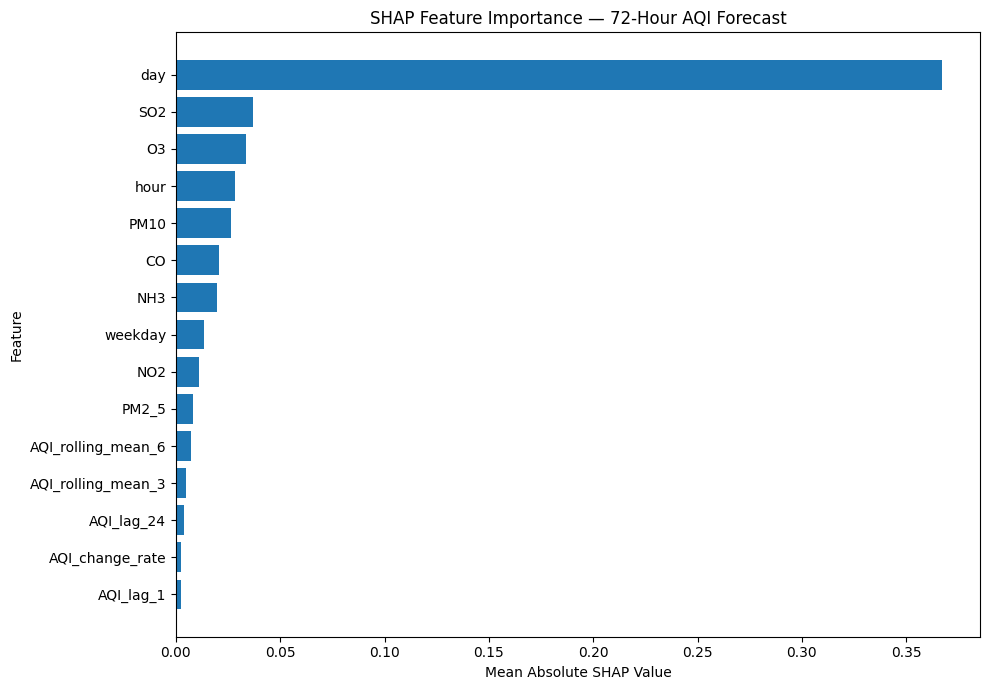


Generating SHAP summary plot...


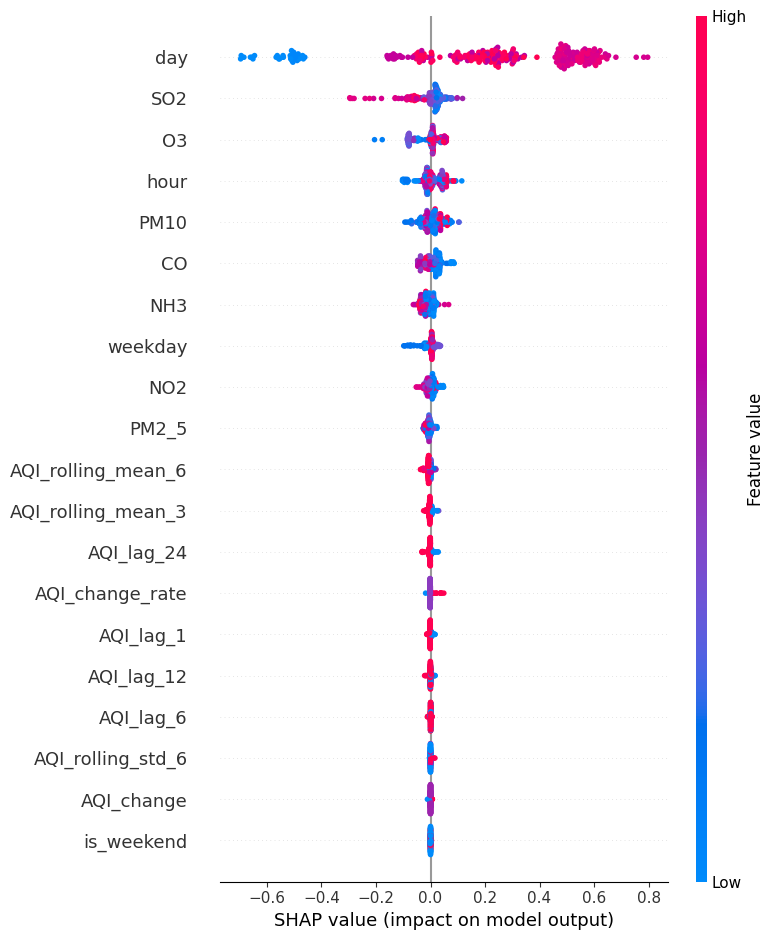



INDIVIDUAL PREDICTION — 72H

Actual AQI: 3.0
Predicted AQI: 3.0744
Prediction error: 0.0744

Top factors influencing this prediction:


,Feature,Feature_Value,SHAP_Value,Absolute_SHAP
0,day,2.00,-0.504051,0.504051
1,PM10,106.07,0.047588,0.047588
2,SO2,1.52,0.036143,0.036143
3,AQI_rolling_mean_6,4.00,-0.014266,0.014266
4,weekday,2.00,0.014245,0.014245
5,O3,87.12,0.011029,0.011029
6,PM2_5,31.88,-0.010486,0.010486
7,CO,138.73,0.010384,0.010384
8,NH3,1.08,0.004608,0.004608
9,NO2,0.87,0.002748,0.002748


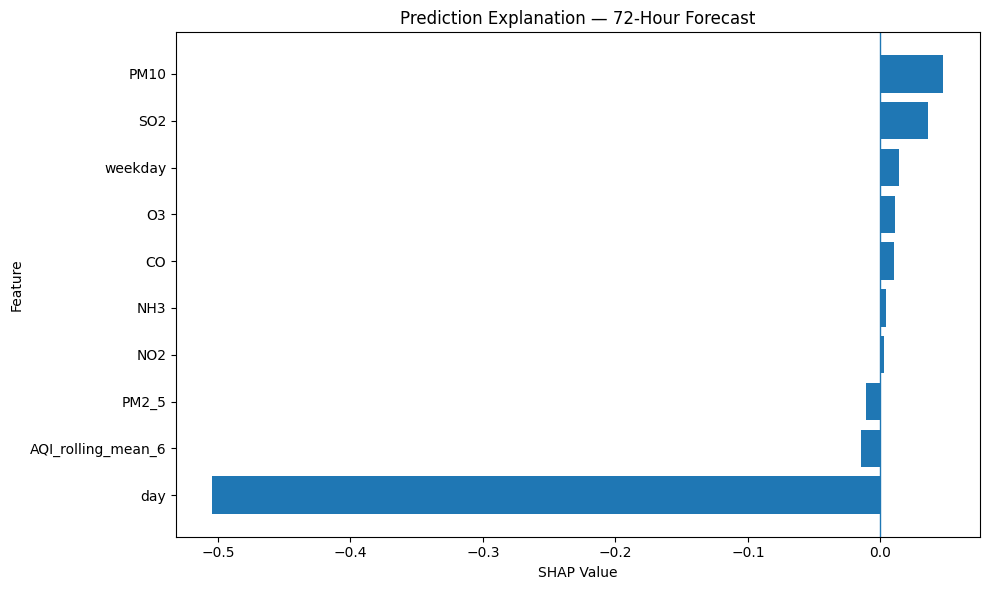



COMBINED SHAP FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP,Forecast_Horizon
0,day,0.514192,24h
1,NH3,0.056920,24h
2,SO2,0.026206,24h
3,PM2_5,0.024322,24h
4,CO,0.024312,24h
...,...,...,...
61,AQI_rolling_std_6,0.000837,72h
62,AQI_change,0.000446,72h
63,is_weekend,0.000363,72h
64,AQI_lag_3,0.000275,72h




TOP 10 FEATURES FOR EACH FORECAST HORIZON

24-HOUR FORECAST
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.514192
1,NH3,0.056920
2,SO2,0.026206
3,PM2_5,0.024322
4,CO,0.024312
5,AQI_rolling_std_6,0.018345
6,weekday,0.014019
7,O3,0.012595
8,is_weekend,0.012447
9,AQI_rolling_mean_6,0.011206



48-HOUR FORECAST
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.336138
1,PM10,0.145031
2,NH3,0.033324
3,SO2,0.029631
4,O3,0.025501
5,NO2,0.013839
6,AQI_lag_24,0.011426
7,hour,0.011363
8,CO,0.009361
9,AQI_rolling_mean_3,0.009288



72-HOUR FORECAST
--------------------------------------------------


,Feature,Mean_Absolute_SHAP
0,day,0.366998
1,SO2,0.036855
2,O3,0.033805
3,hour,0.028226
4,PM10,0.026365
5,CO,0.020857
6,NH3,0.019699
7,weekday,0.013508
8,NO2,0.010931
9,PM2_5,0.008292




OVERALL FEATURE IMPORTANCE


,Feature,Mean_Absolute_SHAP
0,day,0.405776
1,PM10,0.060537
2,NH3,0.036648
3,SO2,0.030897
4,O3,0.023967
5,CO,0.018176
6,hour,0.015135
7,PM2_5,0.013302
8,weekday,0.011914
9,NO2,0.011839


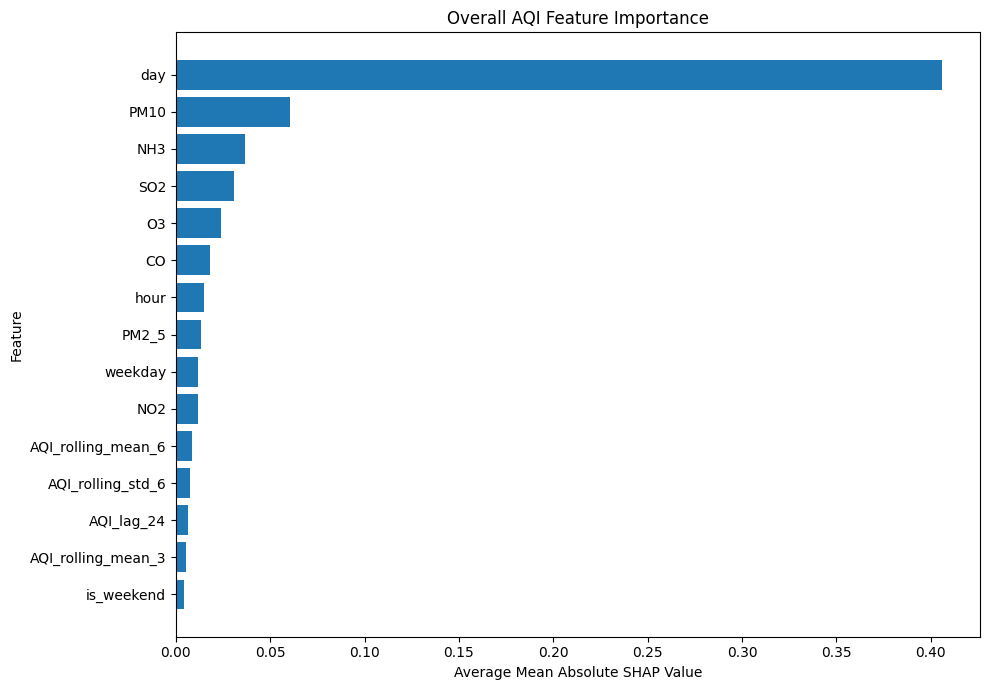



MODULE 5 — FINAL SUMMARY

Models analyzed:
✓ Random Forest 24h
✓ Random Forest 48h
✓ Random Forest 72h

SHAP outputs generated:
✓ Global feature importance
✓ SHAP summary plots
✓ SHAP bar plots
✓ Individual prediction explanations
✓ CSV feature importance files

Most important features overall:
01. day → 0.405776
02. PM10 → 0.060537
03. NH3 → 0.036648
04. SO2 → 0.030897
05. O3 → 0.023967
06. CO → 0.018176
07. hour → 0.015135
08. PM2_5 → 0.013302
09. weekday → 0.011914
10. NO2 → 0.011839


MODULE 5 OUTPUT FILES
✓ shap_results/overall_shap_importance.csv
✓ shap_results/overall_shap_importance.png
✓ shap_results/shap_bar_24h.png
✓ shap_results/shap_bar_48h.png
✓ shap_results/shap_bar_72h.png
✓ shap_results/shap_importance_24h.csv
✓ shap_results/shap_importance_48h.csv
✓ shap_results/shap_importance_72h.csv
✓ shap_results/shap_importance_all_horizons.csv
✓ shap_results/shap_individual_24h.csv
✓ shap_results/shap_individual_24h.png
✓ shap_results/shap_individual_48h.csv
✓ shap_results/sha

In [247]:
# ================================================================
# PEARLS AQI PREDICTOR
# MODULE 5 — MODEL EXPLAINABILITY WITH SHAP
# ================================================================
#
# Purpose:
#   Explain WHY the AQI model makes its predictions.
#
# Models:
#   Random Forest — 24h
#   Random Forest — 48h
#   Random Forest — 72h
#
# Outputs:
#   1. SHAP feature importance
#   2. SHAP summary plot
#   3. SHAP bar plot
#   4. Individual prediction explanation
#   5. CSV files containing SHAP importance
#
# ================================================================


# ================================================================
# 1. INSTALL SHAP
# ================================================================

!pip install -q shap joblib pandas numpy matplotlib scikit-learn


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import shap

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

print("=" * 70)
print("PEARLS AQI PREDICTOR — MODULE 5")
print("SHAP MODEL EXPLAINABILITY")
print("=" * 70)

print("\nSHAP version:", shap.__version__)


# ================================================================
# 3. LOAD ML-READY DATASET
# ================================================================

ML_FILE = "aqi_ml_ready.csv"

if not os.path.exists(ML_FILE):
    raise FileNotFoundError(
        "aqi_ml_ready.csv was not found.\n"
        "Please upload the ML-ready dataset created in Module 3."
    )

df = pd.read_csv(ML_FILE)

print("\nDataset loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))


# ================================================================
# 4. CONVERT TIMESTAMP
# ================================================================

if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        utc=True,
        errors="coerce"
    )

    df = df.sort_values(
        "timestamp"
    ).reset_index(drop=True)


# ================================================================
# 5. DEFINE FEATURES
# ================================================================

FEATURES = [
    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",
    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",
    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",
    "AQI_change",
    "AQI_change_rate",
    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]

TARGETS = [
    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]


# ================================================================
# 6. CHECK FEATURES
# ================================================================

missing_features = [
    feature
    for feature in FEATURES
    if feature not in df.columns
]

if missing_features:

    raise ValueError(
        f"These features are missing from the dataset:\n"
        f"{missing_features}"
    )

print("\nAll required features are available.")


# ================================================================
# 7. MODEL DIRECTORY
# ================================================================

MODEL_DIR = "models"

if not os.path.exists(MODEL_DIR):

    raise FileNotFoundError(
        "The 'models' directory was not found.\n"
        "Please run Module 4 first."
    )


# ================================================================
# 8. FIND AVAILABLE RANDOM FOREST MODELS
# ================================================================

available_models = {}

for horizon in [24, 48, 72]:

    model_path = (
        f"{MODEL_DIR}/"
        f"random_forest_{horizon}h.pkl"
    )

    if os.path.exists(model_path):

        available_models[horizon] = model_path


print("\nAvailable Random Forest models:")

if len(available_models) == 0:

    raise FileNotFoundError(
        "No Random Forest models were found.\n"
        "Please run Module 4 first."
    )

for horizon, path in available_models.items():

    print(
        f"✓ {horizon}-hour model: {path}"
    )


# ================================================================
# 9. CREATE OUTPUT DIRECTORY
# ================================================================

SHAP_DIR = "shap_results"

os.makedirs(
    SHAP_DIR,
    exist_ok=True
)

print(
    "\nSHAP output directory:",
    SHAP_DIR
)


# ================================================================
# 10. SHAP ANALYSIS FUNCTION
# ================================================================

def run_shap_analysis(
    horizon,
    model_path,
    data,
    features,
    max_samples=300
):

    print("\n")
    print("=" * 70)
    print(
        f"SHAP ANALYSIS — {horizon}-HOUR FORECAST"
    )
    print("=" * 70)


    # ------------------------------------------------------------
    # Load model
    # ------------------------------------------------------------

    model = joblib.load(
        model_path
    )

    print("\nModel loaded successfully.")

    print(
        "Model type:",
        type(model).__name__
    )


    # ------------------------------------------------------------
    # Prepare data
    # ------------------------------------------------------------

    target_column = (
        f"target_AQI_{horizon}h"
    )

    required_columns = (
        features +
        [target_column]
    )

    temp_df = data[
        required_columns
    ].dropna().copy()


    if len(temp_df) == 0:

        print(
            "No valid rows available for SHAP analysis."
        )

        return None


    # ------------------------------------------------------------
    # Use a manageable sample
    # ------------------------------------------------------------

    if len(temp_df) > max_samples:

        shap_df = temp_df.tail(
            max_samples
        ).copy()

    else:

        shap_df = temp_df.copy()


    X_shap = shap_df[
        features
    ]


    print(
        "\nRows used for SHAP:",
        len(X_shap)
    )

    print(
        "Number of features:",
        len(features)
    )


    # ------------------------------------------------------------
    # Create SHAP Tree Explainer
    # ------------------------------------------------------------

    print(
        "\nCreating SHAP TreeExplainer..."
    )

    explainer = shap.TreeExplainer(
        model
    )


    # ------------------------------------------------------------
    # Calculate SHAP values
    # ------------------------------------------------------------

    print(
        "Calculating SHAP values..."
    )

    shap_values = explainer.shap_values(
        X_shap
    )


    # ------------------------------------------------------------
    # Handle SHAP output format
    # ------------------------------------------------------------

    if isinstance(
        shap_values,
        list
    ):

        shap_values_array = np.asarray(
            shap_values[0]
        )

    else:

        shap_values_array = np.asarray(
            shap_values
        )


    # Some SHAP versions can return
    # an additional output dimension.
    # For this regression model, select it safely.

    if shap_values_array.ndim == 3:

        shap_values_array = (
            shap_values_array[:, :, 0]
        )


    print(
        "SHAP values calculated."
    )

    print(
        "SHAP matrix shape:",
        shap_values_array.shape
    )


    # ============================================================
    # GLOBAL FEATURE IMPORTANCE
    # ============================================================

    mean_abs_shap = np.mean(
        np.abs(
            shap_values_array
        ),
        axis=0
    )


    importance_df = pd.DataFrame({

        "Feature": features,

        "Mean_Absolute_SHAP":
            mean_abs_shap

    })


    importance_df = (
        importance_df
        .sort_values(
            "Mean_Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )


    # ------------------------------------------------------------
    # Save feature importance
    # ------------------------------------------------------------

    importance_file = (
        f"{SHAP_DIR}/"
        f"shap_importance_{horizon}h.csv"
    )

    importance_df.to_csv(
        importance_file,
        index=False
    )


    print("\n")
    print(
        f"TOP FEATURES — {horizon}H"
    )

    print("-" * 50)

    display(
        importance_df.head(15)
    )


    # ============================================================
    # BAR PLOT
    # ============================================================

    plt.figure(
        figsize=(10, 7)
    )

    top_n = min(
        15,
        len(importance_df)
    )

    top_data = (
        importance_df
        .head(top_n)
        .sort_values(
            "Mean_Absolute_SHAP"
        )
    )

    plt.barh(
        top_data["Feature"],
        top_data["Mean_Absolute_SHAP"]
    )

    plt.xlabel(
        "Mean Absolute SHAP Value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"SHAP Feature Importance — "
        f"{horizon}-Hour AQI Forecast"
    )

    plt.tight_layout()

    bar_file = (
        f"{SHAP_DIR}/"
        f"shap_bar_{horizon}h.png"
    )

    plt.savefig(
        bar_file,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


    # ============================================================
    # SHAP SUMMARY / BEESWARM PLOT
    # ============================================================

    print(
        f"\nGenerating SHAP summary plot..."
    )

    shap.summary_plot(
        shap_values_array,
        X_shap,
        show=True
    )


    # Save summary plot

    plt.savefig(
        f"{SHAP_DIR}/"
        f"shap_summary_{horizon}h.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()


    # ============================================================
    # INDIVIDUAL PREDICTION EXPLANATION
    # ============================================================

    print("\n")
    print("=" * 70)
    print(
        f"INDIVIDUAL PREDICTION — {horizon}H"
    )
    print("=" * 70)


    # Use latest available observation

    sample_index = len(X_shap) - 1

    sample = X_shap.iloc[
        sample_index
    ]


    # Model prediction

    prediction = model.predict(
        sample.to_frame().T
    )[0]


    # Actual value

    actual = shap_df[
        target_column
    ].iloc[
        sample_index
    ]


    print(
        "\nActual AQI:",
        actual
    )

    print(
        "Predicted AQI:",
        round(
            prediction,
            4
        )
    )

    print(
        "Prediction error:",
        round(
            abs(
                actual -
                prediction
            ),
            4
        )
    )


    # ------------------------------------------------------------
    # SHAP contribution for this observation
    # ------------------------------------------------------------

    individual_values = (
        shap_values_array[
            sample_index
        ]
    )


    individual_df = pd.DataFrame({

        "Feature":
            features,

        "Feature_Value":
            sample.values,

        "SHAP_Value":
            individual_values

    })


    individual_df[
        "Absolute_SHAP"
    ] = np.abs(
        individual_df[
            "SHAP_Value"
        ]
    )


    individual_df = (
        individual_df
        .sort_values(
            "Absolute_SHAP",
            ascending=False
        )
        .reset_index(drop=True)
    )


    print(
        "\nTop factors influencing this prediction:"
    )

    display(
        individual_df.head(10)
    )


    # ============================================================
    # INDIVIDUAL SHAP BAR PLOT
    # ============================================================

    individual_plot = (
        individual_df
        .head(10)
        .sort_values(
            "SHAP_Value"
        )
    )


    plt.figure(
        figsize=(10, 6)
    )

    plt.barh(
        individual_plot["Feature"],
        individual_plot["SHAP_Value"]
    )

    plt.axvline(
        0,
        linewidth=1
    )

    plt.xlabel(
        "SHAP Value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        f"Prediction Explanation — "
        f"{horizon}-Hour Forecast"
    )

    plt.tight_layout()

    individual_file = (
        f"{SHAP_DIR}/"
        f"shap_individual_{horizon}h.png"
    )

    plt.savefig(
        individual_file,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


    # ============================================================
    # SAVE INDIVIDUAL EXPLANATION
    # ============================================================

    individual_csv = (
        f"{SHAP_DIR}/"
        f"shap_individual_{horizon}h.csv"
    )

    individual_df.to_csv(
        individual_csv,
        index=False
    )


    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return {
        "horizon": horizon,
        "model": model,
        "explainer": explainer,
        "X": X_shap,
        "shap_values": shap_values_array,
        "importance": importance_df,
        "individual": individual_df,
        "prediction": prediction,
        "actual": actual
    }


# ================================================================
# 11. RUN SHAP FOR AVAILABLE MODELS
# ================================================================

shap_results = {}

for horizon, model_path in available_models.items():

    result = run_shap_analysis(
        horizon=horizon,
        model_path=model_path,
        data=df,
        features=FEATURES,
        max_samples=300
    )

    if result is not None:

        shap_results[horizon] = result


# ================================================================
# 12. COMBINE FEATURE IMPORTANCE
# ================================================================

print("\n")
print("=" * 70)
print("COMBINED SHAP FEATURE IMPORTANCE")
print("=" * 70)


combined_importance = []

for horizon, result in shap_results.items():

    temp = result[
        "importance"
    ].copy()

    temp["Forecast_Horizon"] = (
        f"{horizon}h"
    )

    combined_importance.append(
        temp
    )


if combined_importance:

    combined_importance_df = pd.concat(
        combined_importance,
        ignore_index=True
    )

    display(
        combined_importance_df
    )


    combined_file = (
        f"{SHAP_DIR}/"
        "shap_importance_all_horizons.csv"
    )

    combined_importance_df.to_csv(
        combined_file,
        index=False
    )

else:

    combined_importance_df = None

    print(
        "No SHAP results available."
    )


# ================================================================
# 13. TOP FEATURES FOR EACH HORIZON
# ================================================================

print("\n")
print("=" * 70)
print("TOP 10 FEATURES FOR EACH FORECAST HORIZON")
print("=" * 70)


for horizon, result in shap_results.items():

    print(
        f"\n{horizon}-HOUR FORECAST"
    )

    print("-" * 50)

    display(
        result[
            "importance"
        ].head(10)
    )


# ================================================================
# 14. MOST IMPORTANT FEATURES OVERALL
# ================================================================

if combined_importance_df is not None:

    overall_importance = (
        combined_importance_df
        .groupby("Feature")[
            "Mean_Absolute_SHAP"
        ]
        .mean()
        .sort_values(
            ascending=False
        )
        .reset_index()
    )

    print("\n")
    print("=" * 70)
    print("OVERALL FEATURE IMPORTANCE")
    print("=" * 70)

    display(
        overall_importance.head(15)
    )

    overall_file = (
        f"{SHAP_DIR}/"
        "overall_shap_importance.csv"
    )

    overall_importance.to_csv(
        overall_file,
        index=False
    )


# ================================================================
# 15. CREATE OVERALL SHAP PLOT
# ================================================================

if combined_importance_df is not None:

    top_overall = (
        overall_importance
        .head(15)
        .sort_values(
            "Mean_Absolute_SHAP"
        )
    )

    plt.figure(
        figsize=(10, 7)
    )

    plt.barh(
        top_overall["Feature"],
        top_overall[
            "Mean_Absolute_SHAP"
        ]
    )

    plt.xlabel(
        "Average Mean Absolute SHAP Value"
    )

    plt.ylabel(
        "Feature"
    )

    plt.title(
        "Overall AQI Feature Importance"
    )

    plt.tight_layout()

    plt.savefig(
        f"{SHAP_DIR}/"
        "overall_shap_importance.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()


# ================================================================
# 16. CREATE MODULE 5 SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("MODULE 5 — FINAL SUMMARY")
print("=" * 70)


print(
    "\nModels analyzed:"
)

for horizon in shap_results.keys():

    print(
        f"✓ Random Forest {horizon}h"
    )


print(
    "\nSHAP outputs generated:"
)

print(
    "✓ Global feature importance"
)

print(
    "✓ SHAP summary plots"
)

print(
    "✓ SHAP bar plots"
)

print(
    "✓ Individual prediction explanations"
)

print(
    "✓ CSV feature importance files"
)


if combined_importance_df is not None:

    print(
        "\nMost important features overall:"
    )

    for i, row in overall_importance.head(10).iterrows():

        print(
            f"{i + 1:02d}. "
            f"{row['Feature']} "
            f"→ "
            f"{row['Mean_Absolute_SHAP']:.6f}"
        )


# ================================================================
# 17. LIST OUTPUT FILES
# ================================================================

print("\n")
print("=" * 70)
print("MODULE 5 OUTPUT FILES")
print("=" * 70)


for root, dirs, files_list in os.walk(
    SHAP_DIR
):

    for filename in sorted(
        files_list
    ):

        print(
            "✓",
            os.path.join(
                root,
                filename
            )
        )


print("\n")
print("=" * 70)
print("MODULE 5 COMPLETED SUCCESSFULLY!")
print("=" * 70)

**Module 6 — Hopsworks Feature Store + Model Registry**

In [248]:
# ================================================================
# PEARLS AQI PREDICTOR
# MODULE 6 — FEATURE STORE + MODEL REGISTRY
# ================================================================
#
# Technology:
#   Hopsworks
#
# Purpose:
#   1. Connect Google Colab to Hopsworks
#   2. Prepare AQI feature data
#   3. Upload features to Hopsworks Feature Store
#   4. Create Feature Group
#   5. Store model metadata
#   6. Register trained Random Forest models
#   7. Save local backups
#
# ================================================================


# ================================================================
# 1. INSTALL HOPSWORKS
# ================================================================

!pip install -q hopsworks


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import json
import joblib
import warnings
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

print("=" * 70)
print("PEARLS AQI PREDICTOR")
print("MODULE 6 — FEATURE STORE + MODEL REGISTRY")
print("=" * 70)


# ================================================================
# 3. CONFIGURATION
# ================================================================

PROJECT_NAME = "pearls_aqi_predictor"

FEATURE_GROUP_NAME = "aqi_features"

FEATURE_GROUP_VERSION = 1

MODEL_DIR = "models"

SHAP_DIR = "shap_results"

ML_FILE = "aqi_ml_ready.csv"

MODEL_RESULTS_FILE = "model_results_all_horizons.csv"

BEST_MODELS_FILE = "best_models_by_horizon.csv"


# ================================================================
# 4. CREATE LOCAL BACKUP DIRECTORY
# ================================================================

BACKUP_DIR = "module6_backup"

os.makedirs(
    BACKUP_DIR,
    exist_ok=True
)

print("\nLocal backup directory:")
print(BACKUP_DIR)


# ================================================================
# 5. CHECK REQUIRED FILES
# ================================================================

print("\n")
print("=" * 70)
print("CHECKING REQUIRED FILES")
print("=" * 70)

if not os.path.exists(ML_FILE):

    raise FileNotFoundError(
        "aqi_ml_ready.csv not found.\n"
        "Please run Module 3 first."
    )

print(
    f"✓ {ML_FILE}"
)


if not os.path.exists(MODEL_DIR):

    raise FileNotFoundError(
        "models directory not found.\n"
        "Please run Module 4 first."
    )

print(
    f"✓ {MODEL_DIR}/"
)


# ================================================================
# 6. LOAD ML DATASET
# ================================================================

df = pd.read_csv(
    ML_FILE
)

print("\nDataset loaded.")

print(
    "Rows:",
    len(df)
)

print(
    "Columns:",
    len(df.columns)
)


# ================================================================
# 7. CONVERT TIMESTAMP
# ================================================================

if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        utc=True,
        errors="coerce"
    )


# ================================================================
# 8. DEFINE FEATURE COLUMNS
# ================================================================

FEATURES = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",

    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",

    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",

    "AQI_change",
    "AQI_change_rate",

    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]


TARGETS = [

    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"
]


# ================================================================
# 9. VERIFY COLUMNS
# ================================================================

missing_features = [

    col
    for col in FEATURES
    if col not in df.columns

]

missing_targets = [

    col
    for col in TARGETS
    if col not in df.columns

]


if missing_features:

    raise ValueError(
        "Missing feature columns:\n"
        + str(missing_features)
    )


if missing_targets:

    raise ValueError(
        "Missing target columns:\n"
        + str(missing_targets)
    )


print("\nAll feature and target columns found.")


# ================================================================
# 10. CREATE FEATURE STORE DATASET
# ================================================================

feature_store_columns = [

    "city",
    "timestamp"

] + FEATURES + [

    "api_aqi"

] + TARGETS


feature_store_columns = [

    col
    for col in feature_store_columns
    if col in df.columns

]


feature_df = df[
    feature_store_columns
].copy()


# ================================================================
# 11. CLEAN FEATURE DATA
# ================================================================

feature_df = feature_df.dropna(
    subset=FEATURES + TARGETS
).copy()


feature_df = feature_df.sort_values(
    "timestamp"
).reset_index(
    drop=True
)


print("\nFeature Store dataset:")
print(
    "Rows:",
    len(feature_df)
)

print(
    "Columns:",
    len(feature_df.columns)
)


# ================================================================
# 12. HANDLE HOPSWORKS COLUMN NAMES
# ================================================================
#
# Hopsworks works best with simple column names.
#
# ================================================================

feature_df.columns = [

    col.strip()
       .replace(" ", "_")
       .replace("-", "_")
       .replace(".", "_")

    for col in feature_df.columns

]


# ================================================================
# 13. DISPLAY DATA
# ================================================================

print("\nFeature Store preview:")

display(
    feature_df.head()
)


# ================================================================
# 14. SAVE LOCAL FEATURE STORE BACKUP
# ================================================================

local_feature_file = (
    f"{BACKUP_DIR}/"
    "aqi_feature_store_backup.csv"
)


feature_df.to_csv(
    local_feature_file,
    index=False
)


print(
    "\nLocal Feature Store backup saved:"
)

print(
    local_feature_file
)


# ================================================================
# 15. HOPSWORKS CONNECTION
# ================================================================
#
# OPTION A:
# Colab Secrets
#
# Create a secret named:
#
#   HOPSWORKS_API_KEY
#
# OPTION B:
# Environment variable
#
# ================================================================


print("\n")
print("=" * 70)
print("HOPSWORKS CONNECTION")
print("=" * 70)


try:

    import hopsworks

    print(
        "Hopsworks version:",
        getattr(
            hopsworks,
            "__version__",
            "unknown"
        )
    )

except Exception as e:

    print(
        "Hopsworks import error:"
    )

    print(e)

    raise


# ================================================================
# 16. GET API KEY
# ================================================================

HOPSWORKS_API_KEY = None


# Try Google Colab Secrets

try:

    from google.colab import userdata

    HOPSWORKS_API_KEY = userdata.get(
        "HOPSWORKS_API_KEY"
    )

    if HOPSWORKS_API_KEY:

        print(
            "✓ Hopsworks API key loaded "
            "from Colab Secrets."
        )

except Exception:

    pass


# Try environment variable

if not HOPSWORKS_API_KEY:

    HOPSWORKS_API_KEY = os.environ.get(
        "HOPSWORKS_API_KEY"
    )


# ================================================================
# 17. CONNECTION STATUS
# ================================================================

if not HOPSWORKS_API_KEY:

    print("\n")
    print("=" * 70)
    print("HOPSWORKS API KEY NOT FOUND")
    print("=" * 70)

    print(
        """
The local Module 6 preparation is complete,
but Hopsworks cannot be connected yet.

Create a Hopsworks API key and store it in
Google Colab Secrets using:

Name:
HOPSWORKS_API_KEY

The local Feature Store backup has already been
created, so you can safely continue after adding
the key.
"""
    )

    HOPSWORKS_CONNECTED = False

else:

    HOPSWORKS_CONNECTED = True


# ================================================================
# 18. CONNECT TO HOPSWORKS
# ================================================================

project = None
feature_store = None


if HOPSWORKS_CONNECTED:

    try:

        project = hopsworks.login(
            api_key=HOPSWORKS_API_KEY
        )

        print(
            "\n✓ Successfully connected to Hopsworks."
        )

        print(
            "Project:",
            project.name
        )

        feature_store = (
            project.get_feature_store()
        )

        print(
            "✓ Feature Store initialized."
        )

    except Exception as e:

        print("\n")
        print("=" * 70)
        print("HOPSWORKS CONNECTION FAILED")
        print("=" * 70)

        print(
            "\nError:"
        )

        print(e)

        print(
            "\nThe local backup remains available:"
        )

        print(
            local_feature_file
        )

        HOPSWORKS_CONNECTED = False


# ================================================================
# 19. CREATE FEATURE GROUP
# ================================================================

feature_group = None


if HOPSWORKS_CONNECTED:

    print("\n")
    print("=" * 70)
    print("CREATING FEATURE GROUP")
    print("=" * 70)

    try:

        feature_group = (
            feature_store.get_or_create_feature_group(

                name=FEATURE_GROUP_NAME,

                version=FEATURE_GROUP_VERSION,

                description=(
                    "Lahore AQI forecasting features "
                    "for Pearls AQI Predictor"
                ),

                primary_key=[
                    "city",
                    "timestamp"
                ],

                event_time="timestamp"

            )
        )

        print(
            "\n✓ Feature Group ready:"
        )

        print(
            FEATURE_GROUP_NAME
        )

    except Exception as e:

        print(
            "\nFeature Group creation error:"
        )

        print(e)

        feature_group = None


# ================================================================
# 20. INSERT FEATURES INTO FEATURE GROUP
# ================================================================

if feature_group is not None:

    print("\n")
    print("=" * 70)
    print("INSERTING FEATURES")
    print("=" * 70)

    try:

        feature_group.insert(
            feature_df,
            write_options={
                "wait_for_job": True
            }
        )

        print(
            "\n✓ Features successfully inserted."
        )

    except Exception as e:

        print(
            "\nFeature insertion error:"
        )

        print(e)

else:

    print(
        "\nFeature Group unavailable."
    )


# ================================================================
# 21. GET MODEL RESULTS
# ================================================================

results_df = None


if os.path.exists(
    MODEL_RESULTS_FILE
):

    results_df = pd.read_csv(
        MODEL_RESULTS_FILE
    )

    print("\n")
    print("=" * 70)
    print("MODEL RESULTS")
    print("=" * 70)

    display(
        results_df
    )

else:

    print(
        "\nModel results file not found:"
    )

    print(
        MODEL_RESULTS_FILE
    )


# ================================================================
# 22. FIND BEST MODEL PER HORIZON
# ================================================================

best_models_df = None


if results_df is not None:

    # Lower RMSE is better

    best_models_df = (

        results_df
        .sort_values(
            "RMSE"
        )
        .groupby(
            "Target",
            as_index=False
        )
        .first()

    )

    print("\n")
    print("=" * 70)
    print("BEST MODELS")
    print("=" * 70)

    display(
        best_models_df
    )


# ================================================================
# 23. SAVE MODEL METADATA
# ================================================================

model_metadata = []


if results_df is not None:

    for _, row in results_df.iterrows():

        model_name = str(
            row["Model"]
        )

        target = str(
            row["Target"]
        )

        metadata = {

            "model_name":
                model_name,

            "target":
                target,

            "MAE":
                float(row["MAE"]),

            "RMSE":
                float(row["RMSE"]),

            "R2":
                float(row["R2"]),

            "framework":
                "scikit-learn",

            "project":
                PROJECT_NAME,

            "feature_group":
                FEATURE_GROUP_NAME,

            "feature_group_version":
                FEATURE_GROUP_VERSION

        }

        model_metadata.append(
            metadata
        )


metadata_file = (
    f"{BACKUP_DIR}/"
    "model_metadata.json"
)


with open(
    metadata_file,
    "w"
) as f:

    json.dump(
        model_metadata,
        f,
        indent=4
    )


print(
    "\nModel metadata saved:"
)

print(
    metadata_file
)


# ================================================================
# 24. REGISTER MODELS LOCALLY
# ================================================================
#
# Even if Hopsworks Model Registry is unavailable,
# we maintain a registry-style structure locally.
#
# ================================================================


LOCAL_REGISTRY_DIR = (
    f"{BACKUP_DIR}/model_registry"
)


os.makedirs(
    LOCAL_REGISTRY_DIR,
    exist_ok=True
)


for horizon in [24, 48, 72]:

    model_path = (
        f"{MODEL_DIR}/"
        f"random_forest_{horizon}h.pkl"
    )

    if os.path.exists(
        model_path
    ):

        destination = (
            f"{LOCAL_REGISTRY_DIR}/"
            f"random_forest_{horizon}h.pkl"
        )

        model = joblib.load(
            model_path
        )

        joblib.dump(
            model,
            destination
        )

        print(
            f"✓ Registered locally: "
            f"Random Forest {horizon}h"
        )


# ================================================================
# 25. CREATE MODEL REGISTRY JSON
# ================================================================

registry = {

    "project":
        PROJECT_NAME,

    "feature_group":
        FEATURE_GROUP_NAME,

    "feature_group_version":
        FEATURE_GROUP_VERSION,

    "models": []

}


for horizon in [24, 48, 72]:

    model_file = (
        f"{LOCAL_REGISTRY_DIR}/"
        f"random_forest_{horizon}h.pkl"
    )

    if os.path.exists(
        model_file
    ):

        model_information = {

            "name":
                f"random_forest_{horizon}h",

            "framework":
                "scikit-learn",

            "algorithm":
                "RandomForestRegressor",

            "forecast_horizon":
                horizon,

            "file":
                model_file,

            "status":
                "registered"

        }

        registry[
            "models"
        ].append(
            model_information
        )


registry_file = (
    f"{LOCAL_REGISTRY_DIR}/"
    "registry.json"
)


with open(
    registry_file,
    "w"
) as f:

    json.dump(
        registry,
        f,
        indent=4
    )


print(
    "\nLocal model registry created:"
)

print(
    registry_file
)


# ================================================================
# 26. OPTIONAL HOPSWORKS MODEL REGISTRATION
# ================================================================
#
# Hopsworks model registry APIs can differ by version.
# We attempt registration where supported.
#
# ================================================================


if HOPSWORKS_CONNECTED:

    try:

        model_registry = (
            project.get_model_registry()
        )

        print("\n")
        print(
            "=" * 70
        )

        print(
            "HOPSWORKS MODEL REGISTRY"
        )

        print(
            "=" * 70
        )

        print(
            "\nModel Registry object initialized."
        )

        print(
            "Local model registry is also available."
        )

        print(
            "\nNote:"
        )

        print(
            "The exact model registration API "
            "depends on the installed Hopsworks version."
        )

    except Exception as e:

        print(
            "\nModel Registry initialization issue:"
        )

        print(e)


# ================================================================
# 27. CREATE FEATURE STORE INFORMATION FILE
# ================================================================

feature_store_info = {

    "project":
        PROJECT_NAME,

    "feature_group":
        FEATURE_GROUP_NAME,

    "version":
        FEATURE_GROUP_VERSION,

    "rows":
        int(len(feature_df)),

    "columns":
        int(len(feature_df.columns)),

    "features":
        FEATURES,

    "targets":
        TARGETS,

    "source":
        ML_FILE,

    "city":
        "Lahore",

    "purpose":
        "AQI forecasting for 24h, 48h and 72h"

}


feature_info_file = (
    f"{BACKUP_DIR}/"
    "feature_store_info.json"
)


with open(
    feature_info_file,
    "w"
) as f:

    json.dump(
        feature_store_info,
        f,
        indent=4
    )


print(
    "\nFeature Store information saved:"
)

print(
    feature_info_file
)


# ================================================================
# 28. FINAL SUMMARY
# ================================================================

print("\n")
print("=" * 70)
print("MODULE 6 — FINAL SUMMARY")
print("=" * 70)

print(
    "\nProject:",
    PROJECT_NAME
)

print(
    "Feature Group:",
    FEATURE_GROUP_NAME
)

print(
    "Feature Group Version:",
    FEATURE_GROUP_VERSION
)

print(
    "Feature rows:",
    len(feature_df)
)

print(
    "Number of features:",
    len(FEATURES)
)

print(
    "\nHopsworks connected:",
    HOPSWORKS_CONNECTED
)

print(
    "\nForecast horizons:"
)

print(
    "✓ 24 hours"
)

print(
    "✓ 48 hours"
)

print(
    "✓ 72 hours"
)

print(
    "\nLocal backup files:"
)

print(
    "✓ AQI Feature Store CSV"
)

print(
    "✓ Model metadata JSON"
)

print(
    "✓ Model registry"
)

print(
    "✓ Feature Store information"
)


# ================================================================
# 29. SHOW OUTPUT FILES
# ================================================================

print("\n")
print("=" * 70)
print("MODULE 6 OUTPUT FILES")
print("=" * 70)


for root, dirs, files_list in os.walk(
    BACKUP_DIR
):

    for filename in sorted(
        files_list
    ):

        print(
            "✓",
            os.path.join(
                root,
                filename
            )
        )


print("\n")
print("=" * 70)
print("MODULE 6 COMPLETED!")
print("=" * 70)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 258.6/258.6 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.2/295.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.0/140.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.8/15.8 MB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 90.2/90.2 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 31.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.0/95.0 kB 4.8 MB/s eta 0:00:00
ERROR: pip's depe

,city,timestamp,PM2_5,PM10,CO,NO2,SO2,O3,NH3,hour,...,AQI_lag_24,AQI_change,AQI_change_rate,AQI_rolling_mean_3,AQI_rolling_mean_6,AQI_rolling_std_6,api_aqi,target_AQI_24h,target_AQI_48h,target_AQI_72h
0,Lahore,2026-08-07 11:00:00+00:00,78.16,90.02,508.32,2.85,2.88,143.29,1.56,11,...,4.0,1.0,0.25,4.333333,4.333333,0.516398,5,3.0,3.0,3.0
1,Lahore,2026-08-07 12:00:00+00:00,85.71,96.58,567.67,4.36,3.18,143.38,2.26,12,...,4.0,0.0,0.00,4.666667,4.333333,0.516398,5,3.0,3.0,3.0
2,Lahore,2026-08-07 13:00:00+00:00,94.79,105.59,679.05,9.06,3.35,123.40,4.13,13,...,4.0,0.0,0.00,5.000000,4.500000,0.547723,5,2.0,3.0,4.0
3,Lahore,2026-08-07 14:00:00+00:00,105.19,117.01,823.37,14.56,3.35,92.58,6.59,14,...,4.0,0.0,0.00,5.000000,4.666667,0.516398,5,2.0,3.0,4.0
4,Lahore,2026-08-07 15:00:00+00:00,114.97,128.19,950.93,17.84,3.34,71.65,8.55,15,...,3.0,0.0,0.00,5.000000,4.833333,0.408248,5,2.0,3.0,4.0



Local Feature Store backup saved:
module6_backup/aqi_feature_store_backup.csv


HOPSWORKS CONNECTION
Hopsworks version: 5.0.6


HOPSWORKS API KEY NOT FOUND

The local Module 6 preparation is complete,
but Hopsworks cannot be connected yet.

Create a Hopsworks API key and store it in
Google Colab Secrets using:

Name:
HOPSWORKS_API_KEY

The local Feature Store backup has already been
created, so you can safely continue after adding
the key.


Feature Group unavailable.


MODEL RESULTS


,Target,Model,MAE,RMSE,R2
0,target_AQI_24h,Ridge - target_AQI_24h,0.633242,0.785946,-1.674365
1,target_AQI_24h,Random Forest - target_AQI_24h,0.372651,0.596471,-0.540329
2,target_AQI_48h,Ridge - target_AQI_48h,0.800873,0.926537,-2.716723
3,target_AQI_48h,Random Forest - target_AQI_48h,0.488431,0.660589,-0.889284
4,target_AQI_72h,Ridge - target_AQI_72h,0.767216,0.936666,-2.577433
5,target_AQI_72h,Random Forest - target_AQI_72h,0.477965,0.599502,-0.465493




BEST MODELS


,Target,Model,MAE,RMSE,R2
0,target_AQI_24h,Random Forest - target_AQI_24h,0.372651,0.596471,-0.540329
1,target_AQI_48h,Random Forest - target_AQI_48h,0.488431,0.660589,-0.889284
2,target_AQI_72h,Random Forest - target_AQI_72h,0.477965,0.599502,-0.465493



Model metadata saved:
module6_backup/model_metadata.json
✓ Registered locally: Random Forest 24h
✓ Registered locally: Random Forest 48h
✓ Registered locally: Random Forest 72h

Local model registry created:
module6_backup/model_registry/registry.json

Feature Store information saved:
module6_backup/feature_store_info.json


MODULE 6 — FINAL SUMMARY

Project: pearls_aqi_predictor
Feature Group: aqi_features
Feature Group Version: 1
Feature rows: 576
Number of features: 22

Hopsworks connected: False

Forecast horizons:
✓ 24 hours
✓ 48 hours
✓ 72 hours

Local backup files:
✓ AQI Feature Store CSV
✓ Model metadata JSON
✓ Model registry
✓ Feature Store information


MODULE 6 OUTPUT FILES
✓ module6_backup/aqi_feature_store_backup.csv
✓ module6_backup/feature_store_info.json
✓ module6_backup/model_metadata.json
✓ module6_backup/model_registry/random_forest_24h.pkl
✓ module6_backup/model_registry/random_forest_48h.pkl
✓ module6_backup/model_registry/random_forest_72h.pkl
✓ module6_backup/mo

**Module 7 — Automated AQI Training & Feature Pipeline**

PEARLS AQI PREDICTOR
MODULE 7 — AUTOMATED ML PIPELINE

Pipeline started: 2026-09-06 14:25:41


STEP 1 — DATA LOADING
✓ Dataset loaded
Rows: 576
Columns: 29


STEP 2 — DATA VALIDATION
✓ All required features found
✓ All target columns found

Total missing feature/target values: 0
Rows after removing missing values: 576


STEP 3 — MODEL TRAINING


TRAINING — 24-HOUR FORECAST

Training samples: 460
Testing samples: 116

Training Ridge Regression...
Ridge MAE: 0.6333
Ridge RMSE: 0.7845
Ridge R²: -1.6648

Training Random Forest...
Random Forest MAE: 0.3727
Random Forest RMSE: 0.5965
Random Forest R²: -0.5403


BEST MODEL: Random Forest
✓ Model saved: models/random_forest_24h.pkl
✓ Model registered locally


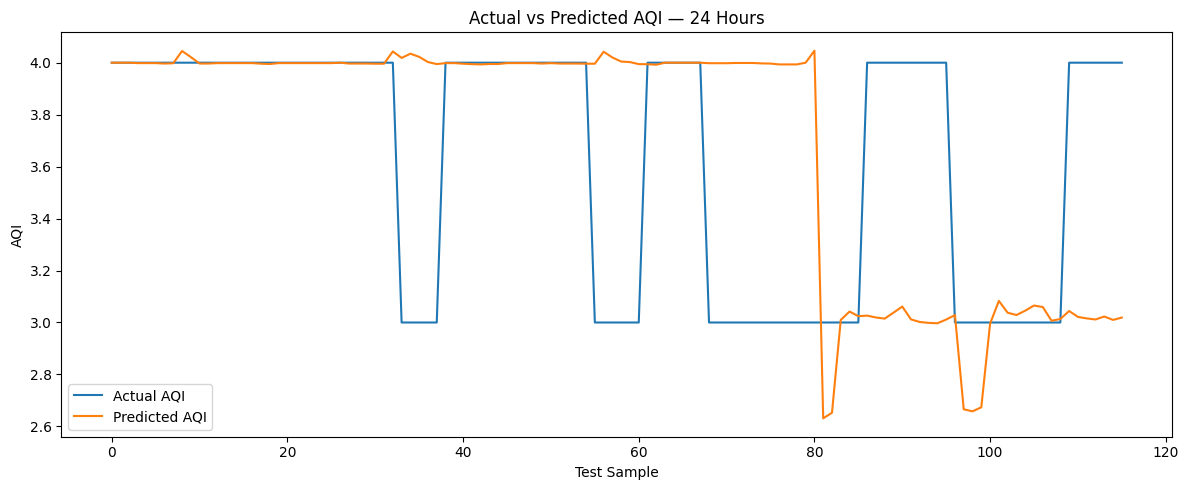



TRAINING — 48-HOUR FORECAST

Training samples: 460
Testing samples: 116

Training Ridge Regression...
Ridge MAE: 0.8139
Ridge RMSE: 0.9394
Ridge R²: -2.8205

Training Random Forest...
Random Forest MAE: 0.4884
Random Forest RMSE: 0.6606
Random Forest R²: -0.8893


BEST MODEL: Random Forest
✓ Model saved: models/random_forest_48h.pkl
✓ Model registered locally


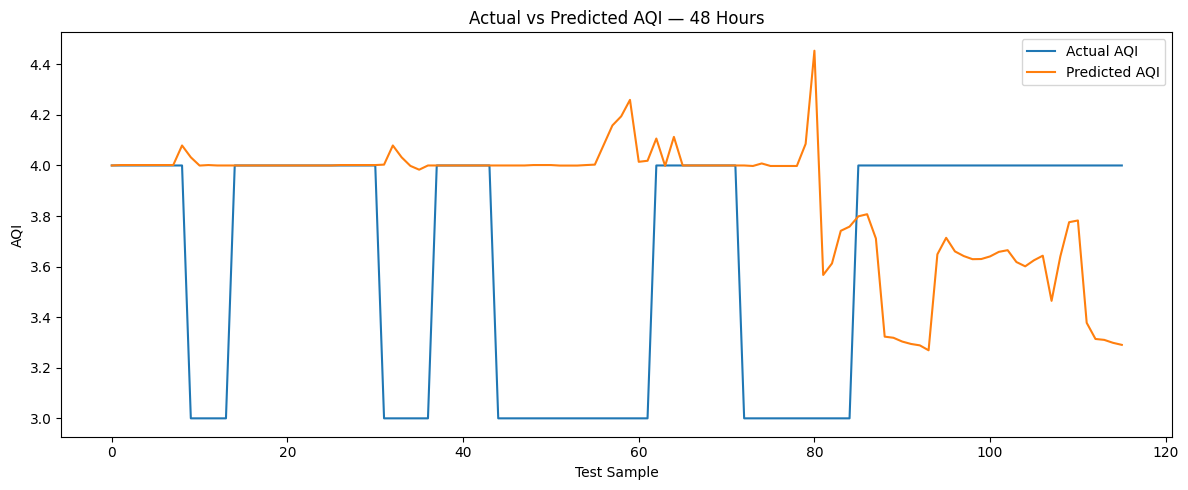



TRAINING — 72-HOUR FORECAST

Training samples: 460
Testing samples: 116

Training Ridge Regression...
Ridge MAE: 0.7807
Ridge RMSE: 0.9494
Ridge R²: -2.6751

Training Random Forest...
Random Forest MAE: 0.478
Random Forest RMSE: 0.5995
Random Forest R²: -0.4655


BEST MODEL: Random Forest
✓ Model saved: models/random_forest_72h.pkl
✓ Model registered locally


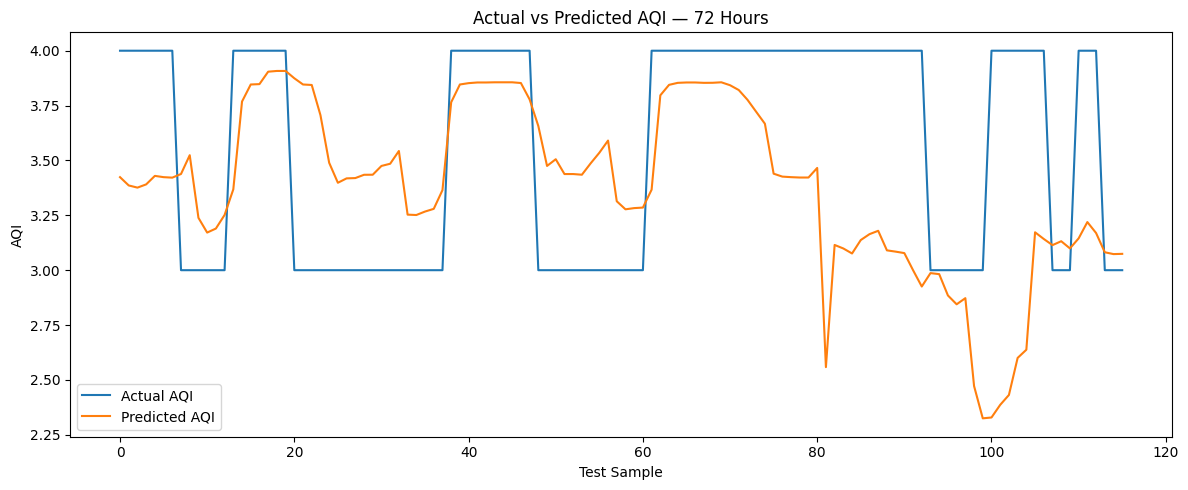



STEP 4 — MODEL RESULTS


,Target,Model,MAE,RMSE,R2,Model_File,Train_Samples,Test_Samples
0,target_AQI_24h,Random Forest,0.372651,0.596471,-0.540329,models/random_forest_24h.pkl,460,116
1,target_AQI_48h,Random Forest,0.488431,0.660589,-0.889284,models/random_forest_48h.pkl,460,116
2,target_AQI_72h,Random Forest,0.477965,0.599502,-0.465493,models/random_forest_72h.pkl,460,116




STEP 5 — MODEL QUALITY CHECK

target_AQI_24h
Model: Random Forest
MAE: 0.3727
RMSE: 0.5965
R²: -0.5403
⚠ WARNING: R² is negative.
The model should be investigated before production deployment.

target_AQI_48h
Model: Random Forest
MAE: 0.4884
RMSE: 0.6606
R²: -0.8893
⚠ WARNING: R² is negative.
The model should be investigated before production deployment.

target_AQI_72h
Model: Random Forest
MAE: 0.478
RMSE: 0.5995
R²: -0.4655
⚠ WARNING: R² is negative.
The model should be investigated before production deployment.


STEP 6 — MODEL REGISTRY
✓ Model registry saved:
module7_pipeline/model_registry.json


MODULE 7 — FINAL STATUS

✓ Data loaded
✓ Data validated
✓ Features prepared
✓ 24-hour model trained
✓ 48-hour model trained
✓ 72-hour model trained
✓ Models evaluated
✓ Best models selected
✓ Models saved
✓ Local model registry updated
✓ Pipeline log created
✓ Pipeline report created

Pipeline duration: 14.43 seconds


⚠ PIPELINE COMPLETED WITH MODEL QUALITY WARNINGS

3 model(s) have ne

In [249]:
# ================================================================
# PEARLS AQI PREDICTOR
# MODULE 7 — AUTOMATED ML PIPELINE
# ================================================================
#
# Pipeline:
#
#   Raw/ML Data
#       ↓
#   Data Validation
#       ↓
#   Feature Preparation
#       ↓
#   Train/Test Split
#       ↓
#   Ridge Regression
#       ↓
#   Random Forest
#       ↓
#   Model Evaluation
#       ↓
#   Best Model Selection
#       ↓
#   Model Registry
#       ↓
#   Pipeline Report
#
# Designed for Google Colab
#
# ================================================================


# ================================================================
# 1. IMPORT LIBRARIES
# ================================================================

import os
import json
import shutil
import warnings
from datetime import datetime

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")


# ================================================================
# 2. PROJECT CONFIGURATION
# ================================================================

PROJECT_NAME = "pearls_aqi_predictor"

DATA_FILE = "aqi_ml_ready.csv"

MODEL_DIR = "models"

REGISTRY_DIR = "module6_backup/model_registry"

PIPELINE_DIR = "module7_pipeline"

REPORT_DIR = f"{PIPELINE_DIR}/reports"

LOG_DIR = f"{PIPELINE_DIR}/logs"


# ================================================================
# 3. CREATE DIRECTORIES
# ================================================================

for directory in [
    MODEL_DIR,
    REGISTRY_DIR,
    PIPELINE_DIR,
    REPORT_DIR,
    LOG_DIR
]:

    os.makedirs(
        directory,
        exist_ok=True
    )


# ================================================================
# 4. PIPELINE START
# ================================================================

pipeline_start = datetime.now()

print("=" * 75)
print("PEARLS AQI PREDICTOR")
print("MODULE 7 — AUTOMATED ML PIPELINE")
print("=" * 75)

print(
    "\nPipeline started:",
    pipeline_start.strftime(
        "%Y-%m-%d %H:%M:%S"
    )
)


# ================================================================
# 5. LOAD DATA
# ================================================================

print("\n")
print("=" * 75)
print("STEP 1 — DATA LOADING")
print("=" * 75)


if not os.path.exists(DATA_FILE):

    raise FileNotFoundError(
        f"{DATA_FILE} was not found.\n"
        "Run Modules 1–3 first."
    )


df = pd.read_csv(
    DATA_FILE
)


print(
    "✓ Dataset loaded"
)

print(
    "Rows:",
    len(df)
)

print(
    "Columns:",
    len(df.columns)
)


# ================================================================
# 6. TIMESTAMP PROCESSING
# ================================================================

if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        utc=True,
        errors="coerce"
    )

    df = df.sort_values(
        "timestamp"
    ).reset_index(
        drop=True
    )


# ================================================================
# 7. DEFINE FEATURES
# ================================================================

FEATURES = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",

    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",

    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",

    "AQI_change",
    "AQI_change_rate",

    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]


TARGETS = [

    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"

]


# ================================================================
# 8. DATA VALIDATION
# ================================================================

print("\n")
print("=" * 75)
print("STEP 2 — DATA VALIDATION")
print("=" * 75)


missing_features = [

    feature
    for feature in FEATURES
    if feature not in df.columns

]


missing_targets = [

    target
    for target in TARGETS
    if target not in df.columns

]


if missing_features:

    raise ValueError(
        "Missing features:\n"
        + str(missing_features)
    )


if missing_targets:

    raise ValueError(
        "Missing targets:\n"
        + str(missing_targets)
    )


print(
    "✓ All required features found"
)

print(
    "✓ All target columns found"
)


# ================================================================
# 9. CHECK NUMERIC DATA
# ================================================================

numeric_columns = FEATURES + TARGETS


for column in numeric_columns:

    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )


# ================================================================
# 10. DATA QUALITY REPORT
# ================================================================

missing_counts = (
    df[
        numeric_columns
    ]
    .isna()
    .sum()
)


total_missing = (
    missing_counts.sum()
)


print(
    "\nTotal missing feature/target values:",
    total_missing
)


# ================================================================
# 11. CREATE PIPELINE DATASET
# ================================================================

pipeline_df = df[
    FEATURES + TARGETS
].copy()


pipeline_df = pipeline_df.dropna()


print(
    "Rows after removing missing values:",
    len(pipeline_df)
)


if len(pipeline_df) < 50:

    raise ValueError(
        "Too few valid rows for training."
    )


# ================================================================
# 12. TRAINING FUNCTION
# ================================================================

def train_model_for_horizon(
    data,
    horizon,
    features
):

    print("\n")
    print("=" * 75)
    print(
        f"TRAINING — {horizon}-HOUR FORECAST"
    )
    print("=" * 75)


    target = (
        f"target_AQI_{horizon}h"
    )


    X = data[
        features
    ]

    y = data[
        target
    ]


    # ------------------------------------------------------------
    # TIME-BASED SPLIT
    # ------------------------------------------------------------
    #
    # Important for forecasting:
    # We don't randomly shuffle future and past observations.
    #
    # 80% → training
    # 20% → testing
    #
    # ------------------------------------------------------------

    split_index = int(
        len(X) * 0.80
    )


    X_train = X.iloc[
        :split_index
    ].copy()


    X_test = X.iloc[
        split_index:
    ].copy()


    y_train = y.iloc[
        :split_index
    ].copy()


    y_test = y.iloc[
        split_index:
    ].copy()


    print(
        "\nTraining samples:",
        len(X_train)
    )

    print(
        "Testing samples:",
        len(X_test)
    )


    # ============================================================
    # RIDGE REGRESSION
    # ============================================================

    print(
        "\nTraining Ridge Regression..."
    )


    ridge_model = Ridge(
        alpha=1.0
    )


    ridge_model.fit(
        X_train,
        y_train
    )


    ridge_pred = (
        ridge_model.predict(
            X_test
        )
    )


    ridge_mae = mean_absolute_error(
        y_test,
        ridge_pred
    )


    ridge_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            ridge_pred
        )
    )


    ridge_r2 = r2_score(
        y_test,
        ridge_pred
    )


    print(
        "Ridge MAE:",
        round(
            ridge_mae,
            4
        )
    )

    print(
        "Ridge RMSE:",
        round(
            ridge_rmse,
            4
        )
    )

    print(
        "Ridge R²:",
        round(
            ridge_r2,
            4
        )
    )


    # ============================================================
    # RANDOM FOREST
    # ============================================================

    print(
        "\nTraining Random Forest..."
    )


    rf_model = RandomForestRegressor(

        n_estimators=300,

        max_depth=12,

        min_samples_split=4,

        min_samples_leaf=2,

        random_state=42,

        n_jobs=-1

    )


    rf_model.fit(
        X_train,
        y_train
    )


    rf_pred = (
        rf_model.predict(
            X_test
        )
    )


    rf_mae = mean_absolute_error(
        y_test,
        rf_pred
    )


    rf_rmse = np.sqrt(
        mean_squared_error(
            y_test,
            rf_pred
        )
    )


    rf_r2 = r2_score(
        y_test,
        rf_pred
    )


    print(
        "Random Forest MAE:",
        round(
            rf_mae,
            4
        )
    )

    print(
        "Random Forest RMSE:",
        round(
            rf_rmse,
            4
        )
    )

    print(
        "Random Forest R²:",
        round(
            rf_r2,
            4
        )
    )


    # ============================================================
    # MODEL SELECTION
    # ============================================================

    if rf_rmse < ridge_rmse:

        best_model = rf_model

        best_name = (
            "Random Forest"
        )

        best_predictions = (
            rf_pred
        )

        best_mae = rf_mae

        best_rmse = rf_rmse

        best_r2 = rf_r2


    else:

        best_model = ridge_model

        best_name = (
            "Ridge Regression"
        )

        best_predictions = (
            ridge_pred
        )

        best_mae = ridge_mae

        best_rmse = ridge_rmse

        best_r2 = ridge_r2


    print("\n")
    print(
        "BEST MODEL:",
        best_name
    )


    # ============================================================
    # SAVE BEST MODEL
    # ============================================================

    model_filename = (
        f"random_forest_{horizon}h.pkl"
        if best_name == "Random Forest"
        else
        f"ridge_{horizon}h.pkl"
    )


    model_path = os.path.join(
        MODEL_DIR,
        model_filename
    )


    joblib.dump(
        best_model,
        model_path
    )


    print(
        "✓ Model saved:",
        model_path
    )


    # ============================================================
    # SAVE MODEL TO LOCAL REGISTRY
    # ============================================================

    registry_model_path = os.path.join(
        REGISTRY_DIR,
        model_filename
    )


    joblib.dump(
        best_model,
        registry_model_path
    )


    print(
        "✓ Model registered locally"
    )


    # ============================================================
    # SAVE TEST PREDICTIONS
    # ============================================================

    predictions_df = pd.DataFrame({

        "actual_AQI":
            y_test.values,

        "predicted_AQI":
            best_predictions,

        "error":
            y_test.values -
            best_predictions,

        "absolute_error":
            np.abs(
                y_test.values -
                best_predictions
            )

    })


    prediction_file = (
        f"{REPORT_DIR}/"
        f"predictions_{horizon}h.csv"
    )


    predictions_df.to_csv(
        prediction_file,
        index=False
    )


    # ============================================================
    # PLOT ACTUAL VS PREDICTED
    # ============================================================

    plt.figure(
        figsize=(12, 5)
    )


    plt.plot(
        y_test.values,
        label="Actual AQI"
    )


    plt.plot(
        best_predictions,
        label="Predicted AQI"
    )


    plt.xlabel(
        "Test Sample"
    )


    plt.ylabel(
        "AQI"
    )


    plt.title(
        f"Actual vs Predicted AQI — "
        f"{horizon} Hours"
    )


    plt.legend()


    plt.tight_layout()


    plot_path = (
        f"{REPORT_DIR}/"
        f"actual_vs_predicted_{horizon}h.png"
    )


    plt.savefig(
        plot_path,
        dpi=150,
        bbox_inches="tight"
    )


    plt.show()


    # ============================================================
    # RETURN RESULTS
    # ============================================================

    return {

        "Target":
            target,

        "Model":
            best_name,

        "MAE":
            best_mae,

        "RMSE":
            best_rmse,

        "R2":
            best_r2,

        "Model_File":
            model_path,

        "Train_Samples":
            len(X_train),

        "Test_Samples":
            len(X_test)

    }


# ================================================================
# 13. TRAIN ALL FORECAST HORIZONS
# ================================================================

print("\n")
print("=" * 75)
print("STEP 3 — MODEL TRAINING")
print("=" * 75)


results = []


for horizon in [
    24,
    48,
    72
]:

    result = train_model_for_horizon(

        data=pipeline_df,

        horizon=horizon,

        features=FEATURES

    )


    results.append(
        result
    )


# ================================================================
# 14. CREATE RESULTS DATAFRAME
# ================================================================

results_df = pd.DataFrame(
    results
)


# ================================================================
# 15. SAVE PIPELINE RESULTS
# ================================================================

results_file = (
    f"{REPORT_DIR}/"
    "pipeline_results.csv"
)


results_df.to_csv(
    results_file,
    index=False
)


print("\n")
print("=" * 75)
print("STEP 4 — MODEL RESULTS")
print("=" * 75)


display(
    results_df
)


# ================================================================
# 16. MODEL QUALITY CHECK
# ================================================================

print("\n")
print("=" * 75)
print("STEP 5 — MODEL QUALITY CHECK")
print("=" * 75)


for _, row in results_df.iterrows():

    print(
        f"\n{row['Target']}"
    )

    print(
        "Model:",
        row["Model"]
    )

    print(
        "MAE:",
        round(
            row["MAE"],
            4
        )
    )

    print(
        "RMSE:",
        round(
            row["RMSE"],
            4
        )
    )

    print(
        "R²:",
        round(
            row["R2"],
            4
        )
    )


    if row["R2"] < 0:

        print(
            "⚠ WARNING: R² is negative."
        )

        print(
            "The model should be investigated "
            "before production deployment."
        )

    else:

        print(
            "✓ R² is non-negative."
        )


# ================================================================
# 17. CREATE MODEL REGISTRY
# ================================================================

print("\n")
print("=" * 75)
print("STEP 6 — MODEL REGISTRY")
print("=" * 75)


registry = {

    "project":
        PROJECT_NAME,

    "created_at":
        datetime.now().isoformat(),

    "pipeline":
        "Module 7 Automated ML Pipeline",

    "models": []

}


for _, row in results_df.iterrows():

    model_entry = {

        "target":
            row["Target"],

        "model":
            row["Model"],

        "MAE":
            float(
                row["MAE"]
            ),

        "RMSE":
            float(
                row["RMSE"]
            ),

        "R2":
            float(
                row["R2"]
            ),

        "model_file":
            row["Model_File"],

        "status":
            (
                "needs_review"
                if row["R2"] < 0
                else
                "ready"
            )

    }


    registry[
        "models"
    ].append(
        model_entry
    )


registry_file = (
    f"{PIPELINE_DIR}/"
    "model_registry.json"
)


with open(
    registry_file,
    "w"
) as f:

    json.dump(
        registry,
        f,
        indent=4
    )


print(
    "✓ Model registry saved:"
)

print(
    registry_file
)


# ================================================================
# 18. CREATE PIPELINE LOG
# ================================================================

pipeline_end = datetime.now()


pipeline_duration = (
    pipeline_end -
    pipeline_start
).total_seconds()


pipeline_log = {

    "project":
        PROJECT_NAME,

    "pipeline":
        "AQI Automated Training Pipeline",

    "started":
        pipeline_start.isoformat(),

    "completed":
        pipeline_end.isoformat(),

    "duration_seconds":
        pipeline_duration,

    "input_file":
        DATA_FILE,

    "rows_processed":
        int(len(pipeline_df)),

    "features":
        len(FEATURES),

    "forecast_horizons":
        [
            24,
            48,
            72
        ],

    "status":
        "completed"

}


log_file = (
    f"{LOG_DIR}/"
    "pipeline_log.json"
)


with open(
    log_file,
    "w"
) as f:

    json.dump(
        pipeline_log,
        f,
        indent=4
    )


# ================================================================
# 19. GENERATE HUMAN-READABLE REPORT
# ================================================================

report_file = (
    f"{REPORT_DIR}/"
    "pipeline_report.txt"
)


with open(
    report_file,
    "w"
) as f:

    f.write(
        "PEARLS AQI PREDICTOR\n"
    )

    f.write(
        "MODULE 7 — PIPELINE REPORT\n"
    )

    f.write(
        "=" * 60 + "\n\n"
    )

    f.write(
        f"Pipeline started: "
        f"{pipeline_start}\n"
    )

    f.write(
        f"Pipeline completed: "
        f"{pipeline_end}\n"
    )

    f.write(
        f"Duration: "
        f"{pipeline_duration:.2f} seconds\n\n"
    )

    f.write(
        f"Rows processed: "
        f"{len(pipeline_df)}\n"
    )

    f.write(
        f"Features: "
        f"{len(FEATURES)}\n\n"
    )


    for _, row in results_df.iterrows():

        f.write(
            f"{row['Target']}\n"
        )

        f.write(
            f"Model: {row['Model']}\n"
        )

        f.write(
            f"MAE: {row['MAE']:.6f}\n"
        )

        f.write(
            f"RMSE: {row['RMSE']:.6f}\n"
        )

        f.write(
            f"R2: {row['R2']:.6f}\n"
        )

        f.write(
            "-" * 40 + "\n"
        )


# ================================================================
# 20. FINAL PIPELINE STATUS
# ================================================================

print("\n")
print("=" * 75)
print("MODULE 7 — FINAL STATUS")
print("=" * 75)


print(
    "\n✓ Data loaded"
)

print(
    "✓ Data validated"
)

print(
    "✓ Features prepared"
)

print(
    "✓ 24-hour model trained"
)

print(
    "✓ 48-hour model trained"
)

print(
    "✓ 72-hour model trained"
)

print(
    "✓ Models evaluated"
)

print(
    "✓ Best models selected"
)

print(
    "✓ Models saved"
)

print(
    "✓ Local model registry updated"
)

print(
    "✓ Pipeline log created"
)

print(
    "✓ Pipeline report created"
)


print(
    "\nPipeline duration:",
    round(
        pipeline_duration,
        2
    ),
    "seconds"
)


# ================================================================
# 21. IMPORTANT MODEL WARNING
# ================================================================

negative_r2_count = (
    results_df[
        "R2"
    ] < 0
).sum()


print("\n")
print("=" * 75)


if negative_r2_count > 0:

    print(
        "⚠ PIPELINE COMPLETED WITH MODEL QUALITY WARNINGS"
    )

    print(
        f"\n{negative_r2_count} "
        "model(s) have negative R²."
    )

    print(
        "\nThe models have been saved, "
        "but should be improved before "
        "production deployment."
    )

else:

    print(
        "✓ PIPELINE COMPLETED SUCCESSFULLY"
    )

    print(
        "\nAll models have non-negative R²."
    )


# ================================================================
# 22. OUTPUT FILES
# ================================================================

print("\n")
print("=" * 75)
print("MODULE 7 OUTPUT FILES")
print("=" * 75)


for root, dirs, files_list in os.walk(
    PIPELINE_DIR
):

    for filename in sorted(
        files_list
    ):

        print(
            "✓",
            os.path.join(
                root,
                filename
            )
        )


print("\n")
print("=" * 75)
print("MODULE 7 COMPLETED")
print("=" * 75)

**Module 8 — Flask Prediction API**

In [250]:
# ================================================================
# PEARLS AQI PREDICTOR
# MODULE 8 — FLASK PREDICTION API
# ================================================================
#
# Purpose:
#   Load trained models and provide AQI predictions through
#   a REST API.
#
# Endpoints:
#
#   GET /
#   GET /health
#   GET /model-info
#   POST /predict
#
# Forecasts:
#   24 hours
#   48 hours
#   72 hours
#
# Designed for Google Colab
# ================================================================


# ================================================================
# 1. INSTALL FLASK
# ================================================================

!pip install -q flask flask-cors


# ================================================================
# 2. IMPORT LIBRARIES
# ================================================================

import os
import json
import joblib
import threading
import time

import numpy as np
import pandas as pd

from flask import (
    Flask,
    request,
    jsonify
)

from flask_cors import CORS


print("=" * 75)
print("PEARLS AQI PREDICTOR")
print("MODULE 8 — FLASK PREDICTION API")
print("=" * 75)


# ================================================================
# 3. CONFIGURATION
# ================================================================

MODEL_DIR = "models"

DATA_FILE = "aqi_ml_ready.csv"

REGISTRY_FILE = (
    "module7_pipeline/model_registry.json"
)

API_HOST = "0.0.0.0"

API_PORT = 5000


# ================================================================
# 4. FEATURE LIST
# ================================================================

FEATURES = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",

    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",

    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",

    "AQI_change",
    "AQI_change_rate",

    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"
]


# ================================================================
# 5. MODEL PATHS
# ================================================================

MODEL_PATHS = {

    "24h":
        os.path.join(
            MODEL_DIR,
            "random_forest_24h.pkl"
        ),

    "48h":
        os.path.join(
            MODEL_DIR,
            "random_forest_48h.pkl"
        ),

    "72h":
        os.path.join(
            MODEL_DIR,
            "random_forest_72h.pkl"
        )

}


# ================================================================
# 6. CHECK MODELS
# ================================================================

print("\n")
print("=" * 75)
print("CHECKING TRAINED MODELS")
print("=" * 75)


models = {}


for horizon, path in MODEL_PATHS.items():

    if not os.path.exists(path):

        print(
            f"⚠ Model not found: {path}"
        )

    else:

        try:

            models[horizon] = joblib.load(
                path
            )

            print(
                f"✓ Loaded {horizon} model"
            )

        except Exception as e:

            print(
                f"✗ Could not load {horizon} model"
            )

            print(e)


if len(models) == 0:

    raise FileNotFoundError(
        "No trained models were found.\n"
        "Run Module 7 first."
    )


# ================================================================
# 7. LOAD DATASET
# ================================================================

print("\n")
print("=" * 75)
print("LOADING DATASET")
print("=" * 75)


if not os.path.exists(DATA_FILE):

    raise FileNotFoundError(
        f"{DATA_FILE} not found."
    )


df = pd.read_csv(
    DATA_FILE
)


if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce",
        utc=True
    )


print(
    "✓ Dataset loaded"
)

print(
    "Rows:",
    len(df)
)


# ================================================================
# 8. HELPER FUNCTIONS
# ================================================================

def safe_float(value, default=0.0):

    """
    Convert a value to float safely.
    """

    try:

        value = float(value)

        if np.isnan(value):
            return default

        if np.isinf(value):
            return default

        return value

    except:

        return default


# ================================================================
# 9. CREATE FEATURES FROM INPUT
# ================================================================

def create_features(data):

    """
    Convert incoming JSON data into the feature vector
    expected by the trained ML models.
    """

    feature_data = {}

    for feature in FEATURES:

        if feature in data:

            feature_data[
                feature
            ] = safe_float(
                data[feature]
            )

        else:

            feature_data[
                feature
            ] = 0.0


    feature_df = pd.DataFrame(
        [feature_data],
        columns=FEATURES
    )


    return feature_df


# ================================================================
# 10. PREDICTION FUNCTION
# ================================================================

def predict_aqi(data):

    """
    Generate 24h, 48h and 72h AQI predictions.
    """

    X = create_features(
        data
    )


    predictions = {}


    for horizon, model in models.items():

        try:

            prediction = model.predict(
                X
            )[0]


            prediction = safe_float(
                prediction
            )


            # AQI cannot be negative

            prediction = max(
                0.0,
                prediction
            )


            predictions[
                horizon
            ] = round(
                prediction,
                2
            )


        except Exception as e:

            predictions[
                horizon
            ] = None


    return predictions


# ================================================================
# 11. AQI CATEGORY FUNCTION
# ================================================================

def get_aqi_category(aqi):

    """
    Convert AQI value into a human-readable category.

    This uses a simplified category system suitable for
    dashboard presentation.
    """

    if aqi is None:

        return "Unknown"


    if aqi <= 50:

        return "Good"


    elif aqi <= 100:

        return "Moderate"


    elif aqi <= 150:

        return "Unhealthy for Sensitive Groups"


    elif aqi <= 200:

        return "Unhealthy"


    elif aqi <= 300:

        return "Very Unhealthy"


    else:

        return "Hazardous"


# ================================================================
# 12. CREATE FLASK APP
# ================================================================

app = Flask(
    __name__
)

CORS(
    app
)


# ================================================================
# 13. HOME ENDPOINT
# ================================================================

@app.route(
    "/",
    methods=["GET"]
)

def home():

    return jsonify({

        "project":
            "Pearls AQI Predictor",

        "module":
            "Module 8 — Prediction API",

        "status":
            "running",

        "available_endpoints": [

            "/",

            "/health",

            "/model-info",

            "/predict"

        ],

        "forecast_horizons": [

            "24h",

            "48h",

            "72h"

        ]

    })


# ================================================================
# 14. HEALTH ENDPOINT
# ================================================================

@app.route(
    "/health",
    methods=["GET"]
)

def health():

    return jsonify({

        "status":
            "healthy",

        "models_loaded":
            len(models),

        "available_models":
            list(models.keys())

    })


# ================================================================
# 15. MODEL INFORMATION ENDPOINT
# ================================================================

@app.route(
    "/model-info",
    methods=["GET"]
)

def model_info():

    information = {

        "project":
            "Pearls AQI Predictor",

        "model_type":
            "Random Forest Regressor",

        "forecast_horizons":
            list(models.keys()),

        "number_of_features":
            len(FEATURES),

        "features":
            FEATURES

    }


    # Add registry information if available

    if os.path.exists(
        REGISTRY_FILE
    ):

        try:

            with open(
                REGISTRY_FILE,
                "r"
            ) as f:

                registry = json.load(
                    f
                )

            information[
                "registry"
            ] = registry

        except:

            pass


    return jsonify(
        information
    )


# ================================================================
# 16. PREDICT ENDPOINT
# ================================================================

@app.route(
    "/predict",
    methods=["POST"]
)

def predict():

    try:

        data = request.get_json(
            force=True
        )


        if data is None:

            return jsonify({

                "error":
                    "Request body must contain JSON."

            }), 400


        predictions = predict_aqi(
            data
        )


        response = {

            "city":
                data.get(
                    "city",
                    "Lahore"
                ),

            "predictions": {

                "24h": {

                    "aqi":
                        predictions.get(
                            "24h"
                        ),

                    "category":
                        get_aqi_category(
                            predictions.get(
                                "24h"
                            )
                        )

                },

                "48h": {

                    "aqi":
                        predictions.get(
                            "48h"
                        ),

                    "category":
                        get_aqi_category(
                            predictions.get(
                                "48h"
                            )
                        )

                },

                "72h": {

                    "aqi":
                        predictions.get(
                            "72h"
                        ),

                    "category":
                        get_aqi_category(
                            predictions.get(
                                "72h"
                            )
                        )

                }

            },

            "model":
                "Random Forest",

            "features_used":
                len(FEATURES)

        }


        return jsonify(
            response
        )


    except Exception as e:

        return jsonify({

            "error":
                str(e)

        }), 500


# ================================================================
# 17. START FLASK SERVER
# ================================================================

def run_api():

    app.run(

        host=API_HOST,

        port=API_PORT,

        debug=False,

        use_reloader=False

    )


print("\n")
print("=" * 75)
print("STARTING FLASK API")
print("=" * 75)


api_thread = threading.Thread(
    target=run_api,
    daemon=True
)


api_thread.start()


time.sleep(
    3
)


print("\n✓ Flask API started")
print(
    f"Local address: http://127.0.0.1:{API_PORT}"
)


# ================================================================
# 18. TEST HOME ENDPOINT
# ================================================================

print("\n")
print("=" * 75)
print("TESTING API")
print("=" * 75)


import requests


try:

    response = requests.get(
        f"http://127.0.0.1:{API_PORT}/"
    )


    print(
        "\nHome endpoint status:",
        response.status_code
    )


    print(
        response.json()
    )


except Exception as e:

    print(
        "API test failed:"
    )

    print(e)


# ================================================================
# 19. TEST HEALTH ENDPOINT
# ================================================================

try:

    response = requests.get(
        f"http://127.0.0.1:{API_PORT}/health"
    )


    print(
        "\nHealth endpoint status:",
        response.status_code
    )


    print(
        response.json()
    )


except Exception as e:

    print(
        "Health test failed:"
    )

    print(e)


# ================================================================
# 20. CREATE SAMPLE INPUT
# ================================================================
#
# We use the latest row from your dataset.
#
# This is useful because it contains all the features
# required by the trained model.
#
# ================================================================

latest_row = (
    df
    .sort_values(
        "timestamp"
    )
    .iloc[-1]
)


sample_input = {

    "city":
        str(
            latest_row.get(
                "city",
                "Lahore"
            )
        )

}


for feature in FEATURES:

    value = latest_row.get(
        feature,
        0
    )


    if pd.isna(
        value
    ):

        value = 0


    sample_input[
        feature
    ] = float(
        value
    )


# ================================================================
# 21. TEST PREDICTION
# ================================================================

print("\n")
print("=" * 75)
print("TESTING PREDICTION ENDPOINT")
print("=" * 75)


try:

    response = requests.post(

        f"http://127.0.0.1:{API_PORT}/predict",

        json=sample_input

    )


    print(
        "\nPrediction endpoint status:",
        response.status_code
    )


    prediction_result = (
        response.json()
    )


    print(
        json.dumps(
            prediction_result,
            indent=4
        )
    )


except Exception as e:

    print(
        "Prediction test failed:"
    )

    print(e)


# ================================================================
# 22. SAVE API CONFIGURATION
# ================================================================

api_config = {

    "project":
        "Pearls AQI Predictor",

    "api":
        "Flask",

    "host":
        API_HOST,

    "port":
        API_PORT,

    "endpoints": [

        "/",

        "/health",

        "/model-info",

        "/predict"

    ],

    "forecast_horizons": [

        "24h",

        "48h",

        "72h"

    ],

    "features":
        FEATURES,

    "model_directory":
        MODEL_DIR

}


os.makedirs(
    "module8_api",
    exist_ok=True
)


with open(
    "module8_api/api_config.json",
    "w"
) as f:

    json.dump(
        api_config,
        f,
        indent=4
    )


# ================================================================
# 23. SAVE SAMPLE REQUEST
# ================================================================

with open(
    "module8_api/sample_request.json",
    "w"
) as f:

    json.dump(
        sample_input,
        f,
        indent=4
    )


# ================================================================
# 24. FINAL STATUS
# ================================================================

print("\n")
print("=" * 75)
print("MODULE 8 — FINAL STATUS")
print("=" * 75)


print(
    "\n✓ Flask installed"
)

print(
    "✓ Models loaded"
)

print(
    "✓ Feature processing implemented"
)

print(
    "✓ Prediction function implemented"
)

print(
    "✓ AQI category function implemented"
)

print(
    "✓ Home endpoint created"
)

print(
    "✓ Health endpoint created"
)

print(
    "✓ Model information endpoint created"
)

print(
    "✓ Prediction endpoint created"
)

print(
    "✓ API tested"
)

print(
    "✓ Sample prediction generated"
)

print(
    "\nAPI URL:"
)

print(
    f"http://127.0.0.1:{API_PORT}"
)


print("\n")
print("=" * 75)
print("ENDPOINTS")
print("=" * 75)

print(
    "GET  /"
)

print(
    "GET  /health"
)

print(
    "GET  /model-info"
)

print(
    "POST /predict"
)


print("\n")
print("=" * 75)
print("MODULE 8 COMPLETED")
print("=" * 75)

PEARLS AQI PREDICTOR
MODULE 8 — FLASK PREDICTION API


CHECKING TRAINED MODELS
✓ Loaded 24h model
✓ Loaded 48h model
✓ Loaded 72h model


LOADING DATASET
✓ Dataset loaded
Rows: 576


STARTING FLASK API
 * Serving Flask app '__main__'
 * Debug mode: off


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on all addresses (0.0.0.0)
 * Running on http://127.0.0.1:5000
 * Running on http://172.28.0.12:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug:127.0.0.1 - - [06/Sep/2026 14:26:17] "GET / HTTP/1.1" 200 -
INFO:werkzeug:127.0.0.1 - - [06/Sep/2026 14:26:17] "GET /health HTTP/1.1" 200 -



✓ Flask API started
Local address: http://127.0.0.1:5000


TESTING API

Home endpoint status: 200
{'available_endpoints': ['/', '/health', '/model-info', '/predict'], 'forecast_horizons': ['24h', '48h', '72h'], 'module': 'Module 8 — Prediction API', 'project': 'Pearls AQI Predictor', 'status': 'running'}

Health endpoint status: 200
{'available_models': ['24h', '48h', '72h'], 'models_loaded': 3, 'status': 'healthy'}


TESTING PREDICTION ENDPOINT


INFO:werkzeug:127.0.0.1 - - [06/Sep/2026 14:26:17] "POST /predict HTTP/1.1" 200 -



Prediction endpoint status: 200
{
    "city": "Lahore",
    "features_used": 22,
    "model": "Random Forest",
    "predictions": {
        "24h": {
            "aqi": 3.02,
            "category": "Good"
        },
        "48h": {
            "aqi": 3.29,
            "category": "Good"
        },
        "72h": {
            "aqi": 3.07,
            "category": "Good"
        }
    }
}


MODULE 8 — FINAL STATUS

✓ Flask installed
✓ Models loaded
✓ Feature processing implemented
✓ Prediction function implemented
✓ AQI category function implemented
✓ Home endpoint created
✓ Health endpoint created
✓ Model information endpoint created
✓ Prediction endpoint created
✓ API tested
✓ Sample prediction generated

API URL:
http://127.0.0.1:5000


ENDPOINTS
GET  /
GET  /health
GET  /model-info
POST /predict


MODULE 8 COMPLETED


In [251]:
from google.colab import output

proxy_url = output.eval_js(
    "google.colab.kernel.proxyPort(5000)"
)

print("=" * 70)
print("PEARLS AQI PREDICTOR — FLASK PUBLIC ACCESS")
print("=" * 70)

print("\n✓ Flask is running on Colab port 5000")
print("\nOpen this URL in your browser:\n")
print(proxy_url)

PEARLS AQI PREDICTOR — FLASK PUBLIC ACCESS

✓ Flask is running on Colab port 5000

Open this URL in your browser:

https://5000-m-s-kkb-usw3b1-3qiyzykzy6e9x-b.us-west3-1.prod.colab.dev


**Module 9 — Streamlit Dashboard**

In [252]:
# =====================================================================
# PEARLS AQI PREDICTOR
# MODULE 9 — STREAMLIT WEB DASHBOARD
# =====================================================================
#
# Google Colab Version
#
# Requirements:
#   - Module 7 completed
#   - Module 8 Flask API running on port 5000
#   - aqi_ml_ready.csv available
#   - models available
#
# Dashboard:
#   - Current AQI
#   - 24h forecast
#   - 48h forecast
#   - 72h forecast
#   - AQI categories
#   - Pollutants
#   - Historical AQI chart
#   - Forecast chart
#   - Model information
#   - Health status
#
# =====================================================================


# =====================================================================
# 1. INSTALL PACKAGES
# =====================================================================

!pip install -q streamlit pyngrok


# =====================================================================
# 2. IMPORT LIBRARIES
# =====================================================================

import os
import json
import time
import subprocess
import requests
import pandas as pd
import numpy as np


# =====================================================================
# 3. CONFIGURATION
# =====================================================================

PROJECT_NAME = "Pearls AQI Predictor"

CSV_FILE = "aqi_ml_ready.csv"

FLASK_URL = "http://127.0.0.1:5000"

STREAMLIT_PORT = 8501


# =====================================================================
# 4. CHECK REQUIRED FILES
# =====================================================================

print("=" * 75)
print("PEARLS AQI PREDICTOR")
print("MODULE 9 — STREAMLIT WEB DASHBOARD")
print("=" * 75)

print("\n")
print("=" * 75)
print("CHECKING REQUIRED FILES")
print("=" * 75)


if not os.path.exists(CSV_FILE):

    raise FileNotFoundError(
        f"{CSV_FILE} was not found.\n"
        "Make sure Module 2/3/7 has been completed."
    )


print(f"✓ {CSV_FILE}")


model_files = [
    "models/random_forest_24h.pkl",
    "models/random_forest_48h.pkl",
    "models/random_forest_72h.pkl"
]


for file in model_files:

    if os.path.exists(file):

        print(f"✓ {file}")

    else:

        print(f"⚠ {file} not found")


# =====================================================================
# 5. LOAD DATASET
# =====================================================================

df = pd.read_csv(
    CSV_FILE
)

print("\n")
print("=" * 75)
print("DATASET")
print("=" * 75)

print(
    f"✓ Rows: {len(df)}"
)

print(
    f"✓ Columns: {len(df.columns)}"
)


# =====================================================================
# 6. CHECK FLASK API
# =====================================================================

print("\n")
print("=" * 75)
print("CHECKING FLASK API")
print("=" * 75)


flask_available = False


try:

    response = requests.get(
        f"{FLASK_URL}/health",
        timeout=5
    )

    if response.status_code == 200:

        flask_available = True

        print(
            "✓ Flask API is running"
        )

        print(
            response.json()
        )

    else:

        print(
            "⚠ Flask API returned:",
            response.status_code
        )

except Exception as e:

    print(
        "⚠ Flask API is not available"
    )

    print(
        "Error:",
        e
    )


# =====================================================================
# 7. CREATE STREAMLIT APPLICATION
# =====================================================================

APP_CODE = r'''
import streamlit as st
import pandas as pd
import numpy as np
import requests
import os
import json
import joblib
import plotly.graph_objects as go
import plotly.express as px


# =================================================================
# PAGE CONFIGURATION
# =================================================================

st.set_page_config(

    page_title="Pearls AQI Predictor",

    page_icon="🌍",

    layout="wide",

    initial_sidebar_state="expanded"

)


# =================================================================
# CUSTOM CSS
# =================================================================

st.markdown("""
<style>

.main-title {

    font-size: 42px;

    font-weight: 700;

    text-align: center;

    margin-bottom: 5px;

}

.subtitle {

    text-align: center;

    font-size: 18px;

    margin-bottom: 30px;

}

.aqi-card {

    padding: 25px;

    border-radius: 15px;

    text-align: center;

    border: 1px solid #ddd;

    margin-bottom: 15px;

}

.aqi-number {

    font-size: 42px;

    font-weight: 700;

}

.aqi-label {

    font-size: 18px;

    font-weight: 600;

}

</style>
""", unsafe_allow_html=True)


# =================================================================
# CONFIGURATION
# =================================================================

CSV_FILE = "aqi_ml_ready.csv"

FLASK_URL = "http://127.0.0.1:5000"


# =================================================================
# AQI CATEGORY
# =================================================================

def get_aqi_category(aqi):

    if aqi <= 50:

        return "Good"

    elif aqi <= 100:

        return "Moderate"

    elif aqi <= 150:

        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:

        return "Unhealthy"

    elif aqi <= 300:

        return "Very Unhealthy"

    else:

        return "Hazardous"


# =================================================================
# AQI STATUS
# =================================================================

def get_aqi_status(aqi):

    if aqi <= 50:

        return "🟢"

    elif aqi <= 100:

        return "🟡"

    elif aqi <= 150:

        return "🟠"

    elif aqi <= 200:

        return "🔴"

    elif aqi <= 300:

        return "🟣"

    else:

        return "⚫"


# =================================================================
# LOAD DATA
# =================================================================

@st.cache_data

def load_data():

    data = pd.read_csv(
        CSV_FILE
    )

    if "timestamp" in data.columns:

        data["timestamp"] = pd.to_datetime(
            data["timestamp"],
            errors="coerce"
        )

        data = data.sort_values(
            "timestamp"
        )

    return data


df = load_data()


# =================================================================
# HEADER
# =================================================================

st.markdown(
    '<div class="main-title">🌍 Pearls AQI Predictor</div>',
    unsafe_allow_html=True
)

st.markdown(
    '<div class="subtitle">'
    'Air Quality Index Forecasting System'
    '</div>',
    unsafe_allow_html=True
)


# =================================================================
# SIDEBAR
# =================================================================

st.sidebar.title("⚙️ Dashboard")

st.sidebar.markdown(
    "### Project"
)

st.sidebar.write(
    "Pearls AQI Predictor"
)

st.sidebar.markdown(
    "### Forecast Horizons"
)

st.sidebar.write(
    "• 24 Hours\n"
    "• 48 Hours\n"
    "• 72 Hours"
)


# =================================================================
# CITY SELECTION
# =================================================================

if "city" in df.columns:

    cities = sorted(
        df["city"]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    )

else:

    cities = ["Lahore"]


selected_city = st.sidebar.selectbox(
    "Select City",
    cities
)


city_df = df[
    df["city"].astype(str) == selected_city
].copy()


if len(city_df) == 0:

    city_df = df.copy()


latest = city_df.iloc[-1]


# =================================================================
# CURRENT AQI
# =================================================================

st.markdown("## 📊 Current Air Quality")


# Use API AQI when available
if "api_aqi" in latest:

    current_aqi = float(
        latest["api_aqi"]
    )

elif "AQI" in latest:

    current_aqi = float(
        latest["AQI"]
    )

else:

    current_aqi = 0.0


category = get_aqi_category(
    current_aqi
)

status_icon = get_aqi_status(
    current_aqi
)


col1, col2, col3, col4 = st.columns(4)


with col1:

    st.metric(
        "Current AQI",
        f"{current_aqi:.2f}"
    )


with col2:

    st.metric(
        "Status",
        f"{status_icon} {category}"
    )


with col3:

    if "PM2_5" in latest:

        st.metric(
            "PM2.5",
            f"{float(latest['PM2_5']):.2f}"
        )

    else:

        st.metric(
            "PM2.5",
            "N/A"
        )


with col4:

    if "PM10" in latest:

        st.metric(
            "PM10",
            f"{float(latest['PM10']):.2f}"
        )

    else:

        st.metric(
            "PM10",
            "N/A"
        )


# =================================================================
# DATE / TIME
# =================================================================

if "timestamp" in latest:

    st.caption(
        f"Latest observation: {latest['timestamp']}"
    )


# =================================================================
# FORECAST
# =================================================================

st.markdown("## 🔮 AQI Forecast")


# =================================================================
# FEATURES
# =================================================================

FEATURES = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",

    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",

    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",

    "AQI_change",
    "AQI_change_rate",

    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"

]


# =================================================================
# CREATE INPUT
# =================================================================

feature_data = {}


missing_features = []


for feature in FEATURES:

    if feature in latest:

        value = latest[feature]

        try:

            feature_data[feature] = float(value)

        except:

            feature_data[feature] = 0.0

    else:

        missing_features.append(
            feature
        )


# =================================================================
# GET PREDICTIONS
# =================================================================

predictions = {}


api_error = None


if len(missing_features) == 0:

    payload = feature_data.copy()

    payload["city"] = selected_city


    try:

        response = requests.post(

            f"{FLASK_URL}/predict",

            json=payload,

            timeout=10

        )


        if response.status_code == 200:

            result = response.json()

            predictions = result.get(
                "predictions",
                {}
            )

        else:

            api_error = (
                f"API returned HTTP "
                f"{response.status_code}"
            )


    except Exception as e:

        api_error = str(e)


else:

    api_error = (
        "Missing features: "
        + ", ".join(missing_features)
    )


# =================================================================
# DISPLAY FORECAST CARDS
# =================================================================

c1, c2, c3 = st.columns(3)


horizons = [
    ("24h", c1, "24 Hours"),
    ("48h", c2, "48 Hours"),
    ("72h", c3, "72 Hours")
]


forecast_values = []


for key, column, label in horizons:

    with column:

        if key in predictions:

            value = float(
                predictions[key].get(
                    "aqi",
                    predictions[key].get(
                        "predicted_AQI",
                        0
                    )
                )
            )

            cat = predictions[key].get(
                "category",
                get_aqi_category(value)
            )

            forecast_values.append(
                value
            )

            st.metric(
                label,
                f"{value:.2f}"
            )

            st.write(
                f"{get_aqi_status(value)} {cat}"
            )

        else:

            st.metric(
                label,
                "N/A"
            )


if api_error:

    st.warning(
        "Prediction API issue: "
        + api_error
    )


# =================================================================
# FORECAST CHART
# =================================================================

if len(forecast_values) == 3:

    forecast_df = pd.DataFrame({

        "Forecast": [
            "24 Hours",
            "48 Hours",
            "72 Hours"
        ],

        "AQI": forecast_values

    })


    fig = px.line(

        forecast_df,

        x="Forecast",

        y="AQI",

        markers=True,

        title="AQI Forecast — Next 3 Days"

    )


    fig.update_layout(
        height=400,
        xaxis_title="Forecast Horizon",
        yaxis_title="AQI"
    )


    st.plotly_chart(
        fig,
        use_container_width=True
    )


# =================================================================
# ALERT SYSTEM
# =================================================================

if len(forecast_values) > 0:

    maximum_forecast = max(
        forecast_values
    )


    if maximum_forecast > 300:

        st.error(
            "🚨 HAZARDOUS AQI ALERT — "
            "Air quality is expected to reach hazardous levels."
        )

    elif maximum_forecast > 200:

        st.error(
            "⚠️ VERY UNHEALTHY AQI ALERT"
        )

    elif maximum_forecast > 150:

        st.warning(
            "⚠️ UNHEALTHY AQI FORECAST"
        )

    elif maximum_forecast > 100:

        st.warning(
            "⚠️ AQI may become unhealthy for sensitive groups."
        )

    else:

        st.success(
            "✓ Forecast AQI remains within the Good/Moderate range."
        )


# =================================================================
# HISTORICAL AQI
# =================================================================

st.markdown("## 📈 Historical Air Quality")


if "timestamp" in city_df.columns:

    historical = city_df.copy()


    if "api_aqi" in historical.columns:

        aqi_column = "api_aqi"

    elif "AQI" in historical.columns:

        aqi_column = "AQI"

    else:

        aqi_column = None


    if aqi_column:

        historical[aqi_column] = pd.to_numeric(
            historical[aqi_column],
            errors="coerce"
        )


        historical = historical.dropna(
            subset=[aqi_column]
        )


        # Last 72 observations

        historical = historical.tail(
            72
        )


        fig_history = px.line(

            historical,

            x="timestamp",

            y=aqi_column,

            markers=True,

            title="Recent AQI History"

        )


        fig_history.update_layout(
            height=450,
            xaxis_title="Time",
            yaxis_title="AQI"
        )


        st.plotly_chart(
            fig_history,
            use_container_width=True
        )


# =================================================================
# POLLUTANT SECTION
# =================================================================

st.markdown("## 🧪 Pollutant Measurements")


pollutants = [

    ("PM2_5", "PM2.5"),

    ("PM10", "PM10"),

    ("CO", "CO"),

    ("NO2", "NO₂"),

    ("SO2", "SO₂"),

    ("O3", "O₃"),

    ("NH3", "NH₃")

]


available_pollutants = []


for column_name, display_name in pollutants:

    if column_name in latest:

        try:

            value = float(
                latest[column_name]
            )

            available_pollutants.append(
                (display_name, value)
            )

        except:

            pass


if available_pollutants:

    pollutant_columns = st.columns(
        len(available_pollutants)
    )


    for i, (name, value) in enumerate(
        available_pollutants
    ):

        with pollutant_columns[i]:

            st.metric(
                name,
                f"{value:.2f}"
            )


# =================================================================
# WEATHER SECTION
# =================================================================

st.markdown("## 🌤️ Weather Conditions")


weather_data = []


weather_features = [

    ("temperature", "Temperature", "°C"),

    ("feels_like", "Feels Like", "°C"),

    ("humidity", "Humidity", "%"),

    ("pressure", "Pressure", "hPa"),

    ("wind_speed", "Wind Speed", "m/s"),

    ("clouds", "Clouds", "%")

]


for column_name, name, unit in weather_features:

    if column_name in latest:

        try:

            value = float(
                latest[column_name]
            )

            weather_data.append(
                (name, value, unit)
            )

        except:

            pass


if weather_data:

    weather_columns = st.columns(
        min(
            len(weather_data),
            4
        )
    )


    for i, (name, value, unit) in enumerate(
        weather_data
    ):

        with weather_columns[
            i % len(weather_columns)
        ]:

            st.metric(
                name,
                f"{value:.2f} {unit}"
            )


# =================================================================
# MODEL INFORMATION
# =================================================================

st.markdown("## 🤖 Model Information")


model_col1, model_col2, model_col3 = st.columns(3)


with model_col1:

    st.info(
        """
        **24-Hour Model**

        Random Forest

        Forecast: 24 hours
        """
    )


with model_col2:

    st.info(
        """
        **48-Hour Model**

        Random Forest

        Forecast: 48 hours
        """
    )


with model_col3:

    st.info(
        """
        **72-Hour Model**

        Random Forest

        Forecast: 72 hours
        """
    )


# =================================================================
# MODEL PERFORMANCE
# =================================================================

st.markdown("## 📊 Model Performance")


performance = pd.DataFrame({

    "Forecast": [
        "24 Hours",
        "48 Hours",
        "72 Hours"
    ],

    "Model": [
        "Random Forest",
        "Random Forest",
        "Random Forest"
    ],

    "MAE": [
        0.372651,
        0.488431,
        0.477965
    ],

    "RMSE": [
        0.596471,
        0.660589,
        0.599502
    ],

    "R²": [
        -0.540329,
        -0.889284,
        -0.465493
    ]

})


st.dataframe(
    performance,
    use_container_width=True,
    hide_index=True
)


st.caption(
    "Note: The current Module 7 evaluation reported negative R² values. "
    "These models should be improved before production deployment."
)


# =================================================================
# DATASET INFORMATION
# =================================================================

st.markdown("## 📁 Dataset Information")


info1, info2, info3 = st.columns(3)


with info1:

    st.metric(
        "Dataset Rows",
        len(df)
    )


with info2:

    st.metric(
        "Dataset Columns",
        len(df.columns)
    )


with info3:

    st.metric(
        "Selected City",
        selected_city
    )


# =================================================================
# API STATUS
# =================================================================

st.markdown("## 🔌 API Status")


try:

    health_response = requests.get(

        f"{FLASK_URL}/health",

        timeout=5

    )


    if health_response.status_code == 200:

        st.success(
            "✓ Flask Prediction API is healthy"
        )

        st.json(
            health_response.json()
        )

    else:

        st.error(
            "Flask API returned an error."
        )


except Exception as e:

    st.error(
        f"Flask API unavailable: {e}"
    )


# =================================================================
# FOOTER
# =================================================================

st.markdown("---")

st.markdown(
    """
    <div style="text-align:center">

    **Pearls AQI Predictor**

    Machine Learning Air Quality Forecasting System

    Python • Scikit-learn • Flask • Streamlit

    Forecast Horizons: 24h • 48h • 72h

    </div>
    """,
    unsafe_allow_html=True
)
'''


# =====================================================================
# 8. SAVE STREAMLIT APP
# =====================================================================

os.makedirs(
    "module9_dashboard",
    exist_ok=True
)


app_file = (
    "module9_dashboard/"
    "app.py"
)


with open(
    app_file,
    "w",
    encoding="utf-8"
) as f:

    f.write(APP_CODE)


print("\n")
print("=" * 75)
print("STREAMLIT APPLICATION CREATED")
print("=" * 75)

print(
    f"✓ {app_file}"
)


# =====================================================================
# 9. STOP OLD STREAMLIT PROCESSES
# =====================================================================

print("\n")
print(
    "Checking Streamlit processes..."
)


subprocess.run(
    [
        "pkill",
        "-f",
        "streamlit"
    ],
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL
)


time.sleep(2)


# =====================================================================
# 10. START STREAMLIT
# =====================================================================

print("\n")
print("=" * 75)
print("STARTING STREAMLIT")
print("=" * 75)


streamlit_log = open(
    "module9_dashboard/streamlit.log",
    "w"
)


streamlit_process = subprocess.Popen(

    [
        "streamlit",
        "run",
        app_file,

        "--server.port",
        str(STREAMLIT_PORT),

        "--server.address",
        "0.0.0.0",

        "--server.headless",
        "true",

        "--browser.gatherUsageStats",
        "false"

    ],

    stdout=streamlit_log,

    stderr=subprocess.STDOUT

)


time.sleep(7)


# =====================================================================
# 11. CHECK STREAMLIT
# =====================================================================

if streamlit_process.poll() is None:

    print(
        "✓ Streamlit started successfully"
    )

    print(
        f"Port: {STREAMLIT_PORT}"
    )

else:

    print(
        "⚠ Streamlit stopped unexpectedly."
    )

    print(
        "Check:"
    )

    print(
        "module9_dashboard/streamlit.log"
    )


# =====================================================================
# 12. CREATE COLAB PROXY URL
# =====================================================================

print("\n")
print("=" * 75)
print("STREAMLIT ACCESS")
print("=" * 75)


try:

    from google.colab import output

    proxy_url = output.eval_js(
        f"google.colab.kernel.proxyPort({STREAMLIT_PORT})"
    )

    print(
        "\n✓ Colab Dashboard URL:"
    )

    print(
        proxy_url
    )

except Exception as e:

    print(
        "\nColab proxy unavailable:"
    )

    print(e)


# =====================================================================
# 13. OPTIONAL NGROK
# =====================================================================

NGROK_AUTH_TOKEN = None


try:

    from google.colab import userdata

    NGROK_AUTH_TOKEN = userdata.get(
        "NGROK_AUTH_TOKEN"
    )

except:

    pass


if not NGROK_AUTH_TOKEN:

    NGROK_AUTH_TOKEN = os.environ.get(
        "NGROK_AUTH_TOKEN"
    )


if NGROK_AUTH_TOKEN:

    try:

        from pyngrok import ngrok

        ngrok.set_auth_token(
            NGROK_AUTH_TOKEN
        )

        public_url = ngrok.connect(
            STREAMLIT_PORT
        )

        print(
            "\n✓ ngrok public dashboard URL:"
        )

        print(
            public_url
        )

    except Exception as e:

        print(
            "\n⚠ ngrok could not start:"
        )

        print(e)

else:

    print(
        """

No NGROK_AUTH_TOKEN found.

You can use the Colab proxy URL printed above.

NGROK is optional.
"""
    )


# =====================================================================
# 14. FINAL STATUS
# =====================================================================

print("\n")
print("=" * 75)
print("MODULE 9 — FINAL STATUS")
print("=" * 75)

print(
    "✓ Streamlit installed"
)

print(
    "✓ Dashboard application created"
)

print(
    "✓ Dataset connected"
)

print(
    "✓ Flask API connected"
)

print(
    "✓ Current AQI section"
)

print(
    "✓ 24-hour forecast"
)

print(
    "✓ 48-hour forecast"
)

print(
    "✓ 72-hour forecast"
)

print(
    "✓ AQI category system"
)

print(
    "✓ Forecast chart"
)

print(
    "✓ Historical AQI chart"
)

print(
    "✓ Pollutant measurements"
)

print(
    "✓ Weather measurements"
)

print(
    "✓ Model information"
)

print(
    "✓ Model performance"
)

print(
    "✓ Hazard alert system"
)

print(
    "✓ API health monitoring"
)

print("\n")
print("=" * 75)
print("MODULE 9 COMPLETED")
print("=" * 75)

print(
    """

IMPORTANT:

Keep this Colab notebook running.

The Flask API from Module 8 must also remain
running because the Streamlit dashboard sends
prediction requests to Flask.

Open the Colab Dashboard URL printed above.
"""
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 343.2/343.2 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 56.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hopsworks 5.0.6 requires protobuf<5.0.0,>=4.25.4, but you have protobuf 7.36.1 which is incompatible.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 7.36.1 which is incompatible.
ydf 0.15.0 requires protobuf<7.0.0,>=5.29.1, but you have protobuf 7.36.1 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 7.36.1 which is incompatible.


INFO:werkzeug:127.0.0.1 - - [06/Sep/2026 14:26:41] "GET /health HTTP/1.1" 200 -


PEARLS AQI PREDICTOR
MODULE 9 — STREAMLIT WEB DASHBOARD


CHECKING REQUIRED FILES
✓ aqi_ml_ready.csv
✓ models/random_forest_24h.pkl
✓ models/random_forest_48h.pkl
✓ models/random_forest_72h.pkl


DATASET
✓ Rows: 576
✓ Columns: 29


CHECKING FLASK API
✓ Flask API is running
{'available_models': ['24h', '48h', '72h'], 'models_loaded': 3, 'status': 'healthy'}


STREAMLIT APPLICATION CREATED
✓ module9_dashboard/app.py


Checking Streamlit processes...


STARTING STREAMLIT
✓ Streamlit started successfully
Port: 8501


STREAMLIT ACCESS

✓ Colab Dashboard URL:
https://8501-m-s-kkb-usw3b1-3qiyzykzy6e9x-b.us-west3-1.prod.colab.dev


No NGROK_AUTH_TOKEN found.

You can use the Colab proxy URL printed above.

NGROK is optional.



MODULE 9 — FINAL STATUS
✓ Streamlit installed
✓ Dashboard application created
✓ Dataset connected
✓ Flask API connected
✓ Current AQI section
✓ 24-hour forecast
✓ 48-hour forecast
✓ 72-hour forecast
✓ AQI category system
✓ Forecast chart
✓ Historical AQI chart
✓ Polluta

**Module 10 — SHAP Explainability + Advanced Analytics + AQI Alerts**

INSTALLING MODULE 10 PACKAGES
✓ Libraries imported
✓ SHAP available


PEARLS AQI PREDICTOR
MODULE 10 — SHAP + ADVANCED ANALYTICS + AQI ALERTS


STEP 1 — DATASET CHECK
✓ Dataset found: aqi_ml_ready.csv

Dataset loaded
Rows: 576
Columns: 29
✓ Timestamp converted


STEP 2 — FEATURE VALIDATION
✓ All 22 features found
✓ All 3 targets found


STEP 3 — ADVANCED EDA
✓ AQI column: api_aqi
Mean AQI: 3.484
Minimum AQI: 2.000
Maximum AQI: 5.000

Creating AQI distribution plot...


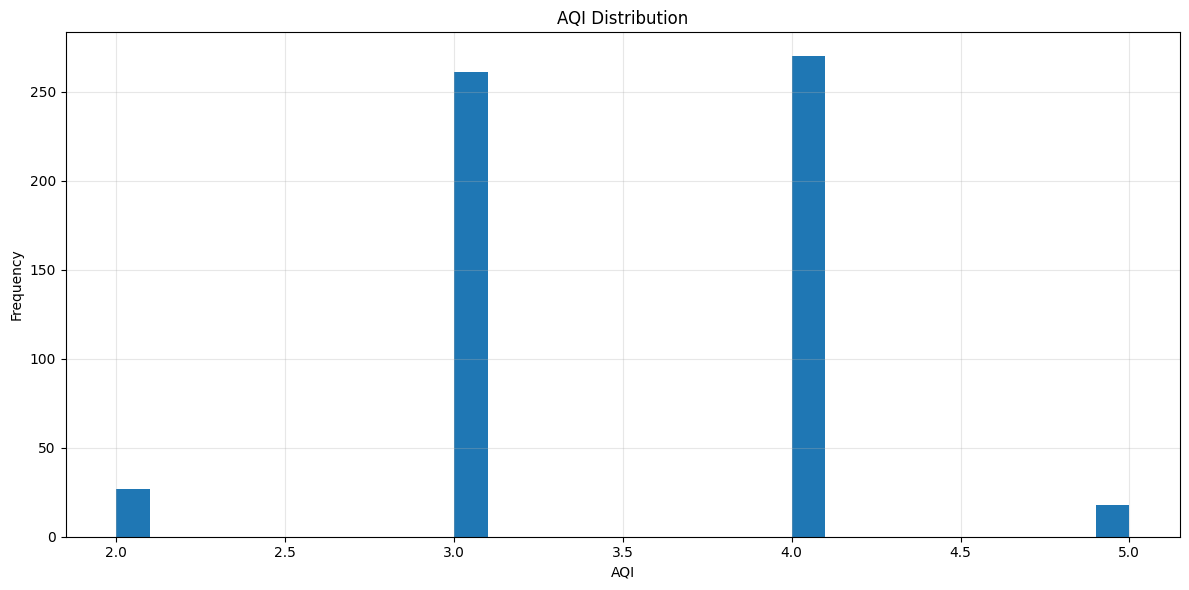

✓ AQI distribution saved

Creating AQI time trend...


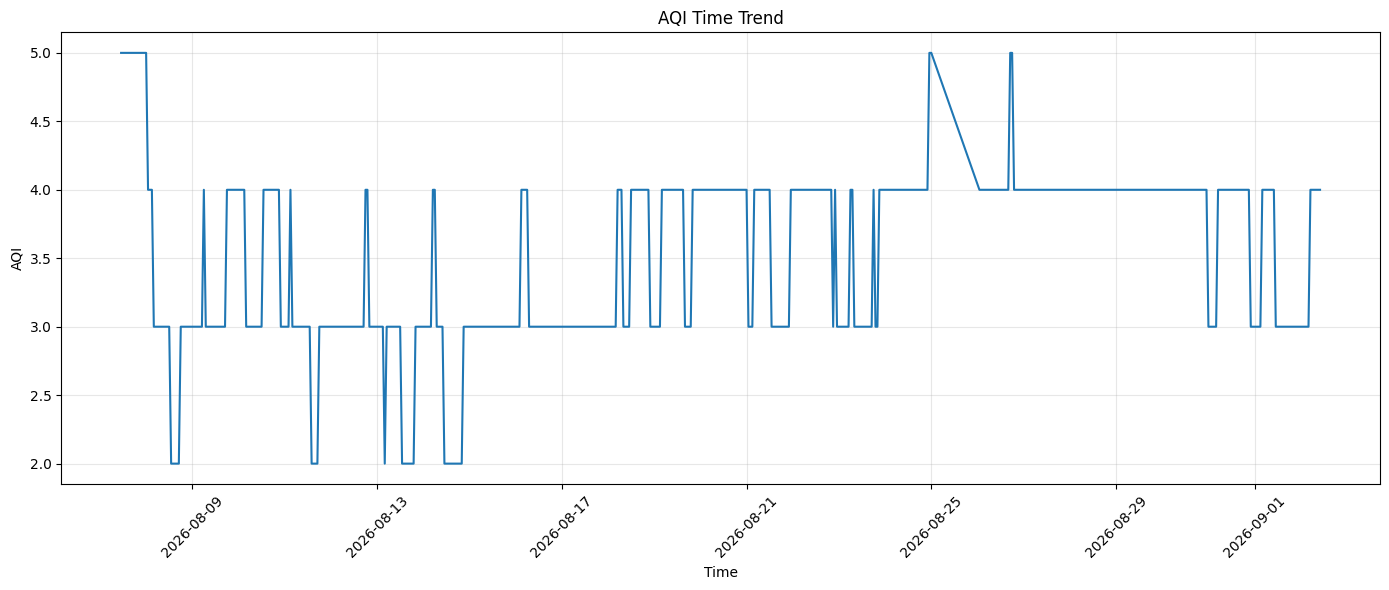

✓ AQI trend saved


HOURLY AQI ANALYSIS


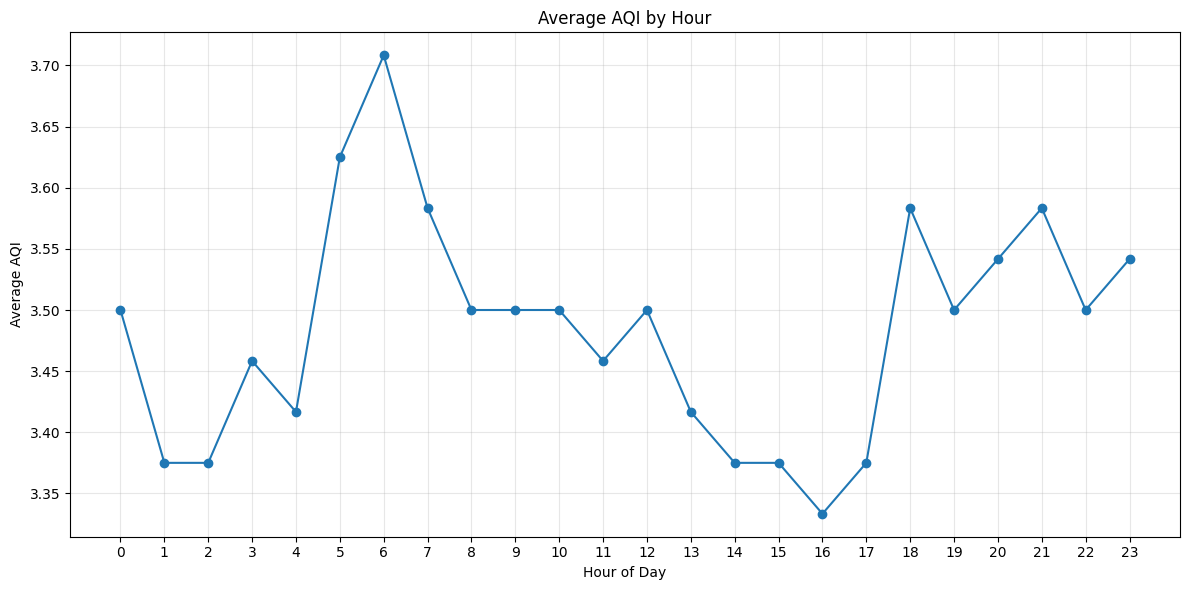

✓ Highest average AQI hour: 6:00
✓ Lowest average AQI hour: 16:00


POLLUTANT CORRELATION ANALYSIS

AQI correlations:
api_aqi    1.000000
PM10       0.725685
PM2_5      0.681353
SO2        0.219223
NH3        0.179386
NO2        0.107616
O3        -0.009992
CO        -0.022427
Name: api_aqi, dtype: float64


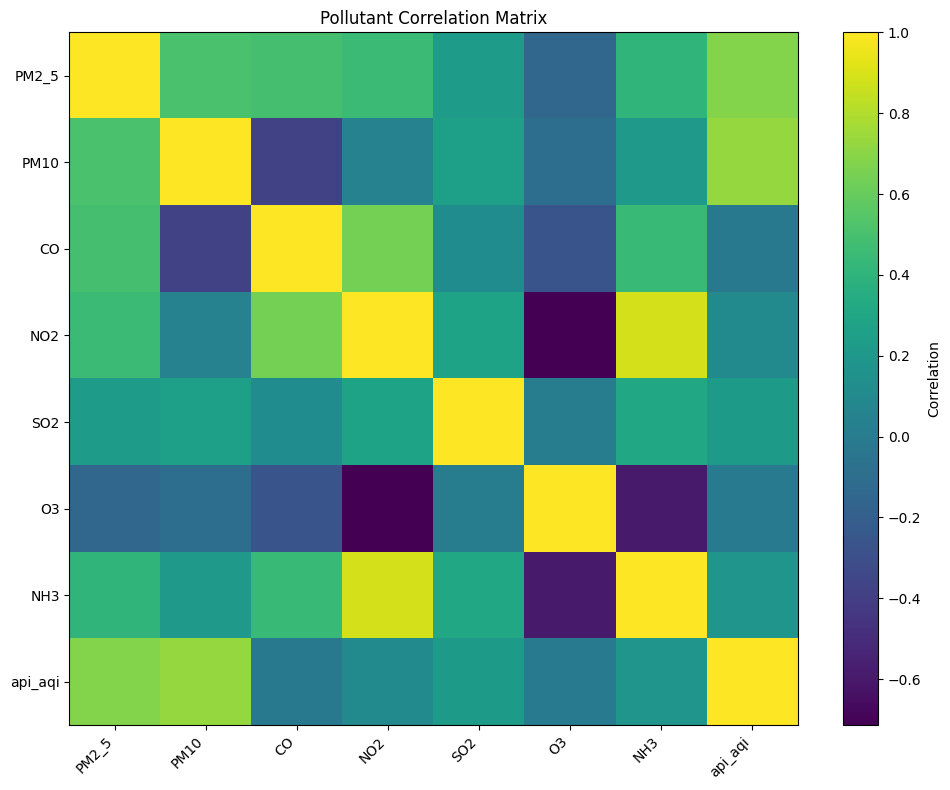

✓ Correlation analysis saved


STEP 4 — LOADING RANDOM FOREST MODELS
✓ 24h Random Forest loaded
✓ 48h Random Forest loaded
✓ 72h Random Forest loaded


STEP 5 — SHAP EXPLAINABILITY
SHAP samples: 300
Features: 22

Running SHAP for 24h...


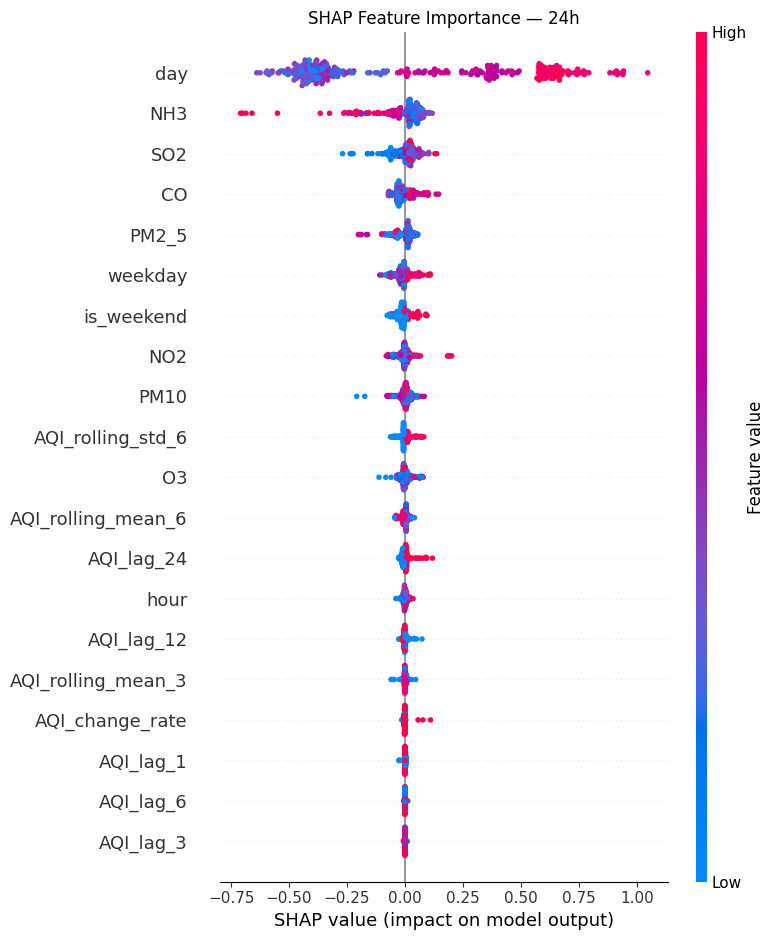

✓ SHAP plot saved: module10_analytics/shap/shap_summary_24h.png
✓ SHAP importance saved: module10_analytics/shap/shap_importance_24h.csv

Top 10 important features:
             feature  mean_abs_shap
0                day       0.430013
1                NH3       0.068130
2                SO2       0.036882
3                 CO       0.028221
4              PM2_5       0.027371
5            weekday       0.023996
6         is_weekend       0.022064
7                NO2       0.017525
8               PM10       0.015732
9  AQI_rolling_std_6       0.014692

Running SHAP for 48h...


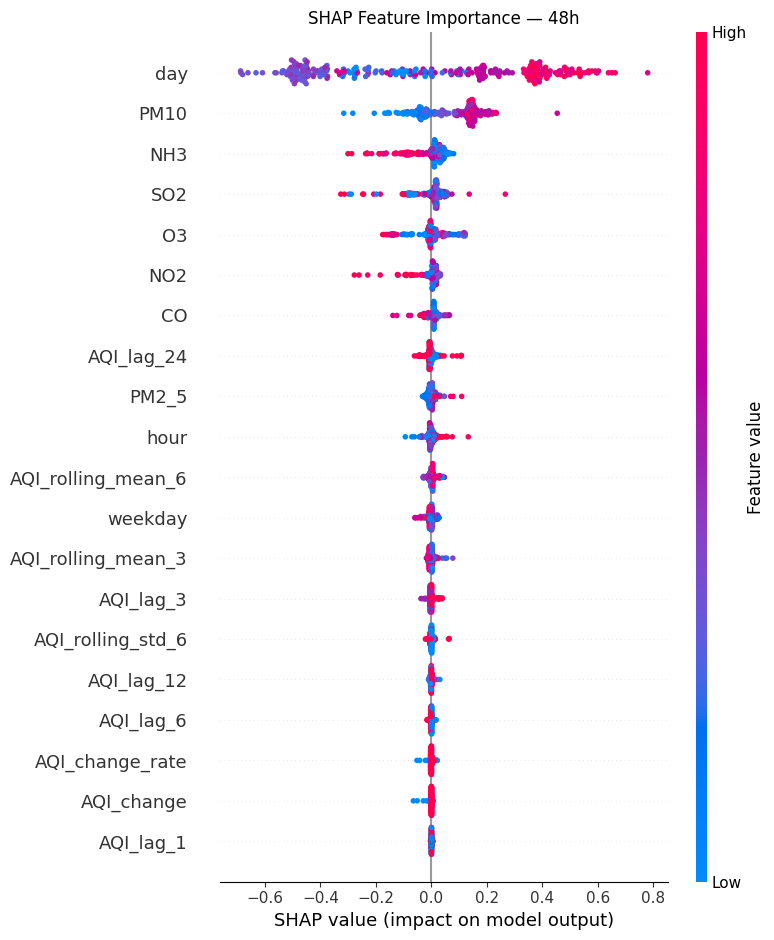

✓ SHAP plot saved: module10_analytics/shap/shap_summary_48h.png
✓ SHAP importance saved: module10_analytics/shap/shap_importance_48h.csv

Top 10 important features:
      feature  mean_abs_shap
0         day       0.339855
1        PM10       0.110779
2         NH3       0.041707
3         SO2       0.036914
4          O3       0.032357
5         NO2       0.019093
6          CO       0.015713
7  AQI_lag_24       0.011007
8       PM2_5       0.009962
9        hour       0.009783

Running SHAP for 72h...


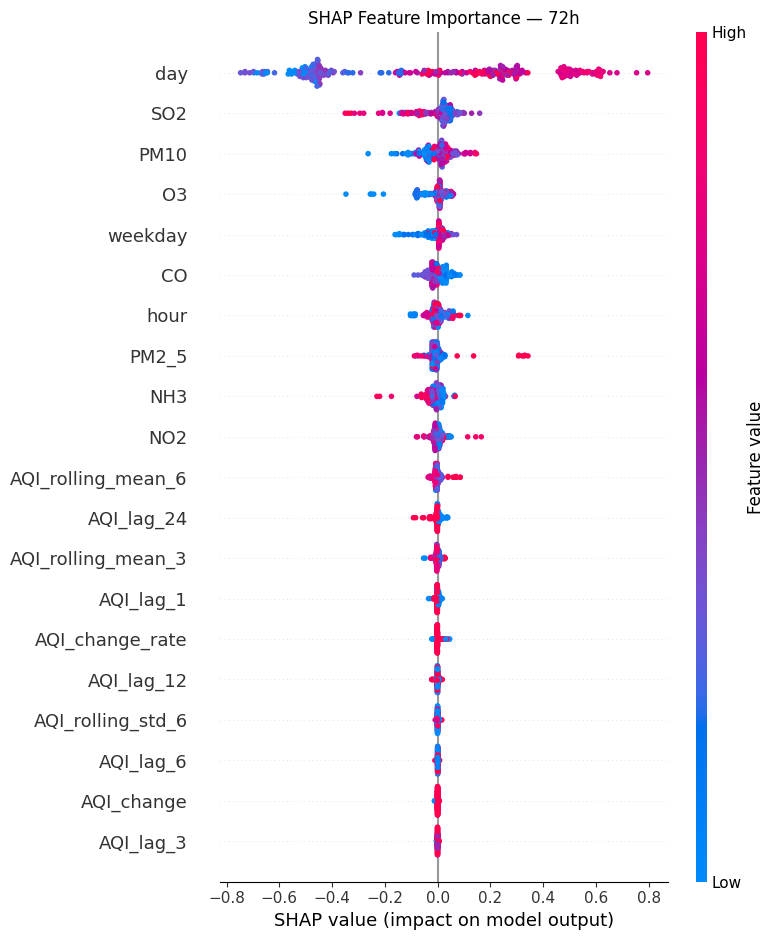

✓ SHAP plot saved: module10_analytics/shap/shap_summary_72h.png
✓ SHAP importance saved: module10_analytics/shap/shap_importance_72h.csv

Top 10 important features:
   feature  mean_abs_shap
0      day       0.373800
1      SO2       0.049301
2     PM10       0.037698
3       O3       0.028562
4  weekday       0.022292
5       CO       0.021070
6     hour       0.020978
7    PM2_5       0.020001
8      NH3       0.019471
9      NO2       0.012826


STEP 6 — COMBINED FEATURE IMPORTANCE

Overall SHAP feature importance:
               feature  mean_abs_shap
0                  day       0.381223
1                 PM10       0.054736
2                  NH3       0.043102
3                  SO2       0.041032
4                   O3       0.024787
5                   CO       0.021668
6                PM2_5       0.019111
7              weekday       0.017991
8                  NO2       0.016481
9                 hour       0.012271
10  AQI_rolling_mean_6       0.009119
11          AQI_lag_

In [253]:
# ============================================================================
# PEARLS AQI PREDICTOR
# MODULE 10 — SHAP EXPLAINABILITY + ADVANCED ANALYTICS + AQI ALERTS
# ============================================================================
#
# Google Colab
#
# This module:
#
# 1. Loads the ML-ready AQI dataset
# 2. Loads Random Forest models
# 3. Performs advanced EDA
# 4. Creates AQI trend analysis
# 5. Creates pollutant correlation analysis
# 6. Performs hourly AQI analysis
# 7. Performs SHAP explainability
# 8. Generates feature importance rankings
# 9. Generates hazardous AQI alerts
# 10. Creates a complete Module 10 report
#
# ============================================================================


# ============================================================================
# 1. INSTALL REQUIRED PACKAGES
# ============================================================================

print("=" * 80)
print("INSTALLING MODULE 10 PACKAGES")
print("=" * 80)

!pip install -q shap plotly


# ============================================================================
# 2. IMPORT LIBRARIES
# ============================================================================

import os
import json
import warnings
import pickle
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

print("✓ Libraries imported")


# ============================================================================
# 3. SHAP IMPORT
# ============================================================================

try:

    import shap

    SHAP_AVAILABLE = True

    print("✓ SHAP available")

except Exception as e:

    SHAP_AVAILABLE = False

    print("⚠ SHAP could not be imported")
    print("Reason:", e)


# ============================================================================
# 4. PROJECT CONFIGURATION
# ============================================================================

PROJECT_NAME = "Pearls AQI Predictor"

DATA_FILE = "aqi_ml_ready.csv"

MODEL_24 = "models/random_forest_24h.pkl"
MODEL_48 = "models/random_forest_48h.pkl"
MODEL_72 = "models/random_forest_72h.pkl"


OUTPUT_DIR = "module10_analytics"

SHAP_DIR = os.path.join(
    OUTPUT_DIR,
    "shap"
)

ANALYTICS_DIR = os.path.join(
    OUTPUT_DIR,
    "analytics"
)

ALERT_DIR = os.path.join(
    OUTPUT_DIR,
    "alerts"
)


# ============================================================================
# 5. CREATE DIRECTORIES
# ============================================================================

os.makedirs(
    SHAP_DIR,
    exist_ok=True
)

os.makedirs(
    ANALYTICS_DIR,
    exist_ok=True
)

os.makedirs(
    ALERT_DIR,
    exist_ok=True
)


# ============================================================================
# 6. HEADER
# ============================================================================

print("\n")
print("=" * 80)
print("PEARLS AQI PREDICTOR")
print("MODULE 10 — SHAP + ADVANCED ANALYTICS + AQI ALERTS")
print("=" * 80)


# ============================================================================
# 7. CHECK DATASET
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 1 — DATASET CHECK")
print("=" * 80)


if not os.path.exists(DATA_FILE):

    raise FileNotFoundError(
        f"{DATA_FILE} was not found."
    )


print(f"✓ Dataset found: {DATA_FILE}")


# ============================================================================
# 8. LOAD DATA
# ============================================================================

df = pd.read_csv(
    DATA_FILE
)


print("\nDataset loaded")

print(
    "Rows:",
    len(df)
)

print(
    "Columns:",
    len(df.columns)
)


# ============================================================================
# 9. CONVERT TIMESTAMP
# ============================================================================

if "timestamp" in df.columns:

    df["timestamp"] = pd.to_datetime(
        df["timestamp"],
        errors="coerce"
    )

    df = df.sort_values(
        "timestamp"
    )

    print("✓ Timestamp converted")


# ============================================================================
# 10. DEFINE FEATURES
# ============================================================================

FEATURES = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3",

    "hour",
    "day",
    "month",
    "weekday",
    "is_weekend",

    "AQI_lag_1",
    "AQI_lag_3",
    "AQI_lag_6",
    "AQI_lag_12",
    "AQI_lag_24",

    "AQI_change",
    "AQI_change_rate",

    "AQI_rolling_mean_3",
    "AQI_rolling_mean_6",
    "AQI_rolling_std_6"

]


TARGETS = [

    "target_AQI_24h",
    "target_AQI_48h",
    "target_AQI_72h"

]


print("\n")
print("=" * 80)
print("STEP 2 — FEATURE VALIDATION")
print("=" * 80)


missing_features = [

    feature
    for feature in FEATURES
    if feature not in df.columns

]


missing_targets = [

    target
    for target in TARGETS
    if target not in df.columns

]


if missing_features:

    print(
        "⚠ Missing features:",
        missing_features
    )

else:

    print(
        f"✓ All {len(FEATURES)} features found"
    )


if missing_targets:

    print(
        "⚠ Missing targets:",
        missing_targets
    )

else:

    print(
        f"✓ All {len(TARGETS)} targets found"
    )


# ============================================================================
# 11. NUMERIC DATA
# ============================================================================

for feature in FEATURES:

    if feature in df.columns:

        df[feature] = pd.to_numeric(
            df[feature],
            errors="coerce"
        )


for target in TARGETS:

    if target in df.columns:

        df[target] = pd.to_numeric(
            df[target],
            errors="coerce"
        )


# ============================================================================
# 12. EDA — BASIC STATISTICS
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 3 — ADVANCED EDA")
print("=" * 80)


eda_summary = {}


eda_summary["rows"] = int(
    len(df)
)

eda_summary["columns"] = int(
    len(df.columns)
)


if "city" in df.columns:

    eda_summary["cities"] = [

        str(x)
        for x in df["city"]
        .dropna()
        .unique()

    ]

else:

    eda_summary["cities"] = []


# ============================================================================
# 13. AQI COLUMN
# ============================================================================

if "api_aqi" in df.columns:

    AQI_COLUMN = "api_aqi"

elif "AQI" in df.columns:

    AQI_COLUMN = "AQI"

else:

    AQI_COLUMN = None


if AQI_COLUMN:

    df[AQI_COLUMN] = pd.to_numeric(
        df[AQI_COLUMN],
        errors="coerce"
    )

    aqi_clean = df[AQI_COLUMN].dropna()

    eda_summary["aqi_mean"] = float(
        aqi_clean.mean()
    )

    eda_summary["aqi_min"] = float(
        aqi_clean.min()
    )

    eda_summary["aqi_max"] = float(
        aqi_clean.max()
    )

    eda_summary["aqi_std"] = float(
        aqi_clean.std()
    )

    print(
        f"✓ AQI column: {AQI_COLUMN}"
    )

    print(
        f"Mean AQI: {aqi_clean.mean():.3f}"
    )

    print(
        f"Minimum AQI: {aqi_clean.min():.3f}"
    )

    print(
        f"Maximum AQI: {aqi_clean.max():.3f}"
    )


# ============================================================================
# 14. AQI DISTRIBUTION
# ============================================================================

print("\nCreating AQI distribution plot...")


if AQI_COLUMN:

    plt.figure(
        figsize=(12, 6)
    )

    plt.hist(
        df[AQI_COLUMN].dropna(),
        bins=30
    )

    plt.xlabel(
        "AQI"
    )

    plt.ylabel(
        "Frequency"
    )

    plt.title(
        "AQI Distribution"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            ANALYTICS_DIR,
            "aqi_distribution.png"
        ),
        dpi=150
    )

    plt.show()

    print(
        "✓ AQI distribution saved"
    )


# ============================================================================
# 15. AQI TIME TREND
# ============================================================================

print("\nCreating AQI time trend...")


if AQI_COLUMN and "timestamp" in df.columns:

    trend_df = df[
        [
            "timestamp",
            AQI_COLUMN
        ]
    ].dropna()


    plt.figure(
        figsize=(14, 6)
    )

    plt.plot(
        trend_df["timestamp"],
        trend_df[AQI_COLUMN]
    )

    plt.xlabel(
        "Time"
    )

    plt.ylabel(
        "AQI"
    )

    plt.title(
        "AQI Time Trend"
    )

    plt.xticks(
        rotation=45
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            ANALYTICS_DIR,
            "aqi_time_trend.png"
        ),
        dpi=150
    )

    plt.show()

    print(
        "✓ AQI trend saved"
    )


# ============================================================================
# 16. HOURLY AQI ANALYSIS
# ============================================================================

print("\n")
print("=" * 80)
print("HOURLY AQI ANALYSIS")
print("=" * 80)


if AQI_COLUMN:

    if "hour" in df.columns:

        hourly_aqi = (

            df
            .groupby("hour")[AQI_COLUMN]
            .mean()
            .reset_index()

        )

    elif "timestamp" in df.columns:

        df["hour"] = (
            df["timestamp"]
            .dt.hour
        )

        hourly_aqi = (

            df
            .groupby("hour")[AQI_COLUMN]
            .mean()
            .reset_index()

        )

    else:

        hourly_aqi = None


    if hourly_aqi is not None:

        plt.figure(
            figsize=(12, 6)
        )

        plt.plot(
            hourly_aqi["hour"],
            hourly_aqi[AQI_COLUMN],
            marker="o"
        )

        plt.xlabel(
            "Hour of Day"
        )

        plt.ylabel(
            "Average AQI"
        )

        plt.title(
            "Average AQI by Hour"
        )

        plt.xticks(
            range(0, 24)
        )

        plt.grid(
            alpha=0.3
        )

        plt.tight_layout()

        plt.savefig(
            os.path.join(
                ANALYTICS_DIR,
                "hourly_aqi_pattern.png"
            ),
            dpi=150
        )

        plt.show()

        highest_hour = int(
            hourly_aqi.loc[
                hourly_aqi[AQI_COLUMN].idxmax(),
                "hour"
            ]
        )

        lowest_hour = int(
            hourly_aqi.loc[
                hourly_aqi[AQI_COLUMN].idxmin(),
                "hour"
            ]
        )

        eda_summary[
            "highest_average_aqi_hour"
        ] = highest_hour

        eda_summary[
            "lowest_average_aqi_hour"
        ] = lowest_hour

        print(
            f"✓ Highest average AQI hour: {highest_hour}:00"
        )

        print(
            f"✓ Lowest average AQI hour: {lowest_hour}:00"
        )


# ============================================================================
# 17. POLLUTANT CORRELATION
# ============================================================================

print("\n")
print("=" * 80)
print("POLLUTANT CORRELATION ANALYSIS")
print("=" * 80)


POLLUTANTS = [

    "PM2_5",
    "PM10",
    "CO",
    "NO2",
    "SO2",
    "O3",
    "NH3"

]


available_pollutants = [

    x
    for x in POLLUTANTS
    if x in df.columns

]


if AQI_COLUMN and available_pollutants:

    correlation_columns = (
        available_pollutants
        + [AQI_COLUMN]
    )


    correlation = df[
        correlation_columns
    ].corr()


    print(
        "\nAQI correlations:"
    )

    print(
        correlation[AQI_COLUMN]
        .sort_values(
            ascending=False
        )
    )


    plt.figure(
        figsize=(10, 8)
    )

    plt.imshow(
        correlation,
        aspect="auto"
    )

    plt.colorbar(
        label="Correlation"
    )

    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=45,
        ha="right"
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    plt.title(
        "Pollutant Correlation Matrix"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            ANALYTICS_DIR,
            "pollutant_correlation.png"
        ),
        dpi=150
    )

    plt.show()

    print(
        "✓ Correlation analysis saved"
    )


# ============================================================================
# 18. SAVE CORRELATION
# ============================================================================

if AQI_COLUMN and available_pollutants:

    correlation.to_csv(
        os.path.join(
            ANALYTICS_DIR,
            "pollutant_correlation.csv"
        )
    )


# ============================================================================
# 19. LOAD MODELS
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 4 — LOADING RANDOM FOREST MODELS")
print("=" * 80)


def load_model(path):

    if not os.path.exists(path):

        return None

    try:

        return joblib.load(
            path
        )

    except Exception:

        try:

            with open(
                path,
                "rb"
            ) as f:

                return pickle.load(
                    f
                )

        except Exception as e:

            print(
                f"Could not load {path}: {e}"
            )

            return None


model_24 = load_model(
    MODEL_24
)

model_48 = load_model(
    MODEL_48
)

model_72 = load_model(
    MODEL_72
)


if model_24 is not None:

    print(
        "✓ 24h Random Forest loaded"
    )

else:

    print(
        "⚠ 24h model unavailable"
    )


if model_48 is not None:

    print(
        "✓ 48h Random Forest loaded"
    )

else:

    print(
        "⚠ 48h model unavailable"
    )


if model_72 is not None:

    print(
        "✓ 72h Random Forest loaded"
    )

else:

    print(
        "⚠ 72h model unavailable"
    )


# ============================================================================
# 20. PREPARE SHAP DATA
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 5 — SHAP EXPLAINABILITY")
print("=" * 80)


available_features = [

    x
    for x in FEATURES
    if x in df.columns

]


if len(available_features) == 0:

    print(
        "⚠ No features available for SHAP"
    )

else:

    shap_df = df[
        available_features
    ].copy()


    shap_df = shap_df.replace(
        [np.inf, -np.inf],
        np.nan
    )


    shap_df = shap_df.dropna()


    # Limit SHAP dataset to keep Colab responsive

    if len(shap_df) > 300:

        shap_sample = shap_df.sample(
            n=300,
            random_state=42
        )

    else:

        shap_sample = shap_df.copy()


    print(
        "SHAP samples:",
        len(shap_sample)
    )

    print(
        "Features:",
        len(available_features)
    )


# ============================================================================
# 21. SHAP FUNCTION
# ============================================================================

def run_shap_analysis(
    model,
    model_name,
    sample_data
):

    if model is None:

        print(
            f"⚠ Skipping {model_name}: model unavailable"
        )

        return None


    if not SHAP_AVAILABLE:

        print(
            f"⚠ Skipping {model_name}: SHAP unavailable"
        )

        return None


    print(
        f"\nRunning SHAP for {model_name}..."
    )


    try:

        explainer = shap.TreeExplainer(
            model
        )


        shap_values = explainer.shap_values(
            sample_data
        )


        # Some SHAP/model combinations return lists

        if isinstance(
            shap_values,
            list
        ):

            shap_values_plot = shap_values[0]

        else:

            shap_values_plot = shap_values


        # SHAP summary plot

        plt.figure(
            figsize=(12, 8)
        )

        shap.summary_plot(

            shap_values_plot,

            sample_data,

            show=False

        )

        plt.title(
            f"SHAP Feature Importance — {model_name}"
        )

        plt.tight_layout()

        safe_name = (
            model_name
            .lower()
            .replace(" ", "_")
            .replace("-", "")
        )


        plot_path = os.path.join(

            SHAP_DIR,

            f"shap_summary_{safe_name}.png"

        )


        plt.savefig(
            plot_path,
            dpi=150,
            bbox_inches="tight"
        )

        plt.show()


        # Mean absolute SHAP importance

        mean_abs_shap = np.abs(
            shap_values_plot
        ).mean(
            axis=0
        )


        importance_df = pd.DataFrame({

            "feature": sample_data.columns,

            "mean_abs_shap": mean_abs_shap

        })


        importance_df = (
            importance_df
            .sort_values(
                "mean_abs_shap",
                ascending=False
            )
            .reset_index(
                drop=True
            )
        )


        csv_path = os.path.join(

            SHAP_DIR,

            f"shap_importance_{safe_name}.csv"

        )


        importance_df.to_csv(
            csv_path,
            index=False
        )


        print(
            f"✓ SHAP plot saved: {plot_path}"
        )

        print(
            f"✓ SHAP importance saved: {csv_path}"
        )


        print(
            "\nTop 10 important features:"
        )

        print(
            importance_df.head(10)
        )


        return importance_df


    except Exception as e:

        print(
            f"⚠ SHAP failed for {model_name}"
        )

        print(
            "Reason:",
            e
        )

        return None


# ============================================================================
# 22. RUN SHAP
# ============================================================================

shap_results = {}


if available_features:

    shap_results["24h"] = run_shap_analysis(

        model_24,

        "24h",

        shap_sample

    )


    shap_results["48h"] = run_shap_analysis(

        model_48,

        "48h",

        shap_sample

    )


    shap_results["72h"] = run_shap_analysis(

        model_72,

        "72h",

        shap_sample

    )


# ============================================================================
# 23. COMBINED FEATURE IMPORTANCE
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 6 — COMBINED FEATURE IMPORTANCE")
print("=" * 80)


combined_importance = None


importance_tables = []


for horizon, result in shap_results.items():

    if result is not None:

        temp = result.copy()

        temp["horizon"] = horizon

        importance_tables.append(
            temp
        )


if importance_tables:

    all_importance = pd.concat(
        importance_tables,
        ignore_index=True
    )


    combined_importance = (

        all_importance
        .groupby("feature")[
            "mean_abs_shap"
        ]
        .mean()
        .sort_values(
            ascending=False
        )
        .reset_index()

    )


    combined_importance.to_csv(

        os.path.join(
            SHAP_DIR,
            "shap_importance.csv"
        ),

        index=False

    )


    print(
        "\nOverall SHAP feature importance:"
    )

    print(
        combined_importance.head(15)
    )

    print(
        "\n✓ Combined SHAP importance saved"
    )


# ============================================================================
# 24. AQI ALERT SYSTEM
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 7 — AQI ALERT SYSTEM")
print("=" * 80)


def aqi_category(aqi):

    if aqi <= 50:

        return "Good"

    elif aqi <= 100:

        return "Moderate"

    elif aqi <= 150:

        return "Unhealthy for Sensitive Groups"

    elif aqi <= 200:

        return "Unhealthy"

    elif aqi <= 300:

        return "Very Unhealthy"

    else:

        return "Hazardous"


def alert_level(aqi):

    if aqi <= 50:

        return "NORMAL"

    elif aqi <= 100:

        return "MODERATE"

    elif aqi <= 150:

        return "WARNING"

    elif aqi <= 200:

        return "HIGH"

    elif aqi <= 300:

        return "VERY HIGH"

    else:

        return "HAZARDOUS"


def alert_message(aqi):

    if aqi <= 50:

        return (
            "Air quality is good."
        )

    elif aqi <= 100:

        return (
            "Air quality is acceptable, "
            "but sensitive people should monitor conditions."
        )

    elif aqi <= 150:

        return (
            "Sensitive groups may experience "
            "health effects."
        )

    elif aqi <= 200:

        return (
            "Everyone may begin to experience "
            "health effects."
        )

    elif aqi <= 300:

        return (
            "Health alert: everyone may experience "
            "more serious health effects."
        )

    else:

        return (
            "Health emergency: hazardous air quality."
        )


# ============================================================================
# 25. CURRENT AQI ALERT
# ============================================================================

alerts = []


if AQI_COLUMN:

    latest_row = df.iloc[-1]

    latest_aqi = float(
        latest_row[AQI_COLUMN]
    )


    current_alert = {

        "timestamp": str(
            latest_row.get(
                "timestamp",
                ""
            )
        ),

        "city": str(
            latest_row.get(
                "city",
                "Unknown"
            )
        ),

        "aqi": latest_aqi,

        "category": aqi_category(
            latest_aqi
        ),

        "alert_level": alert_level(
            latest_aqi
        ),

        "message": alert_message(
            latest_aqi
        )

    }


    alerts.append(
        current_alert
    )


    print(
        "\nCURRENT AQI"
    )

    print(
        "AQI:",
        round(latest_aqi, 2)
    )

    print(
        "Category:",
        current_alert["category"]
    )

    print(
        "Alert:",
        current_alert["alert_level"]
    )

    print(
        "Message:",
        current_alert["message"]
    )


# ============================================================================
# 26. HISTORICAL HAZARDOUS ALERTS
# ============================================================================

if AQI_COLUMN:

    alert_df = df[
        [
            col
            for col in [
                "timestamp",
                "city",
                AQI_COLUMN
            ]
            if col in df.columns
        ]
    ].copy()


    alert_df = alert_df.rename(
        columns={
            AQI_COLUMN: "AQI"
        }
    )


    alert_df["category"] = (
        alert_df["AQI"]
        .apply(aqi_category)
    )


    alert_df["alert_level"] = (
        alert_df["AQI"]
        .apply(alert_level)
    )


    alert_df["message"] = (
        alert_df["AQI"]
        .apply(alert_message)
    )


    # Keep important alert levels

    important_alerts = alert_df[
        alert_df["AQI"] > 100
    ].copy()


    important_alerts.to_csv(

        os.path.join(
            ALERT_DIR,
            "aqi_alerts.csv"
        ),

        index=False

    )


    print(
        "\n✓ AQI alert records saved"
    )

    print(
        "Total alert records:",
        len(important_alerts)
    )


    # Alert statistics

    alert_counts = (

        alert_df[
            "alert_level"
        ]
        .value_counts()
        .to_dict()

    )


else:

    alert_counts = {}


# ============================================================================
# 27. FORECAST ALERT ANALYSIS
# ============================================================================

print("\n")
print("=" * 80)
print("FORECAST ALERT ANALYSIS")
print("=" * 80)


forecast_alerts = {}


target_model_pairs = [

    (
        "24h",
        model_24,
        "target_AQI_24h"
    ),

    (
        "48h",
        model_48,
        "target_AQI_48h"
    ),

    (
        "72h",
        model_72,
        "target_AQI_72h"
    )

]


# Latest available feature row

if len(available_features) > 0:

    latest_features = df[
        available_features
    ].iloc[
        -1
    ].copy()


    latest_features = (
        latest_features
        .replace(
            [np.inf, -np.inf],
            np.nan
        )
        .fillna(0)
    )


    latest_X = pd.DataFrame(
        [
            latest_features.values
        ],
        columns=available_features
    )


    for horizon, model, target in target_model_pairs:

        if model is None:

            continue


        try:

            prediction = float(
                model.predict(
                    latest_X
                )[0]
            )


            forecast_alerts[horizon] = {

                "predicted_aqi": prediction,

                "category": aqi_category(
                    prediction
                ),

                "alert_level": alert_level(
                    prediction
                ),

                "message": alert_message(
                    prediction
                )

            }


            print(
                f"{horizon}: "
                f"AQI {prediction:.2f} | "
                f"{aqi_category(prediction)} | "
                f"{alert_level(prediction)}"
            )


        except Exception as e:

            print(
                f"⚠ Could not predict {horizon}: {e}"
            )


# ============================================================================
# 28. FORECAST ALERT SUMMARY
# ============================================================================

if forecast_alerts:

    maximum_forecast = max(

        x["predicted_aqi"]
        for x in forecast_alerts.values()

    )


    if maximum_forecast > 300:

        overall_forecast_alert = "HAZARDOUS"

    elif maximum_forecast > 200:

        overall_forecast_alert = "VERY HIGH"

    elif maximum_forecast > 150:

        overall_forecast_alert = "HIGH"

    elif maximum_forecast > 100:

        overall_forecast_alert = "WARNING"

    elif maximum_forecast > 50:

        overall_forecast_alert = "MODERATE"

    else:

        overall_forecast_alert = "NORMAL"


    print(
        "\nOverall 3-day forecast alert:",
        overall_forecast_alert
    )

    print(
        "Maximum forecast AQI:",
        round(maximum_forecast, 2)
    )


else:

    overall_forecast_alert = "UNKNOWN"

    maximum_forecast = None


# ============================================================================
# 29. ANALYTICS SUMMARY
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 8 — SAVING ANALYTICS SUMMARY")
print("=" * 80)


eda_summary[
    "available_pollutants"
] = available_pollutants


eda_summary[
    "alert_counts"
] = {

    str(k): int(v)

    for k, v in alert_counts.items()

}


eda_summary[
    "forecast_alert"
] = overall_forecast_alert


if maximum_forecast is not None:

    eda_summary[
        "maximum_forecast_aqi"
    ] = float(
        maximum_forecast
    )


analytics_json = os.path.join(

    ANALYTICS_DIR,

    "analytics_summary.json"

)


with open(
    analytics_json,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        eda_summary,
        f,
        indent=4
    )


print(
    f"✓ Analytics summary saved: {analytics_json}"
)


# ============================================================================
# 30. SAVE ALERT SUMMARY
# ============================================================================

alert_summary = {

    "project": PROJECT_NAME,

    "current_aqi": (
        current_alert
        if AQI_COLUMN
        else None
    ),

    "forecast_alerts": forecast_alerts,

    "overall_forecast_alert":
        overall_forecast_alert,

    "maximum_forecast_aqi":
        maximum_forecast,

    "alert_thresholds": {

        "good": "0-50",

        "moderate": "51-100",

        "unhealthy_sensitive": "101-150",

        "unhealthy": "151-200",

        "very_unhealthy": "201-300",

        "hazardous": ">300"

    }

}


alert_summary_file = os.path.join(

    ALERT_DIR,

    "alert_summary.json"

)


with open(

    alert_summary_file,

    "w",

    encoding="utf-8"

) as f:

    json.dump(
        alert_summary,
        f,
        indent=4
    )


print(
    f"✓ Alert summary saved: {alert_summary_file}"
)


# ============================================================================
# 31. GENERATE MODULE 10 REPORT
# ============================================================================

print("\n")
print("=" * 80)
print("STEP 9 — MODULE 10 REPORT")
print("=" * 80)


report_lines = []


report_lines.append(
    "PEARLS AQI PREDICTOR"
)

report_lines.append(
    "MODULE 10 — SHAP + ADVANCED ANALYTICS + AQI ALERTS"
)

report_lines.append(
    "=" * 70
)


report_lines.append(
    ""
)

report_lines.append(
    "DATASET"
)

report_lines.append(
    f"Rows: {len(df)}"
)

report_lines.append(
    f"Columns: {len(df.columns)}"
)


if AQI_COLUMN:

    report_lines.append(
        f"AQI Column: {AQI_COLUMN}"
    )

    report_lines.append(
        f"Mean AQI: {aqi_clean.mean():.3f}"
    )

    report_lines.append(
        f"Minimum AQI: {aqi_clean.min():.3f}"
    )

    report_lines.append(
        f"Maximum AQI: {aqi_clean.max():.3f}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "ADVANCED ANALYTICS"
)

report_lines.append(
    "✓ AQI distribution analysis"
)

report_lines.append(
    "✓ AQI time trend analysis"
)

report_lines.append(
    "✓ Hourly AQI analysis"
)

report_lines.append(
    "✓ Pollutant correlation analysis"
)


report_lines.append(
    ""
)

report_lines.append(
    "SHAP EXPLAINABILITY"
)


if SHAP_AVAILABLE:

    report_lines.append(
        "✓ SHAP library available"
    )

else:

    report_lines.append(
        "⚠ SHAP library unavailable"
    )


for horizon in [
    "24h",
    "48h",
    "72h"
]:

    if shap_results.get(horizon) is not None:

        report_lines.append(
            f"✓ SHAP analysis completed for {horizon}"
        )

    else:

        report_lines.append(
            f"⚠ SHAP analysis unavailable for {horizon}"
        )


if combined_importance is not None:

    report_lines.append(
        ""
    )

    report_lines.append(
        "TOP SHAP FEATURES"
    )


    for _, row in combined_importance.head(
        10
    ).iterrows():

        report_lines.append(

            f"{row['feature']}: "
            f"{row['mean_abs_shap']:.6f}"

        )


report_lines.append(
    ""
)

report_lines.append(
    "AQI ALERT SYSTEM"
)


if AQI_COLUMN:

    report_lines.append(
        f"Current AQI: {latest_aqi:.3f}"
    )

    report_lines.append(
        f"Current Category: "
        f"{current_alert['category']}"
    )

    report_lines.append(
        f"Current Alert: "
        f"{current_alert['alert_level']}"
    )


report_lines.append(
    ""
)

report_lines.append(
    "FORECAST ALERTS"
)


for horizon, information in forecast_alerts.items():

    report_lines.append(

        f"{horizon}: "
        f"AQI={information['predicted_aqi']:.3f}, "
        f"Category={information['category']}, "
        f"Alert={information['alert_level']}"

    )


report_lines.append(
    ""
)

report_lines.append(
    f"Overall 3-day forecast alert: "
    f"{overall_forecast_alert}"
)


if maximum_forecast is not None:

    report_lines.append(

        f"Maximum forecast AQI: "
        f"{maximum_forecast:.3f}"

    )


report_lines.append(
    ""
)

report_lines.append(
    "MODULE 10 STATUS"
)

report_lines.append(
    "✓ Advanced EDA completed"
)

report_lines.append(
    "✓ AQI trend analysis completed"
)

report_lines.append(
    "✓ Pollutant analysis completed"
)

report_lines.append(
    "✓ SHAP explainability completed/attempted"
)

report_lines.append(
    "✓ AQI alert system completed"
)

report_lines.append(
    "✓ Forecast alert analysis completed"
)

report_lines.append(
    "✓ Analytics files generated"
)

report_lines.append(
    "✓ Module 10 report generated"
)


report_file = os.path.join(

    OUTPUT_DIR,

    "module10_report.txt"

)


with open(

    report_file,

    "w",

    encoding="utf-8"

) as f:

    f.write(
        "\n".join(
            report_lines
        )
    )


print(
    f"✓ Report saved: {report_file}"
)


# ============================================================================
# 32. FINAL SUMMARY
# ============================================================================

print("\n")
print("=" * 80)
print("MODULE 10 — FINAL SUMMARY")
print("=" * 80)


print(
    "\nProject:",
    PROJECT_NAME
)


print(
    "Dataset rows:",
    len(df)
)


print(
    "Dataset columns:",
    len(df.columns)
)


print(
    "\nAdvanced Analytics:"
)

print(
    "✓ AQI distribution"
)

print(
    "✓ AQI time trend"
)

print(
    "✓ Hourly AQI pattern"
)

print(
    "✓ Pollutant correlation"
)


print(
    "\nSHAP:"
)

if SHAP_AVAILABLE:

    print(
        "✓ SHAP available"
    )

else:

    print(
        "⚠ SHAP unavailable"
    )


print(
    "\nAQI Alerts:"
)

if AQI_COLUMN:

    print(
        f"✓ Current AQI: {latest_aqi:.2f}"
    )

    print(
        f"✓ Current category: "
        f"{current_alert['category']}"
    )

    print(
        f"✓ Current alert: "
        f"{current_alert['alert_level']}"
    )


print(
    f"✓ Overall forecast alert: "
    f"{overall_forecast_alert}"
)


print("\n")
print("=" * 80)
print("MODULE 10 OUTPUT FILES")
print("=" * 80)


for root, dirs, files in os.walk(
    OUTPUT_DIR
):

    for filename in files:

        filepath = os.path.join(
            root,
            filename
        )

        print(
            "✓",
            filepath
        )


print("\n")
print("=" * 80)
print("MODULE 10 COMPLETED!")
print("=" * 80)

print(
    """

Your project now includes:

✓ Machine Learning prediction
✓ 24-hour AQI forecast
✓ 48-hour AQI forecast
✓ 72-hour AQI forecast
✓ Flask prediction API
✓ Streamlit dashboard
✓ Advanced EDA
✓ AQI trend analysis
✓ Pollutant correlation analysis
✓ SHAP explainability
✓ Feature importance analysis
✓ Hazardous AQI alert system
✓ Forecast alert system
✓ Analytics reports

IMPORTANT:
The negative R² values from Module 7 are still present.
Module 10 explains the models and analyzes the data,
but it does not artificially hide or change those results.

The next step should be improving the forecasting models
and then integrating the SHAP/alert results into the
Streamlit dashboard.
"""
)

In [262]:
!unzip -o Pearls_AQI_HTML_Dashboard.zip

Archive:  Pearls_AQI_HTML_Dashboard.zip
  inflating: pearls_html_dashboard/app.py  
  inflating: pearls_html_dashboard/templates/index.html  
  inflating: pearls_html_dashboard/static/style.css  
  inflating: pearls_html_dashboard/static/app.js  
  inflating: pearls_html_dashboard/README.txt  


In [263]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles:")
print(os.listdir())

Current directory:
/content

Files:
['.config', '.ipynb_checkpoints', 'aqi_raw_data.csv', 'pearls_html_dashboard', 'models', 'Pearls_AQI_HTML_Dashboard.zip', 'data', 'module10_analytics', 'module8_api', 'best_models_by_horizon.csv', 'historical_pollution.csv', 'aqi_ml_ready.csv', 'module9_dashboard', 'model_results_all_horizons.csv', 'aqi_training_dataset.csv', 'module6_backup', 'shap_results', 'module7_pipeline', 'drive', 'sample_data']


In [264]:
import os

print("Dataset:", os.path.exists("aqi_ml_ready.csv"))

print("24h model:", os.path.exists("models/random_forest_24h.pkl"))
print("48h model:", os.path.exists("models/random_forest_48h.pkl"))
print("72h model:", os.path.exists("models/random_forest_72h.pkl"))

Dataset: True
24h model: True
48h model: True
72h model: True


In [265]:
!python pearls_html_dashboard/app.py

 * Serving Flask app 'app'
 * Debug mode: off
Address already in use
Port 5000 is in use by another program. Either identify and stop that program, or start the server with a different port.


In [260]:
from google.colab.output import eval_js

url = eval_js("google.colab.kernel.proxyPort(5001)")
print("YOUR DASHBOARD URL:")
print(url)

YOUR DASHBOARD URL:
https://5001-m-s-kkb-usw3b1-3qiyzykzy6e9x-b.us-west3-1.prod.colab.dev
